# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 01 - Fase 1: Análisis Exploratorio de los Datos Crudos

Esta fase inspecciona los datasets originales antes de tomar decisiones de preprocesado, selección de características o modelado. El recorrido se plantea como una exploración progresiva: primero se comprueba la lectura de cada archivo, después se caracteriza cada dataset por separado y, solo al final de cada sección, se construye una comparación conjunta cuando aporta lectura.

El encaje con la propuesta del TFG es directo: esta fase documenta la selección de datasets de referencia del objetivo 2, prepara la comparación clásica de los objetivos 1 y 3 y deja una base reproducible para que el método cuántico de selección de características pueda evaluarse contra un brazo clásico bien caracterizado. La lectura se orienta además al paso posterior hacia QFS: las asociaciones variable-target anticipan la relevancia que después se codificará como información mutua, y las redundancias entre variables anticipan las interacciones que QFS trasladará a distancias entre átomos.


## Importación de Librerías

Se importan las librerías que se utilizarán durante el análisis exploratorio y la generación de evidencias reproducibles.


In [1]:
from pathlib import Path
import io
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display as ipy_display
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)


## Preparación del Entorno de Trabajo

Se localizan los datos crudos y se preparan las carpetas donde se conservarán las tablas y figuras de esta fase. Si alguna carpeta esencial no existiera, la ejecución se detendría sin producir una lectura parcial.


In [2]:
# Rutas principales del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "01_raw"
TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "01_raw_eda"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "01_raw_eda"
REPORTS_DIR = PROJECT_ROOT / "results" / "reports" / "01_raw_eda"

for output_dir in [TABLES_DIR, FIGURES_DIR, REPORTS_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

for old_table_path in TABLES_DIR.glob("*.csv"):
    old_table_path.unlink()

for old_figure_path in FIGURES_DIR.rglob("*.png"):
    old_figure_path.unlink()

for old_figure_path in FIGURES_DIR.rglob("*.pdf"):
    old_figure_path.unlink()

for old_child in FIGURES_DIR.iterdir():
    if old_child.is_dir() and not any(old_child.iterdir()):
        old_child.rmdir()

for old_report_path in REPORTS_DIR.glob("*"):
    if old_report_path.is_file():
        old_report_path.unlink()

assert DATA_DIR.exists()
assert TABLES_DIR.exists()
assert FIGURES_DIR.exists()
assert REPORTS_DIR.exists()


El entorno queda preparado para leer los datos crudos y conservar las tablas y figuras que sustentan la fase. La comprobación es silenciosa si las carpetas existen; así el capítulo empieza por el objeto de estudio y no por detalles de ejecución.


## Configuración Visual y Parámetros Generales

La configuración visual se mantiene sobria para facilitar la lectura en notebook y en memoria. El límite de muestra visual se usa únicamente para representar datasets grandes; los cálculos estadísticos se realizan sobre los datos completos salvo que se indique lo contrario.


In [3]:
# Parámetros generales del análisis.
RANDOM_STATE = 42
MAX_FILAS_MUESTRA_VISUAL = 5000

PALETA_DATASETS = {
    "breast_cancer_wisconsin": "#2F6F9F",
    "customer_churn": "#D9822B",
    "madelon": "#5E8C61",
    "olive_oil": "#7A6FA5",
}

ORDEN_DATASETS = list(PALETA_DATASETS)

plt.rcParams.update({
    "figure.facecolor": "#FAF7F2",
    "axes.facecolor": "#FAF7F2",
    "axes.edgecolor": "#D8D0C4",
    "axes.labelcolor": "#2D2A26",
    "text.color": "#2D2A26",
    "xtick.color": "#2D2A26",
    "ytick.color": "#2D2A26",
    "grid.color": "#E6DED2",
    "font.size": 10,
})

pd.set_option("display.max_columns", 28)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 160)


## Utilidades Generales del Notebook

Estas funciones son pequeñas y tienen una responsabilidad concreta: guardar tablas, guardar figuras y aplicar un estilo visual común. Se definen aquí porque se reutilizan en varias secciones.


In [4]:
def guardar_tabla(tabla, nombre_archivo):
    ruta_tabla = TABLES_DIR / nombre_archivo
    tabla.to_csv(ruta_tabla, index=False)
    return ruta_tabla


def guardar_figura(figura, nombre_archivo):
    ruta_figura = FIGURES_DIR / nombre_archivo
    ruta_figura.parent.mkdir(parents=True, exist_ok=True)
    figura.savefig(ruta_figura, dpi=300, bbox_inches="tight")
    ruta_pdf = ruta_figura.with_suffix(".pdf")
    figura.savefig(ruta_pdf, bbox_inches="tight")
    return ruta_figura


def aplicar_estilo_eje(eje, eje_rejilla="x"):
    eje.spines["top"].set_visible(False)
    eje.spines["right"].set_visible(False)
    eje.grid(axis=eje_rejilla, alpha=0.65)
    eje.set_axisbelow(True)


def mostrar_ruta_relativa(ruta):
    print("Figura guardada en formatos PNG y PDF.")


COLUMNAS_PRESENTACION_ESPECIFICAS = {
    "features": "variables predictoras",
    "target_presente": "target presente",
    "ratio_features_muestras": "variables / filas",
    "filas_por_feature": "filas por variable",
    "ratio_valores_unicos": "valores únicos / filas",
    "variables_moda_dominante_98": "variables con moda dominante al 98%",
    "n": "observaciones",
    "ratio_mayoritaria_minoritaria": "ratio mayoritaria / minoritaria",
    "p_valor": "p-valor",
    "p_valor_fdr": "p-valor FDR",
    "abs_tamano_efecto": "|tamaño de efecto|",
    "efecto_abs_mediano": "|efecto| mediano",
    "efecto_abs_maximo": "|efecto| máximo",
    "variable_a": "variable A",
    "variable_b": "variable B",
    "spearman": "Spearman",
    "abs_spearman": "|Spearman|",
    "correlacion_abs_maxima": "|correlación| máxima",
    "componentes_80": "componentes para 80%",
    "componentes_90": "componentes para 90%",
    "categoria_exploratoria": "categoría exploratoria",
}


def nombre_columna_presentacion(columna):
    if columna is None:
        return None
    if columna in COLUMNAS_PRESENTACION_ESPECIFICAS:
        return COLUMNAS_PRESENTACION_ESPECIFICAS[columna]
    return str(columna).replace("_", " ")

VALORES_PRESENTACION = {
    "breast_cancer_wisconsin": "Breast Cancer Wisconsin",
    "customer_churn": "Customer Churn",
    "madelon": "Madelon",
    "olive_oil": "Olive Oil",
    "muestra_estratificada_visual": "muestra estratificada visual",
    "completo": "completo",
    "revisar_riesgo": "revisar por cautela",
    "revisar_por_cautela": "revisar por cautela",
    "redundancia_alta": "redundancia alta",
    "senal_fuerte": "señal fuerte",
    "senal_moderada": "señal moderada",
    "sin_senal_univariante": "sin señal univariante",
    "mann_whitney_u": "Mann-Whitney U",
    "kruskal_wallis": "Kruskal-Wallis",
    "chi2": "chi-cuadrado",
    "cramers_v": "V de Cramér",
    "cliffs_delta": "delta de Cliff",
    "epsilon_squared": "epsilon cuadrado",
    "dagostino_k2": "D'Agostino K²",
    "shapiro_wilk": "Shapiro-Wilk",
    "muestra_insuficiente": "muestra insuficiente",
    True: "sí",
    False: "no",
}


def preparar_tabla_presentacion(tabla):
    tabla_presentada = tabla.copy()
    for columna in tabla_presentada.columns:
        if tabla_presentada[columna].dtype == "object" or tabla_presentada[columna].dtype == "bool":
            tabla_presentada[columna] = tabla_presentada[columna].map(
                lambda valor: VALORES_PRESENTACION.get(valor, valor)
            )
    if isinstance(tabla_presentada.index, pd.MultiIndex):
        tabla_presentada.index = pd.MultiIndex.from_tuples(
            tuple(VALORES_PRESENTACION.get(valor, valor) for valor in indice)
            for indice in tabla_presentada.index
        )
    else:
        tabla_presentada.index = tabla_presentada.index.map(lambda valor: VALORES_PRESENTACION.get(valor, valor))
    tabla_presentada = tabla_presentada.rename(
        columns=lambda columna: nombre_columna_presentacion(VALORES_PRESENTACION.get(columna, columna))
    )
    tabla_presentada.index.name = nombre_columna_presentacion(tabla.index.name)
    tabla_presentada.columns.name = nombre_columna_presentacion(tabla.columns.name)
    return tabla_presentada


def display(obj=None, *args, **kwargs):
    if isinstance(obj, pd.DataFrame):
        return ipy_display(preparar_tabla_presentacion(obj), *args, **kwargs)
    if obj.__class__.__name__ == "Styler":
        return ipy_display(preparar_tabla_presentacion(obj.data).style, *args, **kwargs)
    return ipy_display(obj, *args, **kwargs)


## 1.1 Comprobación y Carga Inicial de los Datasets

Se comprueba la existencia de los archivos y se carga cada dataset de manera individual. La selección del banco responde al objetivo 2 de la propuesta, que exige diversidad en número de muestras, número de variables y tipo de variables: se combinan datasets clínicos, sintéticos, químicos y de negocio. Frente a los tres datasets binarios de 14-19 features usados en el paper QFS, aquí se amplía deliberadamente el reto con `olive_oil` multiclase, `madelon` con 500 variables y solo 20 informativas por construcción, y `customer_churn` con 440.832 filas; esta variedad permite leer desde el inicio qué casos tensionan relevancia, redundancia, dimensionalidad y escala muestral.


In [5]:
# Datos y targets esperados para esta fase.
rutas_datasets = {
    "breast_cancer_wisconsin": DATA_DIR / "breast_cancer_wisconsin.csv",
    "customer_churn": DATA_DIR / "customer_churn.csv",
    "madelon": DATA_DIR / "madelon.csv",
    "olive_oil": DATA_DIR / "olive_oil.csv",
}

targets_esperados = {
    "breast_cancer_wisconsin": "target",
    "customer_churn": "Churn",
    "madelon": "target",
    "olive_oil": "target",
}

for ruta_dataset in rutas_datasets.values():
    assert ruta_dataset.exists()


Los 4 datasets esperados existen antes de la carga. La validación permite continuar con lectura tabular homogénea mediante `pandas.read_csv`.


In [6]:
def cargar_dataset(ruta_dataset):
    if not ruta_dataset.exists():
        raise FileNotFoundError(f"No se encuentra el archivo: {ruta_dataset}")
    return pd.read_csv(ruta_dataset)


def obtener_info_texto(datos_dataset):
    salida_info = io.StringIO()
    datos_dataset.info(buf=salida_info)
    return salida_info.getvalue()


def mostrar_inspeccion_inicial(datos_dataset):
    print(f"dimensiones: {datos_dataset.shape}")
    display(datos_dataset.head())
    print(obtener_info_texto(datos_dataset))


### Carga Inicial: `breast_cancer_wisconsin`


In [7]:
breast_cancer_wisconsin = cargar_dataset(rutas_datasets["breast_cancer_wisconsin"])
mostrar_inspeccion_inicial(breast_cancer_wisconsin)


dimensiones: (569, 32)


,id,target,radius mean,texture mean,perimeter mean,area mean,smoothness mean,compactness mean,concavity mean,concave points mean,symmetry mean,fractal dimension mean,radius se,texture se,...,concavity se,concave points se,symmetry se,fractal dimension se,radius worst,texture worst,perimeter worst,area worst,smoothness worst,compactness worst,concavity worst,concave points worst,symmetry worst,fractal dimension worst
no,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,...,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
sí,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,...,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,...,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,...,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,...,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   target                   569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

La lectura muestra 569 filas y 32 columnas. El target `target` está presente y aparece una columna `id`, por lo que más adelante se revisa como posible identificador antes de modelar.


### Carga Inicial: `customer_churn`


In [8]:
customer_churn = cargar_dataset(rutas_datasets["customer_churn"])
mostrar_inspeccion_inicial(customer_churn)


dimensiones: (440832, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
no,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
sí,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB



La lectura muestra 440.832 filas y 12 columnas. Es el dataset con mayor volumen muestral y combina variables numéricas, categóricas y el identificador `CustomerID`.


### Carga Inicial: `madelon`


In [9]:
madelon = cargar_dataset(rutas_datasets["madelon"])
mostrar_inspeccion_inicial(madelon)


dimensiones: (2000, 501)


,feat 0,feat 1,feat 2,feat 3,feat 4,feat 5,feat 6,feat 7,feat 8,feat 9,feat 10,feat 11,feat 12,feat 13,...,feat 487,feat 488,feat 489,feat 490,feat 491,feat 492,feat 493,feat 494,feat 495,feat 496,feat 497,feat 498,feat 499,target
no,485,477,537,479,452,471,491,476,475,473,455,500,456,507,...,463,467,479,477,481,477,485,511,485,481,479,475,496,-1
sí,483,458,460,487,587,475,526,479,485,469,434,483,465,503,...,483,492,485,463,478,487,338,513,486,483,492,510,517,-1
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,...,480,522,481,487,481,492,650,506,501,480,489,499,498,-1
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,...,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,...,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB



La lectura muestra 2.000 filas y 501 columnas. La estructura ya anticipa un problema de dimensionalidad: 500 columnas predictoras y un target binario.


### Carga Inicial: `olive_oil`


In [10]:
olive_oil = cargar_dataset(rutas_datasets["olive_oil"])
mostrar_inspeccion_inicial(olive_oil)


dimensiones: (572, 12)


,id,target,Area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
no,1,North-Apulia,1,1,1075,75,226,7823,672,36,60,29
sí,2,North-Apulia,1,1,1088,73,224,7709,781,31,61,29
2,3,North-Apulia,1,1,911,54,246,8113,549,31,63,29
3,4,North-Apulia,1,1,966,57,240,7952,619,50,78,35
4,5,North-Apulia,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           572 non-null    int64 
 1   target       572 non-null    object
 2   Area         572 non-null    int64 
 3   palmitic     572 non-null    int64 
 4   palmitoleic  572 non-null    int64 
 5   stearic      572 non-null    int64 
 6   oleic        572 non-null    int64 
 7   linoleic     572 non-null    int64 
 8   linolenic    572 non-null    int64 
 9   arachidic    572 non-null    int64 
 10  eicosenoic   572 non-null    int64 
 11  other        572 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 53.8+ KB



La lectura muestra 572 filas y 12 columnas. Incluye `id`, un target textual multiclase y variables numéricas asociadas a composición de ácidos grasos.


### Registro Común de Datasets Cargados

Una vez inspeccionados individualmente, los datasets se agrupan en un diccionario para reutilizarlos en las secciones siguientes sin repetir rutas ni nombres de variables.


In [11]:
datasets = {
    "breast_cancer_wisconsin": breast_cancer_wisconsin,
    "customer_churn": customer_churn,
    "madelon": madelon,
    "olive_oil": olive_oil,
}

resumen_carga = pd.DataFrame([
    {
        "dataset": nombre_dataset,
        "archivo": rutas_datasets[nombre_dataset].name,
        "filas": len(datos_dataset),
        "columnas": datos_dataset.shape[1],
        "target": targets_esperados[nombre_dataset],
        "target_presente": targets_esperados[nombre_dataset] in datos_dataset.columns,
    }
    for nombre_dataset, datos_dataset in datasets.items()
])

guardar_tabla(resumen_carga, "fase1_carga_inicial.csv")
display(resumen_carga)


,dataset,archivo,filas,columnas,target,target presente
no,Breast Cancer Wisconsin,breast_cancer_wisconsin.csv,569,32,target,sí
sí,Customer Churn,customer_churn.csv,440832,12,Churn,sí
2,Madelon,madelon.csv,2000,501,target,sí
3,Olive Oil,olive_oil.csv,572,12,target,sí


El registro de carga confirma 4 datasets con target presente. La escala va de 569 filas en `breast_cancer_wisconsin` a 440.832 en `customer_churn`, y la anchura va de 12 columnas en `customer_churn` y `olive_oil` a 501 en `madelon`; por eso las secciones siguientes comparan calidad, target, asociación y redundancia sin asumir un único perfil de datos.


## 1.2 Inspección Estructural Básica

La inspección estructural cuantifica filas, columnas predictoras, tipos de variables y posibles identificadores. También se calcula la fracción `features / filas`; se informa como diagnóstico de presión dimensional, no como umbral de aceptación o rechazo.


In [12]:
def obtener_columnas_predictoras(datos_dataset, target):
    return [variable for variable in datos_dataset.columns if variable != target]


def nombre_sugiere_identificador(variable):
    nombre_variable = str(variable).lower()
    return nombre_variable in {"id", "customerid", "customer_id"} or nombre_variable.endswith("_id")


def columna_es_unica(serie):
    return serie.nunique(dropna=True) == len(serie)


def es_posible_identificador(datos_dataset, variable):
    return nombre_sugiere_identificador(variable) and columna_es_unica(datos_dataset[variable])


def listar_posibles_identificadores(datos_dataset, target):
    columnas_predictoras = obtener_columnas_predictoras(datos_dataset, target)
    return [variable for variable in columnas_predictoras if es_posible_identificador(datos_dataset, variable)]


In [13]:
def contar_columnas_numericas(datos_dataset, columnas_predictoras):
    return len(datos_dataset[columnas_predictoras].select_dtypes(include=np.number).columns)


def crear_resumen_estructura_basico(nombre_dataset, datos_dataset, target, columnas_predictoras):
    return {
        "dataset": nombre_dataset,
        "filas": len(datos_dataset),
        "columnas_totales": datos_dataset.shape[1],
        "features": len(columnas_predictoras),
        "target": target,
    }


def calcular_ratio_features_muestras(datos_dataset, target):
    return len(obtener_columnas_predictoras(datos_dataset, target)) / len(datos_dataset)


def resumir_estructura_dataset(nombre_dataset, datos_dataset, target):
    columnas_predictoras = obtener_columnas_predictoras(datos_dataset, target)
    posibles_identificadores = listar_posibles_identificadores(datos_dataset, target)
    columnas_numericas = contar_columnas_numericas(datos_dataset, columnas_predictoras)
    resumen = crear_resumen_estructura_basico(nombre_dataset, datos_dataset, target, columnas_predictoras)
    resumen["variables_numericas"] = columnas_numericas
    resumen["variables_categoricas"] = len(columnas_predictoras) - columnas_numericas
    resumen["posibles_identificadores"] = len(posibles_identificadores)
    resumen["nombres_posibles_identificadores"] = ", ".join(map(str, posibles_identificadores))
    resumen["ratio_features_muestras"] = calcular_ratio_features_muestras(datos_dataset, target)
    return resumen


### Estructura: `breast_cancer_wisconsin`


In [14]:
estructura_breast_cancer_wisconsin = pd.DataFrame([
    resumir_estructura_dataset("breast_cancer_wisconsin", breast_cancer_wisconsin, targets_esperados["breast_cancer_wisconsin"])
])
display(estructura_breast_cancer_wisconsin.style.format({"ratio_features_muestras": "{:.5f}"}))


,dataset,filas,columnas totales,variables predictoras,target,variables numericas,variables categoricas,posibles identificadores,nombres posibles identificadores,variables / filas
no,Breast Cancer Wisconsin,569,32,31,target,31,0,1,id,0.054482


`breast_cancer_wisconsin` tiene 31 variables predictoras para 569 filas. La columna `id` queda marcada como identificador potencial y no debe tratarse como señal clínica.


### Estructura: `customer_churn`


In [15]:
estructura_customer_churn = pd.DataFrame([
    resumir_estructura_dataset("customer_churn", customer_churn, targets_esperados["customer_churn"])
])
display(estructura_customer_churn.style.format({"ratio_features_muestras": "{:.5f}"}))


,dataset,filas,columnas totales,variables predictoras,target,variables numericas,variables categoricas,posibles identificadores,nombres posibles identificadores,variables / filas
no,Customer Churn,440832,12,11,Churn,8,3,1,CustomerID,0.000025


`customer_churn` tiene 10 variables predictoras para 440.832 filas. `CustomerID` queda marcado como 1 identificador potencial; la cautela estructural no es dimensional sino semántica y de codificación.


### Estructura: `madelon`


In [16]:
estructura_madelon = pd.DataFrame([
    resumir_estructura_dataset("madelon", madelon, targets_esperados["madelon"])
])
display(estructura_madelon.style.format({"ratio_features_muestras": "{:.5f}"}))


,dataset,filas,columnas totales,variables predictoras,target,variables numericas,variables categoricas,posibles identificadores,nombres posibles identificadores,variables / filas
no,Madelon,2000,501,500,target,500,0,0,,0.250000


`madelon` tiene 500 variables predictoras para 2.000 filas. Su ratio `features / filas` es el mayor de la fase y justifica prestar atención a dimensionalidad y ruido.


### Estructura: `olive_oil`


In [17]:
estructura_olive_oil = pd.DataFrame([
    resumir_estructura_dataset("olive_oil", olive_oil, targets_esperados["olive_oil"])
])
display(estructura_olive_oil.style.format({"ratio_features_muestras": "{:.5f}"}))


,dataset,filas,columnas totales,variables predictoras,target,variables numericas,variables categoricas,posibles identificadores,nombres posibles identificadores,variables / filas
no,Olive Oil,572,12,11,target,11,0,1,id,0.019231


`olive_oil` tiene 11 variables predictoras para 572 filas. La columna `id` queda marcada como identificador potencial, mientras que el resto de variables se mantiene para análisis exploratorio.


### Comparación de Presión Dimensional

La comparación visual responde una pregunta concreta: cuántas filas hay por cada variable predictora. Esta formulación es más legible que representar solo la fracción `features / filas`, porque evita que valores muy pequeños parezcan exactamente cero.


In [18]:
estructura_datasets = pd.concat([
    estructura_breast_cancer_wisconsin,
    estructura_customer_churn,
    estructura_madelon,
    estructura_olive_oil,
], ignore_index=True)
estructura_datasets["filas_por_feature"] = estructura_datasets["filas"] / estructura_datasets["features"]

guardar_tabla(estructura_datasets, "fase1_estructura_datasets.csv")
display(estructura_datasets.style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
}))


,dataset,filas,columnas totales,variables predictoras,target,variables numericas,variables categoricas,posibles identificadores,nombres posibles identificadores,variables / filas,filas por variable
no,Breast Cancer Wisconsin,569,32,31,target,31,0,1,id,0.054482,18.354839
sí,Customer Churn,440832,12,11,Churn,8,3,1,CustomerID,0.000025,40075.636364
2,Madelon,2000,501,500,target,500,0,0,,0.250000,4.000000
3,Olive Oil,572,12,11,target,11,0,1,id,0.019231,52.000000


La tabla estructural resume 31 features en `breast_cancer_wisconsin`, 11 en `olive_oil`, 10 en `customer_churn` y 500 en `madelon`. La presión dimensional queda cuantificada por filas por feature: 18,4 en `breast_cancer_wisconsin`, 57.200,0 en `customer_churn`, 4,0 en `madelon` y 52,0 en `olive_oil`; la figura siguiente convierte esa diferencia de órdenes de magnitud en lectura visual.


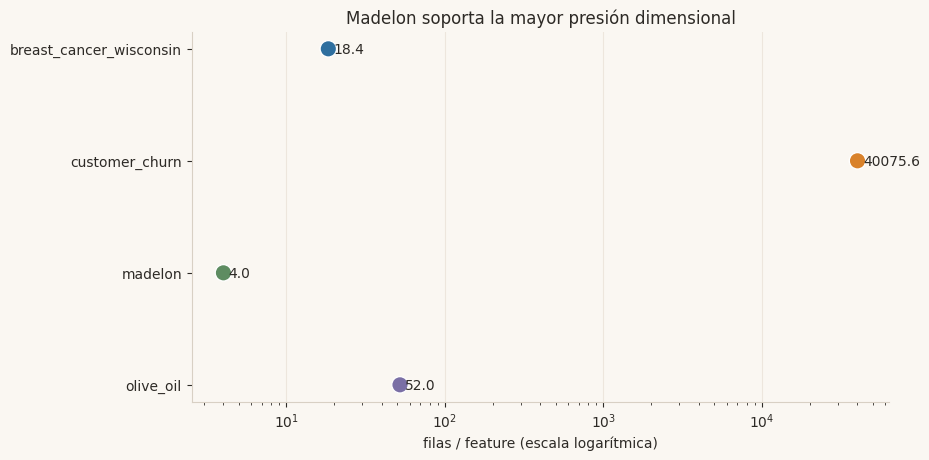

Figura guardada en formatos PNG y PDF.


In [19]:
figura, eje = plt.subplots(figsize=(9, 4.8))
datos_grafico = estructura_datasets.set_index("dataset").loc[ORDEN_DATASETS].reset_index()
sns.scatterplot(
    datos_grafico,
    y="dataset",
    x="filas_por_feature",
    hue="dataset",
    palette=PALETA_DATASETS,
    s=140,
    legend=False,
    ax=eje,
)
eje.set_xscale("log")
eje.set_title("Madelon soporta la mayor presión dimensional")
eje.set_xlabel("filas / feature (escala logarítmica)")
eje.set_ylabel("")
aplicar_estilo_eje(eje)
for _, fila in datos_grafico.iterrows():
    eje.text(fila["filas_por_feature"] * 1.08, fila["dataset"], f'{fila["filas_por_feature"]:.1f}', va="center")
ruta_figura = guardar_figura(figura, "01_02_estructura_filas_por_feature.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La figura confirma que `madelon` es el dataset con menos filas por variable predictora, mientras que `customer_churn` dispone de muchas observaciones por cada feature. Por tanto, la Fase 2 deberá tratar la dimensionalidad de `madelon` con especial cuidado.


## 1.3 Calidad del Dato Crudo

La calidad se revisa por dataset. Se separan nulos, duplicados, constantes, baja cardinalidad relativa y dominancia de moda para evitar nombres opacos como `baja_varianza_o_dominancia`. El umbral de moda dominante del 98% se usa solo como alerta exploratoria de variables casi constantes.


In [20]:
UMBRAL_CARDINALIDAD_RELATIVA_BAJA = 0.01
UMBRAL_MODA_DOMINANTE = 0.98


In [21]:
def contar_nulos_totales(datos_dataset):
    return int(datos_dataset.isna().sum().sum())


def contar_filas_duplicadas(datos_dataset):
    return int(datos_dataset.duplicated().sum())


def calcular_ratio_valores_unicos(serie):
    return serie.nunique(dropna=True) / len(serie)


def calcular_frecuencia_moda(serie):
    return float(serie.value_counts(dropna=False, normalize=True).iloc[0])


In [22]:
def resumir_calidad_variable(nombre_dataset, variable, serie):
    valores_unicos = int(serie.nunique(dropna=True))
    ratio_unicos = calcular_ratio_valores_unicos(serie)
    frecuencia_moda = calcular_frecuencia_moda(serie)
    return {
        "dataset": nombre_dataset,
        "variable": variable,
        "nulos": int(serie.isna().sum()),
        "valores_unicos": valores_unicos,
        "ratio_valores_unicos": ratio_unicos,
        "frecuencia_moda": frecuencia_moda,
        "constante": valores_unicos <= 1,
        "baja_cardinalidad_relativa": ratio_unicos <= UMBRAL_CARDINALIDAD_RELATIVA_BAJA,
        "moda_dominante": frecuencia_moda >= UMBRAL_MODA_DOMINANTE,
    }


def resumir_calidad_variables(nombre_dataset, datos_dataset, target):
    columnas_predictoras = obtener_columnas_predictoras(datos_dataset, target)
    return pd.DataFrame([
        resumir_calidad_variable(nombre_dataset, variable, datos_dataset[variable])
        for variable in columnas_predictoras
    ])


In [23]:
def resumir_calidad_dataset(nombre_dataset, datos_dataset, calidad_variables):
    return {
        "dataset": nombre_dataset,
        "nulos_totales": contar_nulos_totales(datos_dataset),
        "filas_duplicadas": contar_filas_duplicadas(datos_dataset),
        "variables_constantes": int(calidad_variables["constante"].sum()),
        "variables_baja_cardinalidad_relativa": int(calidad_variables["baja_cardinalidad_relativa"].sum()),
        "variables_moda_dominante_98": int(calidad_variables["moda_dominante"].sum()),
    }


def seleccionar_variables_calidad(calidad_variables):
    mascara_revision = (
        calidad_variables["constante"]
        | calidad_variables["baja_cardinalidad_relativa"]
        | calidad_variables["moda_dominante"]
    )
    return calidad_variables[mascara_revision].sort_values("frecuencia_moda", ascending=False)


### Calidad: `breast_cancer_wisconsin`


In [24]:
calidad_variables_breast_cancer_wisconsin = resumir_calidad_variables(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)
calidad_breast_cancer_wisconsin = pd.DataFrame([
    resumir_calidad_dataset("breast_cancer_wisconsin", breast_cancer_wisconsin, calidad_variables_breast_cancer_wisconsin)
])
variables_calidad_revision_breast_cancer_wisconsin = seleccionar_variables_calidad(calidad_variables_breast_cancer_wisconsin)

display(calidad_breast_cancer_wisconsin)
if variables_calidad_revision_breast_cancer_wisconsin.empty:
    display(Markdown("No hay variables marcadas para revisión por estas reglas."))
else:
    display(variables_calidad_revision_breast_cancer_wisconsin.style.format({
        "ratio_valores_unicos": "{:.4f}",
        "frecuencia_moda": "{:.2%}",
    }))


,dataset,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,variables con moda dominante al 98%
no,Breast Cancer Wisconsin,0,0,0,0,0


No hay variables marcadas para revisión por estas reglas.

No se observan nulos, duplicados, constantes ni variables marcadas por baja cardinalidad o moda dominante: las 5 alertas agregadas quedan en 0. En esta sección no aparece señal que justifique limpieza automática.


### Calidad: `customer_churn`


In [25]:
calidad_variables_customer_churn = resumir_calidad_variables(
    "customer_churn",
    customer_churn,
    targets_esperados["customer_churn"],
)
calidad_customer_churn = pd.DataFrame([
    resumir_calidad_dataset("customer_churn", customer_churn, calidad_variables_customer_churn)
])
variables_calidad_revision_customer_churn = seleccionar_variables_calidad(calidad_variables_customer_churn)

display(calidad_customer_churn)
if variables_calidad_revision_customer_churn.empty:
    display(Markdown("No hay variables marcadas para revisión por estas reglas."))
else:
    display(variables_calidad_revision_customer_churn.style.format({
        "ratio_valores_unicos": "{:.4f}",
        "frecuencia_moda": "{:.2%}",
    }))


,dataset,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,variables con moda dominante al 98%
no,Customer Churn,0,0,0,9,0


,dataset,variable,nulos,valores unicos,valores únicos / filas,frecuencia moda,constante,baja cardinalidad relativa,moda dominante
2,Customer Churn,Gender,0,2,0.000005,0.567681,no,sí,no
8,Customer Churn,Contract Length,0,3,0.000007,0.401963,no,sí,no
7,Customer Churn,Subscription Type,0,3,0.000007,0.338288,no,sí,no
5,Customer Churn,Support Calls,0,11,0.000025,0.158507,no,sí,no
6,Customer Churn,Payment Delay,0,31,0.000070,0.039013,no,sí,no
10,Customer Churn,Last Interaction,0,30,0.000068,0.038368,no,sí,no
4,Customer Churn,Usage Frequency,0,30,0.000068,0.034732,no,sí,no
sí,Customer Churn,Age,0,48,0.000109,0.030685,no,sí,no
3,Customer Churn,Tenure,0,60,0.000136,0.017757,no,sí,no


No se observan nulos ni duplicados. Aparecen 9 variables con baja cardinalidad relativa; esto no implica error, porque varias variables son categóricas o discretas.


### Calidad: `madelon`


In [26]:
calidad_variables_madelon = resumir_calidad_variables(
    "madelon",
    madelon,
    targets_esperados["madelon"],
)
calidad_madelon = pd.DataFrame([
    resumir_calidad_dataset("madelon", madelon, calidad_variables_madelon)
])
variables_calidad_revision_madelon = seleccionar_variables_calidad(calidad_variables_madelon)

display(calidad_madelon)
if variables_calidad_revision_madelon.empty:
    display(Markdown("No hay variables marcadas para revisión por estas reglas."))
else:
    display(variables_calidad_revision_madelon.style.format({
        "ratio_valores_unicos": "{:.4f}",
        "frecuencia_moda": "{:.2%}",
    }))


,dataset,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,variables con moda dominante al 98%
no,Madelon,0,0,0,24,0


,dataset,variable,nulos,valores unicos,valores únicos / filas,frecuencia moda,constante,baja cardinalidad relativa,moda dominante
90,Madelon,feat_90,0,5,0.002500,0.660500,no,sí,no
423,Madelon,feat_423,0,5,0.002500,0.626000,no,sí,no
276,Madelon,feat_276,0,5,0.002500,0.579000,no,sí,no
404,Madelon,feat_404,0,6,0.003000,0.436000,no,sí,no
332,Madelon,feat_332,0,8,0.004000,0.421000,no,sí,no
228,Madelon,feat_228,0,7,0.003500,0.408500,no,sí,no
168,Madelon,feat_168,0,9,0.004500,0.334000,no,sí,no
173,Madelon,feat_173,0,9,0.004500,0.318500,no,sí,no
283,Madelon,feat_283,0,10,0.005000,0.297500,no,sí,no
205,Madelon,feat_205,0,11,0.005500,0.290500,no,sí,no


No se observan nulos ni duplicados. Aparecen 24 variables de baja cardinalidad relativa dentro de una matriz de 500 features, por lo que conviene revisarlas antes de selección formal.


### Calidad: `olive_oil`


In [27]:
calidad_variables_olive_oil = resumir_calidad_variables(
    "olive_oil",
    olive_oil,
    targets_esperados["olive_oil"],
)
calidad_olive_oil = pd.DataFrame([
    resumir_calidad_dataset("olive_oil", olive_oil, calidad_variables_olive_oil)
])
variables_calidad_revision_olive_oil = seleccionar_variables_calidad(calidad_variables_olive_oil)

display(calidad_olive_oil)
if variables_calidad_revision_olive_oil.empty:
    display(Markdown("No hay variables marcadas para revisión por estas reglas."))
else:
    display(variables_calidad_revision_olive_oil.style.format({
        "ratio_valores_unicos": "{:.4f}",
        "frecuencia_moda": "{:.2%}",
    }))


,dataset,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,variables con moda dominante al 98%
no,Olive Oil,0,0,0,1,0


,dataset,variable,nulos,valores unicos,valores únicos / filas,frecuencia moda,constante,baja cardinalidad relativa,moda dominante
sí,Olive Oil,Area,0,3,0.005245,0.564685,no,sí,no


No se observan nulos ni duplicados. La variable `Area` es la única de 11 predictoras que aparece por baja cardinalidad relativa; no se elimina aquí porque puede ser semánticamente relevante y debe analizarse frente al target.


### Resumen Comparativo de Calidad

La comparación se construye después de revisar cada dataset por separado. No se genera una figura si la tabla responde mejor la pregunta de calidad.


In [28]:
calidad_datasets = pd.concat([
    calidad_breast_cancer_wisconsin,
    calidad_customer_churn,
    calidad_madelon,
    calidad_olive_oil,
], ignore_index=True)

calidad_variables = pd.concat([
    calidad_variables_breast_cancer_wisconsin,
    calidad_variables_customer_churn,
    calidad_variables_madelon,
    calidad_variables_olive_oil,
], ignore_index=True)

guardar_tabla(calidad_datasets, "fase1_calidad_datasets.csv")
guardar_tabla(calidad_variables, "fase1_calidad_variables.csv")
display(calidad_datasets)


,dataset,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,variables con moda dominante al 98%
no,Breast Cancer Wisconsin,0,0,0,0,0
sí,Customer Churn,0,0,0,9,0
2,Madelon,0,0,0,24,0
3,Olive Oil,0,0,0,1,0


El resumen comparativo no detecta nulos, duplicados ni variables constantes en ninguno de los 4 datasets. Las alertas se concentran en baja cardinalidad relativa: 9 variables en `customer_churn`, 24 en `madelon`, 1 en `olive_oil` y 0 en `breast_cancer_wisconsin`; como no hay modas dominantes al 98%, la siguiente pregunta no es limpieza por defecto, sino cómo esas variables se relacionan con el target.


## 1.4 Análisis del Target

El target se analiza por dataset porque su distribución condiciona particiones, métricas y lectura de resultados. No se usa un umbral universal de desbalance: se informa la proporción de clases y el ratio entre clase mayoritaria y minoritaria.


In [29]:
def calcular_distribucion_target(nombre_dataset, datos_dataset, target):
    conteos = datos_dataset[target].value_counts(dropna=False)
    proporciones = datos_dataset[target].value_counts(dropna=False, normalize=True)
    return pd.DataFrame({
        "dataset": nombre_dataset,
        "target": target,
        "clase": conteos.index.astype(str),
        "n": conteos.values,
        "proporcion": proporciones.values,
    })


def resumir_balance_target(distribucion_target):
    clase_mayor = distribucion_target.sort_values("n", ascending=False).iloc[0]
    clase_menor = distribucion_target.sort_values("n", ascending=True).iloc[0]
    hay_empate = clase_mayor["n"] == clase_menor["n"]
    return {
        "dataset": distribucion_target["dataset"].iloc[0],
        "target": distribucion_target["target"].iloc[0],
        "n_clases": len(distribucion_target),
        "clase_mayoritaria": "empate" if hay_empate else clase_mayor["clase"],
        "clase_minoritaria": "empate" if hay_empate else clase_menor["clase"],
        "ratio_mayoritaria_minoritaria": clase_mayor["n"] / clase_menor["n"],
    }


In [30]:
def anotar_barras_target(eje, distribucion_target):
    for contenedor in eje.containers:
        etiquetas = [f"{proporcion:.1%}" for proporcion in distribucion_target["proporcion"]]
        eje.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=9)


def graficar_target_dataset(distribucion_target):
    nombre_dataset = distribucion_target["dataset"].iloc[0]
    datos_grafico = distribucion_target.sort_values("proporcion", ascending=True)
    alto_figura = max(3.2, 0.42 * len(datos_grafico) + 1.8)
    figura, eje = plt.subplots(figsize=(8.5, alto_figura))
    sns.barplot(datos_grafico, y="clase", x="proporcion", color=PALETA_DATASETS[nombre_dataset], ax=eje)
    eje.set_title(f"Distribución del target en {nombre_dataset}")
    eje.set_xlabel("proporción")
    eje.set_ylabel("")
    eje.xaxis.set_major_formatter(lambda valor, posicion: f"{valor:.0%}")
    aplicar_estilo_eje(eje)
    anotar_barras_target(eje, datos_grafico)
    figura.tight_layout()
    return figura


def graficar_desbalance_comparado(target_resumen):
    datos_grafico = target_resumen.set_index("dataset").loc[ORDEN_DATASETS].reset_index()
    datos_grafico = datos_grafico.sort_values("ratio_mayoritaria_minoritaria")
    figura, eje = plt.subplots(figsize=(9, 4.8))
    colores = [
        PALETA_DATASETS[dataset] if dataset == datos_grafico.iloc[-1]["dataset"] else "#B8B0A3"
        for dataset in datos_grafico["dataset"]
    ]
    eje.barh(datos_grafico["dataset"], datos_grafico["ratio_mayoritaria_minoritaria"], color=colores)
    eje.axvline(1, color="#6F6A60", linewidth=1.1, linestyle="--")
    eje.set_title("Olive Oil concentra el mayor desbalance del target")
    eje.set_xlabel("ratio clase mayoritaria / minoritaria")
    eje.set_ylabel("")
    aplicar_estilo_eje(eje)
    caso_extremo = datos_grafico.iloc[-1]
    eje.annotate(
        f'{caso_extremo["ratio_mayoritaria_minoritaria"]:.2f}:1',
        xy=(caso_extremo["ratio_mayoritaria_minoritaria"], caso_extremo["dataset"]),
        xytext=(caso_extremo["ratio_mayoritaria_minoritaria"] * 0.78, caso_extremo["dataset"]),
        va="center",
        ha="right",
        arrowprops={"arrowstyle": "->", "color": "#6F6A60", "lw": 1},
    )
    for _, fila in datos_grafico.iloc[:-1].iterrows():
        eje.text(fila["ratio_mayoritaria_minoritaria"] + 0.08, fila["dataset"], f'{fila["ratio_mayoritaria_minoritaria"]:.2f}:1', va="center")
    figura.tight_layout()
    return figura


### Target: `breast_cancer_wisconsin`


In [31]:
target_distribucion_breast_cancer_wisconsin = calcular_distribucion_target(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)
target_resumen_breast_cancer_wisconsin = pd.DataFrame([resumir_balance_target(target_distribucion_breast_cancer_wisconsin)])

display(target_resumen_breast_cancer_wisconsin.style.format({"ratio_mayoritaria_minoritaria": "{:.3f}"}))
display(target_distribucion_breast_cancer_wisconsin.style.format({"proporcion": "{:.2%}"}))


,dataset,target,n clases,clase mayoritaria,clase minoritaria,ratio mayoritaria / minoritaria
no,Breast Cancer Wisconsin,target,2,B,M,1.683962


,dataset,target,clase,observaciones,proporcion
no,Breast Cancer Wisconsin,target,B,357,0.627417
sí,Breast Cancer Wisconsin,target,M,212,0.372583


El target es binario y la clase `B` es mayoritaria. El ratio mayoritaria/minoritaria es 1,684, por lo que en modelado conviene no depender solo de accuracy.


### Target: `customer_churn`


In [32]:
target_distribucion_customer_churn = calcular_distribucion_target(
    "customer_churn",
    customer_churn,
    targets_esperados["customer_churn"],
)
target_resumen_customer_churn = pd.DataFrame([resumir_balance_target(target_distribucion_customer_churn)])

display(target_resumen_customer_churn.style.format({"ratio_mayoritaria_minoritaria": "{:.3f}"}))
display(target_distribucion_customer_churn.style.format({"proporcion": "{:.2%}"}))


,dataset,target,n clases,clase mayoritaria,clase minoritaria,ratio mayoritaria / minoritaria
no,Customer Churn,Churn,2,1.0,0.0,1.310041


,dataset,target,clase,observaciones,proporcion
no,Customer Churn,Churn,1.0,249999,0.567107
sí,Customer Churn,Churn,0.0,190833,0.432893


El target es binario y `1.0` es la clase mayoritaria. El tamaño muestral es grande, así que pequeñas diferencias pueden resultar estadísticamente significativas.


### Target: `madelon`


In [33]:
target_distribucion_madelon = calcular_distribucion_target(
    "madelon",
    madelon,
    targets_esperados["madelon"],
)
target_resumen_madelon = pd.DataFrame([resumir_balance_target(target_distribucion_madelon)])

display(target_resumen_madelon.style.format({"ratio_mayoritaria_minoritaria": "{:.3f}"}))
display(target_distribucion_madelon.style.format({"proporcion": "{:.2%}"}))


,dataset,target,n clases,clase mayoritaria,clase minoritaria,ratio mayoritaria / minoritaria
no,Madelon,target,2,empate,empate,1.000000


,dataset,target,clase,observaciones,proporcion
no,Madelon,target,-1,1000,0.500000
sí,Madelon,target,1,1000,0.500000


El target está perfectamente balanceado: las dos clases tienen 1.000 observaciones. El reto principal no es el desbalance, sino la dimensionalidad y el ruido.


### Target: `olive_oil`


In [34]:
target_distribucion_olive_oil = calcular_distribucion_target(
    "olive_oil",
    olive_oil,
    targets_esperados["olive_oil"],
)
target_resumen_olive_oil = pd.DataFrame([resumir_balance_target(target_distribucion_olive_oil)])

display(target_resumen_olive_oil.style.format({"ratio_mayoritaria_minoritaria": "{:.3f}"}))
display(target_distribucion_olive_oil.style.format({"proporcion": "{:.2%}"}))


,dataset,target,n clases,clase mayoritaria,clase minoritaria,ratio mayoritaria / minoritaria
no,Olive Oil,target,9,South-Apulia,North-Apulia,8.240000


,dataset,target,clase,observaciones,proporcion
no,Olive Oil,target,South-Apulia,206,0.360140
sí,Olive Oil,target,Inland-Sardinia,65,0.113636
2,Olive Oil,target,Calabria,56,0.097902
3,Olive Oil,target,Umbria,51,0.089161
4,Olive Oil,target,West-Liguria,50,0.087413
5,Olive Oil,target,East-Liguria,50,0.087413
6,Olive Oil,target,Sicily,36,0.062937
7,Olive Oil,target,Coast-Sardinia,33,0.057692
8,Olive Oil,target,North-Apulia,25,0.043706


El target tiene 9 clases y `South-Apulia` domina frente a clases pequeñas como `North-Apulia`, con ratio 8,240. Las fases posteriores deberán preservar clases minoritarias.


### Resumen Comparativo del Target

Después de revisar cada distribución, se conserva una tabla conjunta para consultar número de clases y ratio de balance.


,dataset,target,n clases,clase mayoritaria,clase minoritaria,ratio mayoritaria / minoritaria
no,Breast Cancer Wisconsin,target,2,B,M,1.683962
sí,Customer Churn,Churn,2,1.0,0.0,1.310041
2,Madelon,target,2,empate,empate,1.000000
3,Olive Oil,target,9,South-Apulia,North-Apulia,8.240000


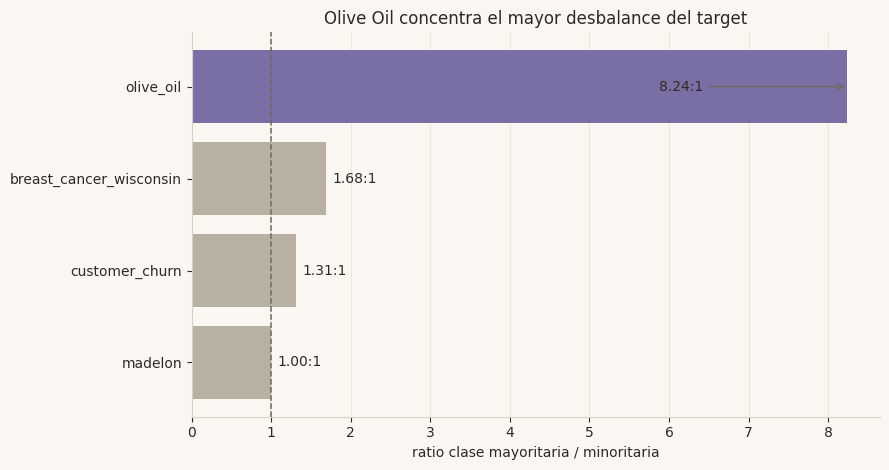

Figura guardada en formatos PNG y PDF.


In [35]:
target_distribucion = pd.concat([
    target_distribucion_breast_cancer_wisconsin,
    target_distribucion_customer_churn,
    target_distribucion_madelon,
    target_distribucion_olive_oil,
], ignore_index=True)

target_resumen = pd.concat([
    target_resumen_breast_cancer_wisconsin,
    target_resumen_customer_churn,
    target_resumen_madelon,
    target_resumen_olive_oil,
], ignore_index=True)

guardar_tabla(target_distribucion, "fase1_target_distribucion.csv")
guardar_tabla(target_resumen, "fase1_target_resumen.csv")
display(target_resumen.style.format({"ratio_mayoritaria_minoritaria": "{:.3f}"}))

figura = graficar_desbalance_comparado(target_resumen)
ruta_figura = guardar_figura(figura, "01_04_target_desbalance_comparado.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La comparación resume los cuatro targets sin repetir las tablas de distribución. `madelon` queda exactamente balanceado con ratio 1,000; `customer_churn` alcanza 1,310; `breast_cancer_wisconsin` sube a 1,684; y `olive_oil` es el caso extremo con 9 clases y ratio 8,240 entre `South-Apulia` y `North-Apulia`. Esta lectura deja abierta la necesidad de estratificación, que se comprobará al construir particiones en fases posteriores.


## 1.5 Muestreo Visual

El muestreo visual solo se aplica cuando una figura sería difícil de leer por tamaño muestral. No sustituye los cálculos estadísticos sobre datos completos. Si se muestrea, se comprueba la distribución del target completo frente a la muestra.


In [36]:
def necesita_muestra_visual(datos_dataset):
    return len(datos_dataset) > MAX_FILAS_MUESTRA_VISUAL


def calcular_fraccion_muestreo(datos_dataset):
    return MAX_FILAS_MUESTRA_VISUAL / len(datos_dataset)


def crear_muestra_estratificada(datos_dataset, target):
    fraccion = calcular_fraccion_muestreo(datos_dataset)
    return (
        datos_dataset
        .groupby(target, group_keys=False, dropna=False)
        .sample(frac=fraccion, random_state=RANDOM_STATE)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


def crear_muestra_visual_dataset(datos_dataset, target):
    if necesita_muestra_visual(datos_dataset):
        return crear_muestra_estratificada(datos_dataset, target), "muestra_estratificada_visual"
    return datos_dataset.copy(), "completo"


In [37]:
def comparar_target_completo_muestra(nombre_dataset, datos_dataset, muestra_visual, target):
    completo = datos_dataset[target].value_counts(normalize=True, dropna=False)
    muestra = muestra_visual[target].value_counts(normalize=True, dropna=False)
    return pd.DataFrame([
        {
            "dataset": nombre_dataset,
            "clase": str(clase),
            "proporcion_completa": completo.loc[clase],
            "proporcion_muestra_visual": muestra.get(clase, np.nan),
            "diferencia_absoluta": abs(completo.loc[clase] - muestra.get(clase, np.nan)),
        }
        for clase in completo.index
    ])


def resumir_muestra_visual(nombre_dataset, datos_dataset, muestra_visual, tipo_muestra):
    return pd.DataFrame([{
        "dataset": nombre_dataset,
        "filas_originales": len(datos_dataset),
        "filas_muestra_visual": len(muestra_visual),
        "tipo_muestra": tipo_muestra,
    }])


### Muestreo Visual: `breast_cancer_wisconsin`


In [38]:
muestra_visual_breast_cancer_wisconsin, tipo_muestra_breast_cancer_wisconsin = crear_muestra_visual_dataset(
    breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)
muestreo_breast_cancer_wisconsin = resumir_muestra_visual(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    muestra_visual_breast_cancer_wisconsin,
    tipo_muestra_breast_cancer_wisconsin,
)
target_muestra_breast_cancer_wisconsin = comparar_target_completo_muestra(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    muestra_visual_breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)

display(muestreo_breast_cancer_wisconsin)
display(target_muestra_breast_cancer_wisconsin.style.format({
    "proporcion_completa": "{:.3%}",
    "proporcion_muestra_visual": "{:.3%}",
    "diferencia_absoluta": "{:.4%}",
}))


,dataset,filas originales,filas muestra visual,tipo muestra
no,Breast Cancer Wisconsin,569,569,completo


,dataset,clase,proporcion completa,proporcion muestra visual,diferencia absoluta
no,Breast Cancer Wisconsin,B,0.627417,0.627417,0.000000
sí,Breast Cancer Wisconsin,M,0.372583,0.372583,0.000000


El dataset conserva sus 569 filas porque queda por debajo del límite visual de 5.000. Las visualizaciones pueden usar el conjunto completo.


### Muestreo Visual: `customer_churn`


In [39]:
muestra_visual_customer_churn, tipo_muestra_customer_churn = crear_muestra_visual_dataset(
    customer_churn,
    targets_esperados["customer_churn"],
)
muestreo_customer_churn = resumir_muestra_visual(
    "customer_churn",
    customer_churn,
    muestra_visual_customer_churn,
    tipo_muestra_customer_churn,
)
target_muestra_customer_churn = comparar_target_completo_muestra(
    "customer_churn",
    customer_churn,
    muestra_visual_customer_churn,
    targets_esperados["customer_churn"],
)

display(muestreo_customer_churn)
display(target_muestra_customer_churn.style.format({
    "proporcion_completa": "{:.3%}",
    "proporcion_muestra_visual": "{:.3%}",
    "diferencia_absoluta": "{:.4%}",
}))


,dataset,filas originales,filas muestra visual,tipo muestra
no,Customer Churn,440832,5000,muestra estratificada visual


,dataset,clase,proporcion completa,proporcion muestra visual,diferencia absoluta
no,Customer Churn,1.0,0.567107,0.567200,0.000093
sí,Customer Churn,0.0,0.432893,0.432800,0.000093


Se crea una muestra visual estratificada de 5.000 filas. La comparación del target permite comprobar que la muestra conserva prácticamente las proporciones originales.


### Muestreo Visual: `madelon`


In [40]:
muestra_visual_madelon, tipo_muestra_madelon = crear_muestra_visual_dataset(
    madelon,
    targets_esperados["madelon"],
)
muestreo_madelon = resumir_muestra_visual(
    "madelon",
    madelon,
    muestra_visual_madelon,
    tipo_muestra_madelon,
)
target_muestra_madelon = comparar_target_completo_muestra(
    "madelon",
    madelon,
    muestra_visual_madelon,
    targets_esperados["madelon"],
)

display(muestreo_madelon)
display(target_muestra_madelon.style.format({
    "proporcion_completa": "{:.3%}",
    "proporcion_muestra_visual": "{:.3%}",
    "diferencia_absoluta": "{:.4%}",
}))


,dataset,filas originales,filas muestra visual,tipo muestra
no,Madelon,2000,2000,completo


,dataset,clase,proporcion completa,proporcion muestra visual,diferencia absoluta
no,Madelon,-1,0.500000,0.500000,0.000000
sí,Madelon,1,0.500000,0.500000,0.000000


`madelon` mantiene sus 2.000 filas completas. El problema principal es dimensional, no de volumen muestral para visualización.


### Muestreo Visual: `olive_oil`


In [41]:
muestra_visual_olive_oil, tipo_muestra_olive_oil = crear_muestra_visual_dataset(
    olive_oil,
    targets_esperados["olive_oil"],
)
muestreo_olive_oil = resumir_muestra_visual(
    "olive_oil",
    olive_oil,
    muestra_visual_olive_oil,
    tipo_muestra_olive_oil,
)
target_muestra_olive_oil = comparar_target_completo_muestra(
    "olive_oil",
    olive_oil,
    muestra_visual_olive_oil,
    targets_esperados["olive_oil"],
)

display(muestreo_olive_oil)
display(target_muestra_olive_oil.style.format({
    "proporcion_completa": "{:.3%}",
    "proporcion_muestra_visual": "{:.3%}",
    "diferencia_absoluta": "{:.4%}",
}))


,dataset,filas originales,filas muestra visual,tipo muestra
no,Olive Oil,572,572,completo


,dataset,clase,proporcion completa,proporcion muestra visual,diferencia absoluta
no,Olive Oil,South-Apulia,0.360140,0.360140,0.000000
sí,Olive Oil,Inland-Sardinia,0.113636,0.113636,0.000000
2,Olive Oil,Calabria,0.097902,0.097902,0.000000
3,Olive Oil,Umbria,0.089161,0.089161,0.000000
4,Olive Oil,West-Liguria,0.087413,0.087413,0.000000
5,Olive Oil,East-Liguria,0.087413,0.087413,0.000000
6,Olive Oil,Sicily,0.062937,0.062937,0.000000
7,Olive Oil,Coast-Sardinia,0.057692,0.057692,0.000000
8,Olive Oil,North-Apulia,0.043706,0.043706,0.000000


`olive_oil` conserva 572 filas. Dado su target de 9 clases, mantener todas las observaciones evita perder clases minoritarias en diagnósticos visuales.


In [42]:
muestras_visuales = {
    "breast_cancer_wisconsin": muestra_visual_breast_cancer_wisconsin,
    "customer_churn": muestra_visual_customer_churn,
    "madelon": muestra_visual_madelon,
    "olive_oil": muestra_visual_olive_oil,
}

muestreo_resumen = pd.concat([
    muestreo_breast_cancer_wisconsin,
    muestreo_customer_churn,
    muestreo_madelon,
    muestreo_olive_oil,
], ignore_index=True)
muestreo_target = pd.concat([
    target_muestra_breast_cancer_wisconsin,
    target_muestra_customer_churn,
    target_muestra_madelon,
    target_muestra_olive_oil,
], ignore_index=True)

guardar_tabla(muestreo_resumen, "fase1_muestreo_visual_resumen.csv")
guardar_tabla(muestreo_target, "fase1_muestreo_visual_target.csv")
display(muestreo_resumen)


,dataset,filas originales,filas muestra visual,tipo muestra
no,Breast Cancer Wisconsin,569,569,completo
sí,Customer Churn,440832,5000,muestra estratificada visual
2,Madelon,2000,2000,completo
3,Olive Oil,572,572,completo


El cierre de muestreo deja 3 datasets completos y 1 dataset reducido solo para visualización. `customer_churn` pasa de 440.832 a 5.000 filas visuales mediante muestreo estratificado; `breast_cancer_wisconsin`, `madelon` y `olive_oil` conservan 569, 2.000 y 572 filas respectivamente. Los cálculos estadísticos posteriores siguen usando datos completos salvo que se indique muestra visual.


## 1.6 Análisis Univariante de Variables Numéricas

El análisis univariante busca asimetría, colas pesadas y outliers estadísticos. La técnica combina estadísticos descriptivos, skewness, kurtosis y tasa de outliers por criterio IQR 1,5; se calcula una tabla completa por dataset y se visualizan variables seleccionadas por señal empírica, no una única variable arbitraria.


In [43]:
def obtener_columnas_numericas_predictoras(datos_dataset, target):
    columnas_predictoras = obtener_columnas_predictoras(datos_dataset, target)
    identificadores = set(listar_posibles_identificadores(datos_dataset, target))
    return [
        variable for variable in datos_dataset[columnas_predictoras].select_dtypes(include=np.number).columns
        if variable not in identificadores
    ]


def calcular_tasa_outliers_iqr(serie):
    serie_limpia = serie.dropna()
    q1, q3 = serie_limpia.quantile([0.25, 0.75])
    rango_intercuartilico = q3 - q1
    if rango_intercuartilico == 0:
        return 0.0
    limite_inferior = q1 - 1.5 * rango_intercuartilico
    limite_superior = q3 + 1.5 * rango_intercuartilico
    return float(((serie_limpia < limite_inferior) | (serie_limpia > limite_superior)).mean())


In [44]:
def resumir_variable_numerica(nombre_dataset, variable, serie):
    return {
        "dataset": nombre_dataset,
        "variable": variable,
        "media": serie.mean(),
        "desviacion": serie.std(),
        "minimo": serie.min(),
        "mediana": serie.median(),
        "maximo": serie.max(),
        "skewness": serie.skew(),
        "kurtosis": serie.kurtosis(),
        "outlier_rate_iqr": calcular_tasa_outliers_iqr(serie),
        "missing_pct": serie.isna().mean(),
    }


def resumir_distribuciones_dataset(nombre_dataset, datos_dataset, target):
    columnas_numericas = obtener_columnas_numericas_predictoras(datos_dataset, target)
    return pd.DataFrame([
        resumir_variable_numerica(nombre_dataset, variable, datos_dataset[variable])
        for variable in columnas_numericas
    ])


In [45]:
def seleccionar_variables_univariantes(distribuciones_dataset, max_variables=4):
    variables_outliers = distribuciones_dataset.nlargest(max_variables, "outlier_rate_iqr")["variable"]
    variables_asimetria = (
        distribuciones_dataset
        .assign(skew_abs=lambda tabla: tabla["skewness"].abs())
        .nlargest(max_variables, "skew_abs")["variable"]
    )
    variables = pd.concat([variables_outliers, variables_asimetria]).drop_duplicates()
    return variables.head(max_variables).tolist()


def graficar_distribuciones_univariantes(nombre_dataset, datos_visual, variables_foco):
    numero_variables = len(variables_foco)
    figura, ejes = plt.subplots(1, numero_variables, figsize=(4.3 * numero_variables, 3.8))
    ejes = np.atleast_1d(ejes)
    for eje, variable in zip(ejes, variables_foco):
        sns.histplot(datos_visual[variable].dropna(), bins="auto", kde=True, color=PALETA_DATASETS[nombre_dataset], ax=eje)
        eje.set_title(variable)
        eje.set_xlabel("")
        aplicar_estilo_eje(eje, "y")
    figura.suptitle(f"Las colas y asimetrías se concentran en variables concretas de {nombre_dataset}", y=1.05)
    figura.tight_layout()
    return figura


### Univariante Numérico: `breast_cancer_wisconsin`


,dataset,variable,media,desviacion,minimo,mediana,maximo,skewness,kurtosis,outlier rate iqr,missing pct,skew abs
13,Breast Cancer Wisconsin,area_se,40.337079,45.491006,6.802000,24.530000,542.200000,5.447186,49.209077,0.114236,0.000000,5.447186
12,Breast Cancer Wisconsin,perimeter_se,2.866059,2.021855,0.757000,2.287000,21.980000,3.443615,21.401905,0.066784,0.000000,3.443615
10,Breast Cancer Wisconsin,radius_se,0.405172,0.277313,0.111500,0.324200,2.873000,3.088612,17.686726,0.066784,0.000000,3.088612
23,Breast Cancer Wisconsin,area_worst,880.583128,569.356993,185.200000,686.500000,4254.000000,1.859373,4.396395,0.061511,0.000000,1.859373
14,Breast Cancer Wisconsin,smoothness_se,0.007041,0.003003,0.001713,0.006380,0.031130,2.314450,10.469840,0.052724,0.000000,2.314450
19,Breast Cancer Wisconsin,fractal_dimension_se,0.003795,0.002646,0.000895,0.003187,0.029840,3.923969,26.280847,0.049209,0.000000,3.923969
15,Breast Cancer Wisconsin,compactness_se,0.025478,0.017908,0.002252,0.020450,0.135400,1.902221,5.106252,0.049209,0.000000,1.902221
18,Breast Cancer Wisconsin,symmetry_se,0.020542,0.008266,0.007882,0.018730,0.078950,2.195133,7.896130,0.047452,0.000000,2.195133
3,Breast Cancer Wisconsin,area_mean,654.889104,351.914129,143.500000,551.100000,2501.000000,1.645732,3.652303,0.043937,0.000000,1.645732
29,Breast Cancer Wisconsin,fractal_dimension_worst,0.083946,0.018061,0.055040,0.080040,0.207500,1.662579,5.244611,0.042179,0.000000,1.662579


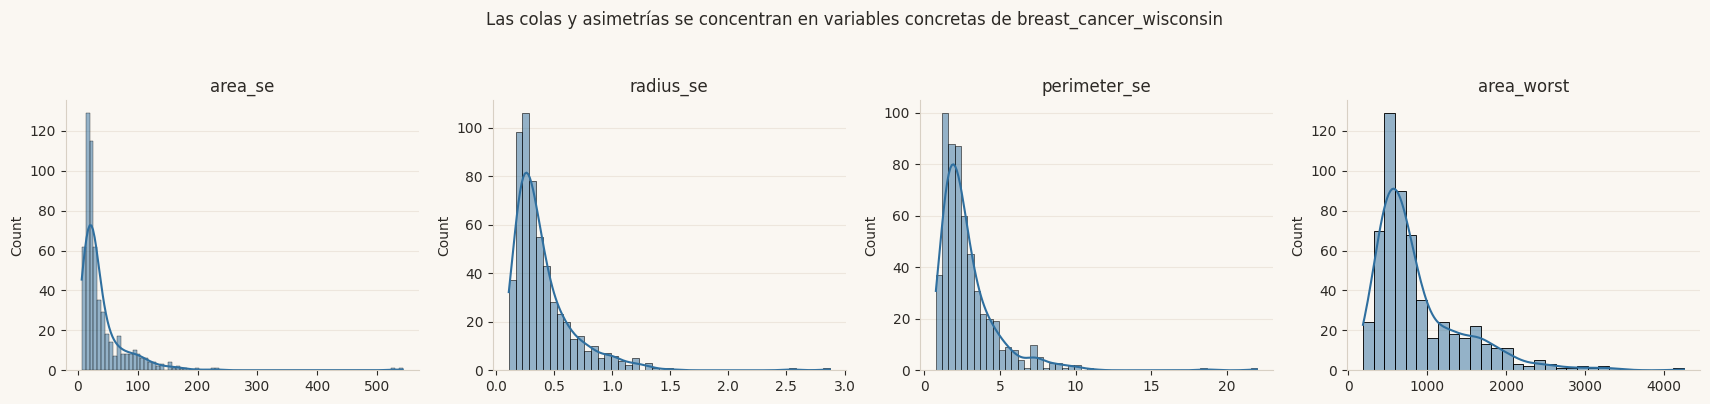

Figura guardada en formatos PNG y PDF.


In [46]:
distribuciones_breast_cancer_wisconsin = resumir_distribuciones_dataset(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)
variables_univariantes_breast_cancer_wisconsin = seleccionar_variables_univariantes(distribuciones_breast_cancer_wisconsin)

display(
    distribuciones_breast_cancer_wisconsin
    .assign(skew_abs=lambda tabla: tabla["skewness"].abs())
    .sort_values(["outlier_rate_iqr", "skew_abs"], ascending=False)
    .head(10)
    .style.format({
        "skewness": "{:.3f}",
        "kurtosis": "{:.3f}",
        "outlier_rate_iqr": "{:.2%}",
        "missing_pct": "{:.2%}",
    })
)

figura = graficar_distribuciones_univariantes(
    "breast_cancer_wisconsin",
    muestras_visuales["breast_cancer_wisconsin"],
    variables_univariantes_breast_cancer_wisconsin,
)
ruta_figura = guardar_figura(figura, "01_06_univariante_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La tabla muestra 30 variables numéricas y outlier rate máximo 11,42%, sobre todo en variables de error (`*_se`). Esto orienta a usar métodos robustos, no a eliminar observaciones automáticamente.


### Univariante Numérico: `customer_churn`


,dataset,variable,media,desviacion,minimo,mediana,maximo,skewness,kurtosis,outlier rate iqr,missing pct,skew abs
3,Customer Churn,Support Calls,3.604437,3.070218,0.000000,3.000000,10.000000,0.666809,-0.745912,0.000000,0.000000,0.666809
5,Customer Churn,Total Spend,631.616223,240.803001,100.000000,661.000000,1000.000000,-0.457174,-0.751489,0.000000,0.000000,0.457174
4,Customer Churn,Payment Delay,12.965722,8.258063,0.000000,12.000000,30.000000,0.267407,-0.895678,0.000000,0.000000,0.267407
6,Customer Churn,Last Interaction,14.480868,8.596208,1.000000,14.000000,30.000000,0.176774,-1.153760,0.000000,0.000000,0.176774
no,Customer Churn,Age,39.373153,12.442369,18.000000,39.000000,65.000000,0.162016,-0.864853,0.000000,0.000000,0.162016
sí,Customer Churn,Tenure,31.256336,17.255727,1.000000,32.000000,60.000000,-0.061402,-1.192523,0.000000,0.000000,0.061402
2,Customer Churn,Usage Frequency,15.807494,8.586242,1.000000,16.000000,30.000000,-0.043473,-1.175815,0.000000,0.000000,0.043473


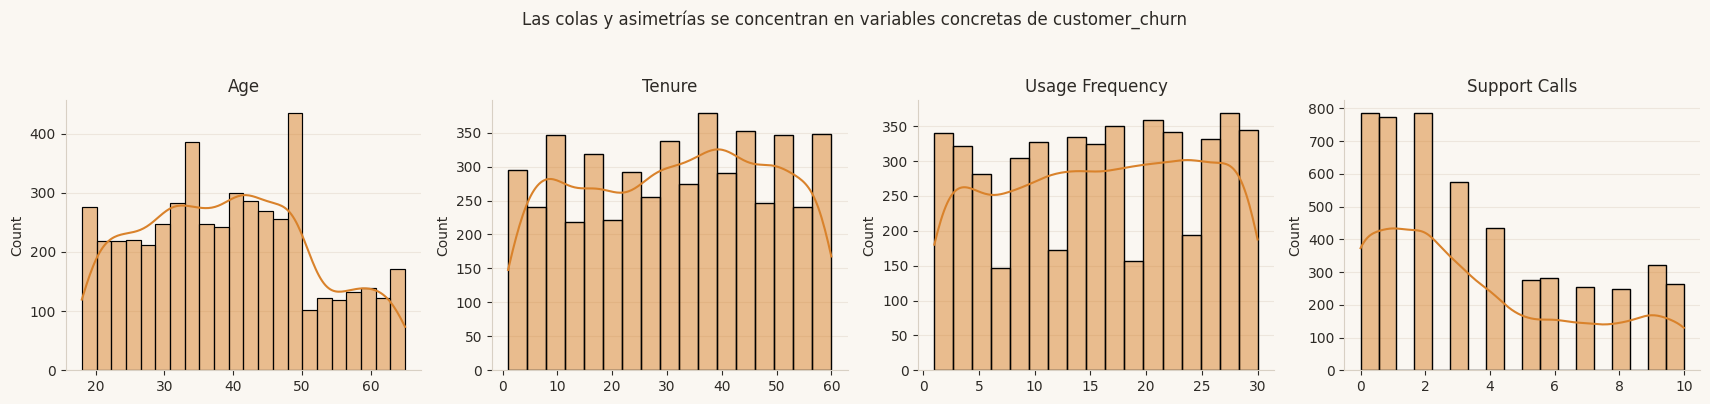

Figura guardada en formatos PNG y PDF.


In [47]:
distribuciones_customer_churn = resumir_distribuciones_dataset(
    "customer_churn",
    customer_churn,
    targets_esperados["customer_churn"],
)
variables_univariantes_customer_churn = seleccionar_variables_univariantes(distribuciones_customer_churn)

display(
    distribuciones_customer_churn
    .assign(skew_abs=lambda tabla: tabla["skewness"].abs())
    .sort_values(["outlier_rate_iqr", "skew_abs"], ascending=False)
    .head(10)
    .style.format({
        "skewness": "{:.3f}",
        "kurtosis": "{:.3f}",
        "outlier_rate_iqr": "{:.2%}",
        "missing_pct": "{:.2%}",
    })
)

figura = graficar_distribuciones_univariantes(
    "customer_churn",
    muestras_visuales["customer_churn"],
    variables_univariantes_customer_churn,
)
ruta_figura = guardar_figura(figura, "01_06_univariante_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 7 variables numéricas son discretas o de rango acotado. La tasa de outliers IQR es 0,00% en esta revisión, por lo que el foco posterior será codificación e interpretación práctica.


### Univariante Numérico: `madelon`


,dataset,variable,media,desviacion,minimo,mediana,maximo,skewness,kurtosis,outlier rate iqr,missing pct,skew abs
198,Madelon,feat_198,476.512000,1.404223,472,477.000000,481,0.020453,0.177416,0.143000,0.000000,0.020453
7,Madelon,feat_7,476.565000,1.384461,471,477.000000,481,0.002038,-0.038258,0.142000,0.000000,0.002038
120,Madelon,feat_120,476.114000,2.168030,469,476.000000,485,-0.031567,0.162128,0.037500,0.000000,0.031567
332,Madelon,feat_332,476.164000,0.947393,473,476.000000,480,0.088585,0.033872,0.035500,0.000000,0.088585
228,Madelon,feat_228,476.366000,0.933531,473,476.000000,479,0.080713,0.014667,0.026500,0.000000,0.080713
392,Madelon,feat_392,476.444500,2.698437,468,476.000000,487,0.174143,0.111107,0.026000,0.000000,0.174143
368,Madelon,feat_368,484.535500,12.496873,440,485.000000,529,0.006010,0.306987,0.022000,0.000000,0.006010
364,Madelon,feat_364,480.900000,5.143756,459,481.000000,501,0.028512,0.260727,0.019500,0.000000,0.028512
86,Madelon,feat_86,477.116000,5.173193,458,477.000000,494,0.001114,0.160284,0.019000,0.000000,0.001114
148,Madelon,feat_148,479.985000,5.172925,462,480.000000,497,0.085675,0.120802,0.018000,0.000000,0.085675


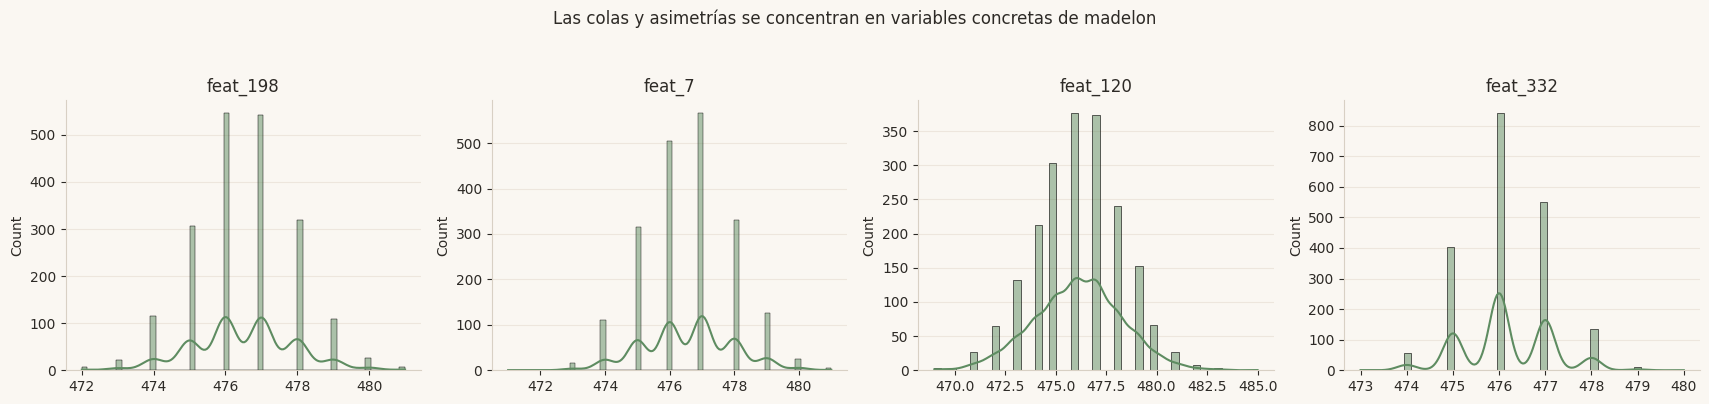

Figura guardada en formatos PNG y PDF.


In [48]:
distribuciones_madelon = resumir_distribuciones_dataset(
    "madelon",
    madelon,
    targets_esperados["madelon"],
)
variables_univariantes_madelon = seleccionar_variables_univariantes(distribuciones_madelon)

display(
    distribuciones_madelon
    .assign(skew_abs=lambda tabla: tabla["skewness"].abs())
    .sort_values(["outlier_rate_iqr", "skew_abs"], ascending=False)
    .head(10)
    .style.format({
        "skewness": "{:.3f}",
        "kurtosis": "{:.3f}",
        "outlier_rate_iqr": "{:.2%}",
        "missing_pct": "{:.2%}",
    })
)

figura = graficar_distribuciones_univariantes(
    "madelon",
    muestras_visuales["madelon"],
    variables_univariantes_madelon,
)
ruta_figura = guardar_figura(figura, "01_06_univariante_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Aunque hay 500 variables, las tasas medias de outliers son bajas. La revisión por ranking evita inspeccionar manualmente todas las columnas.


### Univariante Numérico: `olive_oil`


,dataset,variable,media,desviacion,minimo,mediana,maximo,skewness,kurtosis,outlier rate iqr,missing pct,skew abs
8,Olive Oil,eicosenoic,58.097902,22.030250,0,61.000000,105,-0.983734,0.990720,0.089161,0.000000,0.983734
7,Olive Oil,arachidic,31.888112,12.968697,0,33.000000,74,-0.551432,0.492244,0.055944,0.000000,0.551432
4,Olive Oil,oleic,228.865385,36.744935,152,223.000000,375,0.989940,1.554099,0.029720,0.000000,0.989940
2,Olive Oil,palmitoleic,1231.741259,168.592264,610,1201.000000,1753,0.344071,-0.177453,0.001748,0.000000,0.344071
no,Olive Oil,Area,1.699301,0.859968,1,1.000000,3,0.620348,-1.364713,0.000000,0.000000,0.620348
sí,Olive Oil,palmitic,4.599650,2.356687,1,3.000000,9,0.550053,-0.967392,0.000000,0.000000,0.550053
3,Olive Oil,stearic,126.094406,52.494365,15,110.000000,280,0.456436,-0.573213,0.000000,0.000000,0.456436
9,Olive Oil,other,16.281469,14.083295,1,17.000000,58,0.342025,-1.149955,0.000000,0.000000,0.342025
6,Olive Oil,linolenic,980.527972,242.799221,448,1030.000000,1470,-0.209806,-1.197007,0.000000,0.000000,0.209806
5,Olive Oil,linoleic,7311.748252,405.810222,6300,7302.500000,8410,0.076664,-0.880738,0.000000,0.000000,0.076664


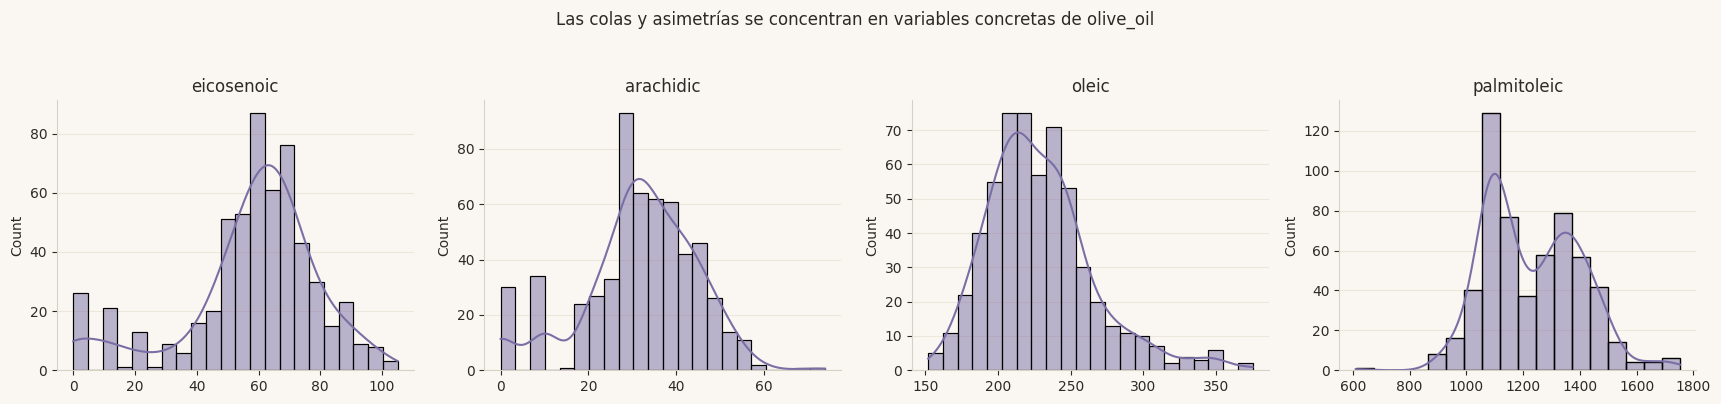

Figura guardada en formatos PNG y PDF.


In [49]:
distribuciones_olive_oil = resumir_distribuciones_dataset(
    "olive_oil",
    olive_oil,
    targets_esperados["olive_oil"],
)
variables_univariantes_olive_oil = seleccionar_variables_univariantes(distribuciones_olive_oil)

display(
    distribuciones_olive_oil
    .assign(skew_abs=lambda tabla: tabla["skewness"].abs())
    .sort_values(["outlier_rate_iqr", "skew_abs"], ascending=False)
    .head(10)
    .style.format({
        "skewness": "{:.3f}",
        "kurtosis": "{:.3f}",
        "outlier_rate_iqr": "{:.2%}",
        "missing_pct": "{:.2%}",
    })
)

figura = graficar_distribuciones_univariantes(
    "olive_oil",
    muestras_visuales["olive_oil"],
    variables_univariantes_olive_oil,
)
ruta_figura = guardar_figura(figura, "01_06_univariante_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 10 variables numéricas presentan asimetría absoluta media 0,512 y outlier rate máximo 8,92%. Se conserva la lectura como diagnóstico previo al preprocesado.


In [50]:
distribuciones_numericas = pd.concat([
    distribuciones_breast_cancer_wisconsin,
    distribuciones_customer_churn,
    distribuciones_madelon,
    distribuciones_olive_oil,
], ignore_index=True)

resumen_univariante_dataset = (
    distribuciones_numericas
    .groupby("dataset")
    .agg(
        variables_numericas=("variable", "count"),
        outlier_rate_media=("outlier_rate_iqr", "mean"),
        outlier_rate_maxima=("outlier_rate_iqr", "max"),
        skew_abs_media=("skewness", lambda serie: serie.abs().mean()),
        skew_abs_maxima=("skewness", lambda serie: serie.abs().max()),
    )
    .reset_index()
)

guardar_tabla(distribuciones_numericas, "fase1_distribuciones_numericas.csv")
guardar_tabla(resumen_univariante_dataset, "fase1_univariante_resumen_dataset.csv")
display(resumen_univariante_dataset.style.format({
    "outlier_rate_media": "{:.2%}",
    "outlier_rate_maxima": "{:.2%}",
    "skew_abs_media": "{:.3f}",
    "skew_abs_maxima": "{:.3f}",
}))


,dataset,variables numericas,outlier rate media,outlier rate maxima,skew abs media,skew abs maxima
no,Breast Cancer Wisconsin,30,0.035618,0.114236,1.740407,5.447186
sí,Customer Churn,7,0.000000,0.000000,0.262151,0.666809
2,Madelon,500,0.008959,0.143000,0.055762,0.180188
3,Olive Oil,10,0.017657,0.089161,0.512451,0.989940


El cierre univariante compara 547 variables numéricas en total. `madelon` aporta 500 variables y tiene outlier rate medio 0,90%, pero su máximo llega a 14,30%; `breast_cancer_wisconsin` concentra más asimetría, con skew absoluto medio 1,740 y máximo 5,447; `customer_churn` no muestra outliers IQR en sus 7 numéricas; y `olive_oil` queda en un punto intermedio con outlier rate máximo 8,92%. La siguiente sección comprueba si esas formas de distribución justifican abandonar supuestos paramétricos.


## 1.7 Normalidad Exploratoria

La normalidad se revisa como diagnóstico. El criterio técnico usa D'Agostino K² para variables con al menos 20 observaciones y Shapiro-Wilk para muestras menores; el resultado se acompaña con Q-Q plots de variables seleccionadas por menor p-valor para leer desviaciones de forma, no para imponer gaussianidad.


In [51]:
ALFA_NORMALIDAD = 0.05


In [52]:
def elegir_test_normalidad(serie):
    return "shapiro_wilk" if len(serie.dropna()) < 20 else "dagostino_k2"


def ejecutar_test_normalidad(serie):
    serie_limpia = serie.dropna()
    if len(serie_limpia) < 8:
        return np.nan, np.nan, "muestra_insuficiente"
    if elegir_test_normalidad(serie_limpia) == "shapiro_wilk":
        estadistico, p_valor = stats.shapiro(serie_limpia)
        return estadistico, p_valor, "shapiro_wilk"
    estadistico, p_valor = stats.normaltest(serie_limpia)
    return estadistico, p_valor, "dagostino_k2"


def resumir_normalidad_variable(nombre_dataset, variable, serie):
    estadistico, p_valor, test = ejecutar_test_normalidad(serie)
    return {
        "dataset": nombre_dataset,
        "variable": variable,
        "test": test,
        "estadistico": estadistico,
        "p_valor": p_valor,
        "rechaza_normalidad": bool(pd.notna(p_valor) and p_valor < ALFA_NORMALIDAD),
        "n_usado": int(serie.dropna().shape[0]),
    }


In [53]:
def resumir_normalidad_dataset(nombre_dataset, datos_visual, target):
    columnas_numericas = obtener_columnas_numericas_predictoras(datos_visual, target)
    return pd.DataFrame([
        resumir_normalidad_variable(nombre_dataset, variable, datos_visual[variable])
        for variable in columnas_numericas
    ])


def seleccionar_variables_qq(normalidad_dataset, max_variables=3):
    return normalidad_dataset.sort_values("p_valor").head(max_variables)["variable"].tolist()


def graficar_qq_dataset(nombre_dataset, datos_visual, variables_qq):
    figura, ejes = plt.subplots(1, len(variables_qq), figsize=(4.5 * len(variables_qq), 4))
    ejes = np.atleast_1d(ejes)
    for eje, variable in zip(ejes, variables_qq):
        stats.probplot(datos_visual[variable].dropna(), dist="norm", plot=eje)
        eje.get_lines()[0].set_markerfacecolor(PALETA_DATASETS[nombre_dataset])
        eje.get_lines()[0].set_markeredgecolor(PALETA_DATASETS[nombre_dataset])
        eje.get_lines()[0].set_markersize(3)
        eje.get_lines()[1].set_color("#2D2A26")
        eje.set_title(f"{variable}: desviación frente a normal")
        eje.grid(alpha=0.55)
    figura.suptitle(f"Los Q-Q plots muestran por qué la normalidad es solo un diagnóstico en {nombre_dataset}", y=1.05)
    figura.tight_layout()
    return figura


### Normalidad: `breast_cancer_wisconsin`


,dataset,variables testadas,pct rechaza normalidad,n minimo usado,n maximo usado
no,Breast Cancer Wisconsin,30,1.000000,569,569


,dataset,variable,test,estadistico,p-valor,rechaza normalidad,n usado
13,Breast Cancer Wisconsin,area_se,D'Agostino K²,658.800107,0.000000,sí,569
16,Breast Cancer Wisconsin,concavity_se,D'Agostino K²,636.766902,0.000000,sí,569
19,Breast Cancer Wisconsin,fractal_dimension_se,D'Agostino K²,515.175484,0.000000,sí,569
12,Breast Cancer Wisconsin,perimeter_se,D'Agostino K²,464.421682,0.000000,sí,569
10,Breast Cancer Wisconsin,radius_se,D'Agostino K²,422.614660,0.000000,sí,569
14,Breast Cancer Wisconsin,smoothness_se,D'Agostino K²,318.867791,0.000000,sí,569
18,Breast Cancer Wisconsin,symmetry_se,D'Agostino K²,289.729289,0.000000,sí,569
15,Breast Cancer Wisconsin,compactness_se,D'Agostino K²,235.282510,0.000000,sí,569
23,Breast Cancer Wisconsin,area_worst,D'Agostino K²,222.965049,0.000000,sí,569
29,Breast Cancer Wisconsin,fractal_dimension_worst,D'Agostino K²,212.084252,0.000000,sí,569


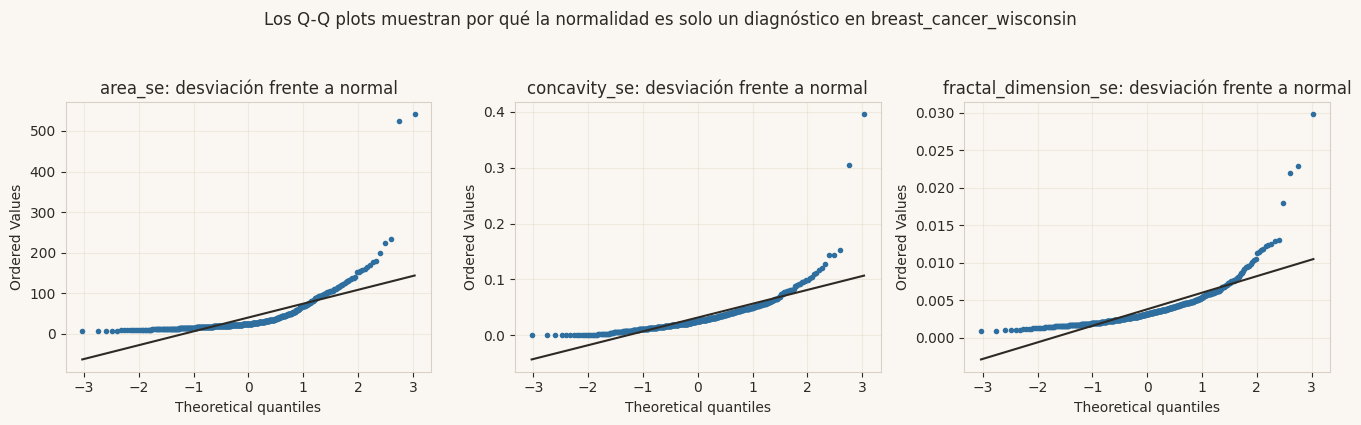

Figura guardada en formatos PNG y PDF.


In [54]:
normalidad_breast_cancer_wisconsin = resumir_normalidad_dataset(
    "breast_cancer_wisconsin",
    muestras_visuales["breast_cancer_wisconsin"],
    targets_esperados["breast_cancer_wisconsin"],
)
variables_qq_breast_cancer_wisconsin = seleccionar_variables_qq(normalidad_breast_cancer_wisconsin)
resumen_normalidad_breast_cancer_wisconsin = pd.DataFrame([{
    "dataset": "breast_cancer_wisconsin",
    "variables_testadas": len(normalidad_breast_cancer_wisconsin),
    "pct_rechaza_normalidad": normalidad_breast_cancer_wisconsin["rechaza_normalidad"].mean(),
    "n_minimo_usado": normalidad_breast_cancer_wisconsin["n_usado"].min(),
    "n_maximo_usado": normalidad_breast_cancer_wisconsin["n_usado"].max(),
}])

display(resumen_normalidad_breast_cancer_wisconsin.style.format({"pct_rechaza_normalidad": "{:.1%}"}))
display(normalidad_breast_cancer_wisconsin.sort_values("p_valor").head(10).style.format({
    "estadistico": "{:.3f}",
    "p_valor": "{:.2e}",
}))

figura = graficar_qq_dataset("breast_cancer_wisconsin", muestras_visuales["breast_cancer_wisconsin"], variables_qq_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_07_normalidad_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 30 variables testadas rechazan normalidad al 100,0%, y las seleccionadas muestran desviaciones claras respecto a la recta normal coherentes con las asimetrías de 1.6.


### Normalidad: `customer_churn`


,dataset,variables testadas,pct rechaza normalidad,n minimo usado,n maximo usado
no,Customer Churn,7,1.000000,5000,5000


,dataset,variable,test,estadistico,p-valor,rechaza normalidad,n usado
sí,Customer Churn,Tenure,D'Agostino K²,3343.361663,0.000000,sí,5000
2,Customer Churn,Usage Frequency,D'Agostino K²,3763.743270,0.000000,sí,5000
6,Customer Churn,Last Interaction,D'Agostino K²,2603.245873,0.000000,sí,5000
3,Customer Churn,Support Calls,D'Agostino K²,687.294152,0.000000,sí,5000
4,Customer Churn,Payment Delay,D'Agostino K²,682.450026,0.000000,sí,5000
no,Customer Churn,Age,D'Agostino K²,581.234370,0.000000,sí,5000
5,Customer Churn,Total Spend,D'Agostino K²,576.895825,0.000000,sí,5000


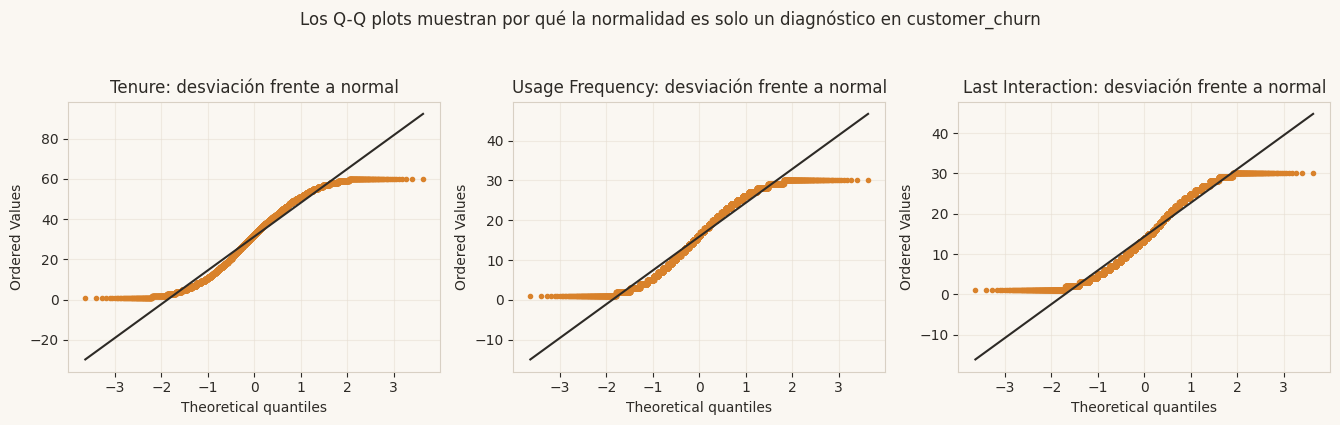

Figura guardada en formatos PNG y PDF.


In [55]:
normalidad_customer_churn = resumir_normalidad_dataset(
    "customer_churn",
    muestras_visuales["customer_churn"],
    targets_esperados["customer_churn"],
)
variables_qq_customer_churn = seleccionar_variables_qq(normalidad_customer_churn)
resumen_normalidad_customer_churn = pd.DataFrame([{
    "dataset": "customer_churn",
    "variables_testadas": len(normalidad_customer_churn),
    "pct_rechaza_normalidad": normalidad_customer_churn["rechaza_normalidad"].mean(),
    "n_minimo_usado": normalidad_customer_churn["n_usado"].min(),
    "n_maximo_usado": normalidad_customer_churn["n_usado"].max(),
}])

display(resumen_normalidad_customer_churn.style.format({"pct_rechaza_normalidad": "{:.1%}"}))
display(normalidad_customer_churn.sort_values("p_valor").head(10).style.format({
    "estadistico": "{:.3f}",
    "p_valor": "{:.2e}",
}))

figura = graficar_qq_dataset("customer_churn", muestras_visuales["customer_churn"], variables_qq_customer_churn)
ruta_figura = guardar_figura(figura, "01_07_normalidad_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


El rechazo de normalidad alcanza el 100,0%, pero debe leerse con prudencia: varias variables son discretas y la muestra visual sigue teniendo 5.000 filas.


### Normalidad: `madelon`


,dataset,variables testadas,pct rechaza normalidad,n minimo usado,n maximo usado
no,Madelon,500,0.228000,2000,2000


,dataset,variable,test,estadistico,p-valor,rechaza normalidad,n usado
153,Madelon,feat_153,D'Agostino K²,371.973541,0.000000,sí,2000
455,Madelon,feat_455,D'Agostino K²,349.482524,0.000000,sí,2000
318,Madelon,feat_318,D'Agostino K²,341.144987,0.000000,sí,2000
378,Madelon,feat_378,D'Agostino K²,331.080670,0.000000,sí,2000
433,Madelon,feat_433,D'Agostino K²,326.530626,0.000000,sí,2000
475,Madelon,feat_475,D'Agostino K²,311.689424,0.000000,sí,2000
241,Madelon,feat_241,D'Agostino K²,296.953690,0.000000,sí,2000
281,Madelon,feat_281,D'Agostino K²,294.528175,0.000000,sí,2000
28,Madelon,feat_28,D'Agostino K²,271.417657,0.000000,sí,2000
451,Madelon,feat_451,D'Agostino K²,241.076692,0.000000,sí,2000


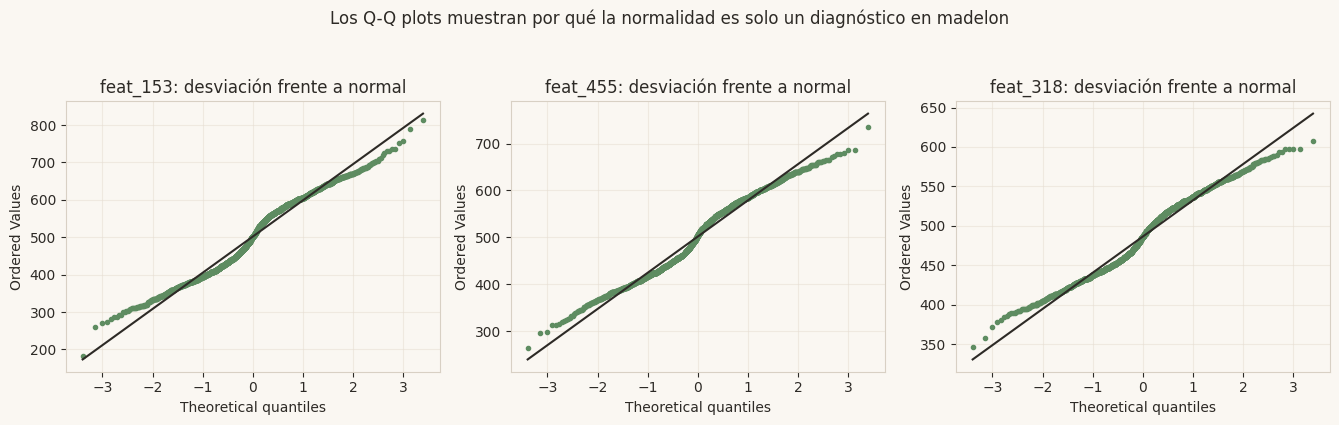

Figura guardada en formatos PNG y PDF.


In [56]:
normalidad_madelon = resumir_normalidad_dataset(
    "madelon",
    muestras_visuales["madelon"],
    targets_esperados["madelon"],
)
variables_qq_madelon = seleccionar_variables_qq(normalidad_madelon)
resumen_normalidad_madelon = pd.DataFrame([{
    "dataset": "madelon",
    "variables_testadas": len(normalidad_madelon),
    "pct_rechaza_normalidad": normalidad_madelon["rechaza_normalidad"].mean(),
    "n_minimo_usado": normalidad_madelon["n_usado"].min(),
    "n_maximo_usado": normalidad_madelon["n_usado"].max(),
}])

display(resumen_normalidad_madelon.style.format({"pct_rechaza_normalidad": "{:.1%}"}))
display(normalidad_madelon.sort_values("p_valor").head(10).style.format({
    "estadistico": "{:.3f}",
    "p_valor": "{:.2e}",
}))

figura = graficar_qq_dataset("madelon", muestras_visuales["madelon"], variables_qq_madelon)
ruta_figura = guardar_figura(figura, "01_07_normalidad_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Solo el 22,8% de las 500 variables rechaza normalidad. Aun así, el diagnóstico principal de `madelon` sigue siendo la dimensionalidad.


### Normalidad: `olive_oil`


,dataset,variables testadas,pct rechaza normalidad,n minimo usado,n maximo usado
no,Olive Oil,10,1.000000,572,572


,dataset,variable,test,estadistico,p-valor,rechaza normalidad,n usado
no,Olive Oil,Area,D'Agostino K²,3251.988661,0.000000,sí,572
6,Olive Oil,linolenic,D'Agostino K²,370.990858,0.000000,sí,572
9,Olive Oil,other,D'Agostino K²,278.528248,0.000000,sí,572
sí,Olive Oil,palmitic,D'Agostino K²,125.791895,0.000000,sí,572
4,Olive Oil,oleic,D'Agostino K²,90.687910,0.000000,sí,572
8,Olive Oil,eicosenoic,D'Agostino K²,80.325435,0.000000,sí,572
5,Olive Oil,linoleic,D'Agostino K²,66.802189,0.000000,sí,572
3,Olive Oil,stearic,D'Agostino K²,33.899571,0.000000,sí,572
7,Olive Oil,arachidic,D'Agostino K²,30.427054,0.000000,sí,572
2,Olive Oil,palmitoleic,D'Agostino K²,11.670747,0.002922,sí,572


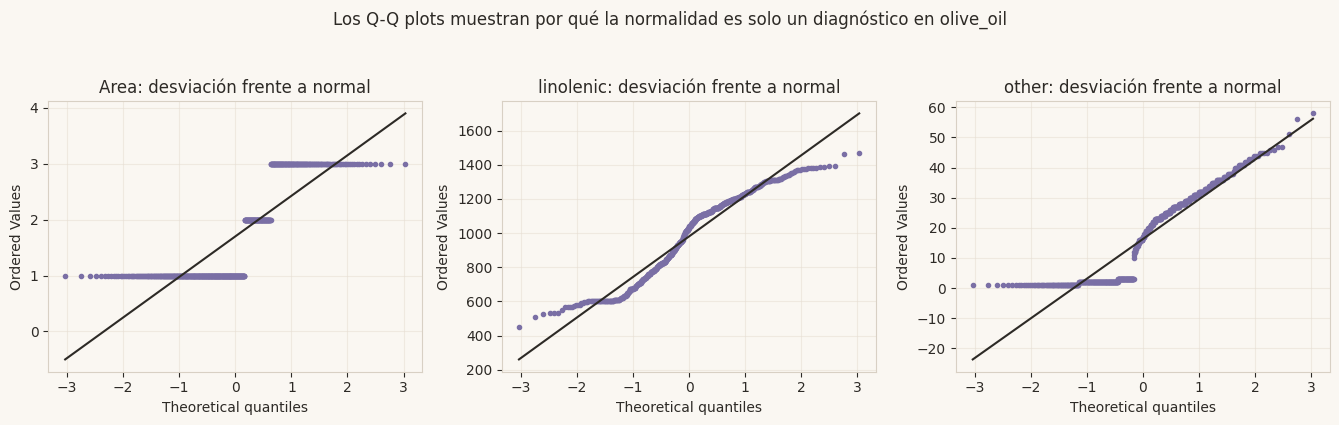

Figura guardada en formatos PNG y PDF.


In [57]:
normalidad_olive_oil = resumir_normalidad_dataset(
    "olive_oil",
    muestras_visuales["olive_oil"],
    targets_esperados["olive_oil"],
)
variables_qq_olive_oil = seleccionar_variables_qq(normalidad_olive_oil)
resumen_normalidad_olive_oil = pd.DataFrame([{
    "dataset": "olive_oil",
    "variables_testadas": len(normalidad_olive_oil),
    "pct_rechaza_normalidad": normalidad_olive_oil["rechaza_normalidad"].mean(),
    "n_minimo_usado": normalidad_olive_oil["n_usado"].min(),
    "n_maximo_usado": normalidad_olive_oil["n_usado"].max(),
}])

display(resumen_normalidad_olive_oil.style.format({"pct_rechaza_normalidad": "{:.1%}"}))
display(normalidad_olive_oil.sort_values("p_valor").head(10).style.format({
    "estadistico": "{:.3f}",
    "p_valor": "{:.2e}",
}))

figura = graficar_qq_dataset("olive_oil", muestras_visuales["olive_oil"], variables_qq_olive_oil)
ruta_figura = guardar_figura(figura, "01_07_normalidad_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 10 variables testadas rechazan normalidad al 100,0% y muestran patrones discretos o desviaciones visuales. Esto respalda el uso de pruebas no paramétricas en asociación.


In [58]:
normalidad_variables = pd.concat([
    normalidad_breast_cancer_wisconsin,
    normalidad_customer_churn,
    normalidad_madelon,
    normalidad_olive_oil,
], ignore_index=True)
normalidad_resumen = pd.concat([
    resumen_normalidad_breast_cancer_wisconsin,
    resumen_normalidad_customer_churn,
    resumen_normalidad_madelon,
    resumen_normalidad_olive_oil,
], ignore_index=True)

guardar_tabla(normalidad_variables, "fase1_normalidad_variables.csv")
guardar_tabla(normalidad_resumen, "fase1_normalidad_resumen.csv")
display(normalidad_resumen.style.format({"pct_rechaza_normalidad": "{:.1%}"}))


,dataset,variables testadas,pct rechaza normalidad,n minimo usado,n maximo usado
no,Breast Cancer Wisconsin,30,1.000000,569,569
sí,Customer Churn,7,1.000000,5000,5000
2,Madelon,500,0.228000,2000,2000
3,Olive Oil,10,1.000000,572,572


El resumen de normalidad muestra rechazo en el 100,0% de las variables de `breast_cancer_wisconsin`, `customer_churn` y `olive_oil`, mientras que `madelon` rechaza en el 22,8% de sus 500 variables. La muestra usada va de 569 filas en `breast_cancer_wisconsin` a 5.000 filas visuales en `customer_churn`, por lo que la lectura práctica es clara: las asociaciones de la sección siguiente deben apoyarse en pruebas no paramétricas y no en normalidad gaussiana.


## 1.8 Asociación Exploratoria Variable-Target

La asociación se calcula con pruebas distintas según el tipo de variable y target. Las funciones se introducen por bloques para que el lector vea qué se aplica y por qué. Esta sección es el precursor clásico del término de relevancia del método QFS: en el paper, la relevancia de cada variable se expresa como información mutua `I(x_i; y)` y se codifica en detunings locales dentro del objetivo `Q(x; alpha)`. Aquí todavía no se estima esa MI final, pero sí se identifica qué variables muestran relación univariante con el target y cómo debe leerse esa señal antes de selección.


In [59]:
ALFA_ASOCIACION = 0.05


### Mann-Whitney U y Delta de Cliff

Se usan para variables numéricas frente a target binario. Mann-Whitney evalúa diferencias de distribución entre dos grupos y delta de Cliff resume la magnitud de la separación.


In [60]:
def separar_grupos_por_target(datos_dataset, variable, target):
    clases = list(pd.Series(datos_dataset[target]).dropna().unique())
    return [datos_dataset.loc[datos_dataset[target] == clase, variable].dropna() for clase in clases]


def calcular_delta_cliff_desde_u(estadistico_u, grupo_a, grupo_b):
    return (2 * estadistico_u / (len(grupo_a) * len(grupo_b))) - 1


def contrastar_numerica_binaria(datos_dataset, variable, target):
    grupo_a, grupo_b = separar_grupos_por_target(datos_dataset, variable, target)
    estadistico_u, p_valor = stats.mannwhitneyu(grupo_a, grupo_b, alternative="two-sided")
    efecto = calcular_delta_cliff_desde_u(estadistico_u, grupo_a, grupo_b)
    return "mann_whitney_u", estadistico_u, p_valor, "cliffs_delta", efecto


### Kruskal-Wallis y Epsilon Cuadrado

Se usan para variables numéricas frente a targets con más de dos clases. Kruskal-Wallis compara grupos sin asumir normalidad y epsilon cuadrado aproxima magnitud de efecto.


In [61]:
def calcular_epsilon_cuadrado(estadistico_h, numero_observaciones, numero_grupos):
    if numero_observaciones <= numero_grupos:
        return np.nan
    return (estadistico_h - numero_grupos + 1) / (numero_observaciones - numero_grupos)


def contrastar_numerica_multiclase(datos_dataset, variable, target):
    grupos = separar_grupos_por_target(datos_dataset, variable, target)
    estadistico_h, p_valor = stats.kruskal(*grupos)
    numero_observaciones = sum(len(grupo) for grupo in grupos)
    efecto = calcular_epsilon_cuadrado(estadistico_h, numero_observaciones, len(grupos))
    return "kruskal_wallis", estadistico_h, p_valor, "epsilon_squared", efecto


### Chi-Cuadrado y V de Cramér

Se usan para variables categóricas frente al target. Chi-cuadrado contrasta independencia y V de Cramér resume la fuerza de asociación entre categorías.


In [62]:
def calcular_cramers_v(tabla_contingencia):
    chi2 = stats.chi2_contingency(tabla_contingencia, correction=False)[0]
    numero_observaciones = tabla_contingencia.to_numpy().sum()
    filas, columnas = tabla_contingencia.shape
    return np.sqrt((chi2 / numero_observaciones) / max(1, min(columnas - 1, filas - 1)))


def contrastar_categorica(datos_dataset, variable, target):
    tabla_contingencia = pd.crosstab(datos_dataset[variable], datos_dataset[target])
    estadistico, p_valor, _, _ = stats.chi2_contingency(tabla_contingencia)
    efecto = calcular_cramers_v(tabla_contingencia)
    return "chi2", estadistico, p_valor, "cramers_v", efecto


### Corrección FDR de Benjamini-Hochberg

FDR significa *False Discovery Rate*. La corrección de Benjamini-Hochberg reduce la sobreinterpretación de p-valores cuando se prueban muchas variables en el mismo dataset.


In [63]:
def corregir_p_valores_bh(p_valores):
    p_valores = np.asarray(p_valores, dtype=float)
    resultado = np.full(p_valores.shape, np.nan)
    mascara = ~np.isnan(p_valores)
    valores_validos = p_valores[mascara]
    if len(valores_validos) == 0:
        return resultado
    orden = np.argsort(valores_validos)
    valores_ordenados = valores_validos[orden]
    factores = len(valores_ordenados) / np.arange(1, len(valores_ordenados) + 1)
    ajustados = np.minimum.accumulate((valores_ordenados * factores)[::-1])[::-1]
    valores_ajustados = np.empty_like(ajustados)
    valores_ajustados[orden] = np.clip(ajustados, 0, 1)
    resultado[mascara] = valores_ajustados
    return resultado


In [64]:
def target_es_binario(datos_dataset, target):
    return datos_dataset[target].nunique(dropna=True) == 2


def contrastar_variable_con_target(datos_dataset, variable, target):
    if pd.api.types.is_numeric_dtype(datos_dataset[variable]):
        if target_es_binario(datos_dataset, target):
            return contrastar_numerica_binaria(datos_dataset, variable, target)
        return contrastar_numerica_multiclase(datos_dataset, variable, target)
    return contrastar_categorica(datos_dataset, variable, target)


def construir_fila_asociacion(nombre_dataset, datos_dataset, variable, target):
    test, estadistico, p_valor, nombre_efecto, efecto = contrastar_variable_con_target(datos_dataset, variable, target)
    return {
        "dataset": nombre_dataset,
        "variable": variable,
        "test": test,
        "estadistico": estadistico,
        "p_valor": p_valor,
        "nombre_tamano_efecto": nombre_efecto,
        "tamano_efecto": efecto,
    }


def aplicar_fdr_y_magnitud(asociaciones_dataset):
    asociaciones_dataset["p_valor_fdr"] = corregir_p_valores_bh(asociaciones_dataset["p_valor"].to_numpy())
    asociaciones_dataset["abs_tamano_efecto"] = asociaciones_dataset["tamano_efecto"].abs()
    return asociaciones_dataset


def calcular_asociaciones_dataset(nombre_dataset, datos_dataset, target):
    variables_excluidas = set(listar_posibles_identificadores(datos_dataset, target))
    variables_validas = [variable for variable in obtener_columnas_predictoras(datos_dataset, target) if variable not in variables_excluidas]
    asociaciones_dataset = pd.DataFrame([
        construir_fila_asociacion(nombre_dataset, datos_dataset, variable, target)
        for variable in variables_validas
    ])
    return aplicar_fdr_y_magnitud(asociaciones_dataset)


In [65]:
def preparar_top_significancia(asociaciones_dataset, max_variables=12):
    return asociaciones_dataset.nsmallest(max_variables, "p_valor_fdr").copy()


def calcular_menos_log10_fdr(asociaciones_dataset):
    return -np.log10(asociaciones_dataset["p_valor_fdr"].clip(lower=1e-300))


def graficar_top_significancia(nombre_dataset, asociaciones_dataset):
    datos_grafico = preparar_top_significancia(asociaciones_dataset)
    datos_grafico["menos_log10_fdr"] = calcular_menos_log10_fdr(datos_grafico).clip(upper=50)
    datos_grafico = datos_grafico.sort_values("menos_log10_fdr")
    figura, eje = plt.subplots(figsize=(9, max(4.2, 0.38 * len(datos_grafico) + 1.6)))
    eje.barh(datos_grafico["variable"], datos_grafico["menos_log10_fdr"], color=PALETA_DATASETS[nombre_dataset])
    eje.axvline(-np.log10(ALFA_ASOCIACION), color="#B85C5C", linestyle="--", linewidth=1)
    eje.set_title(f"La relevancia exploratoria se concentra en el top FDR de {nombre_dataset}")
    eje.set_xlabel("-log10(FDR), capado en 50")
    eje.set_ylabel("")
    aplicar_estilo_eje(eje)
    eje.text(-np.log10(ALFA_ASOCIACION) + 0.3, eje.get_ylim()[0] + 0.4, "FDR=0,05", color="#B85C5C", fontsize=9)
    figura.tight_layout()
    return figura


### Asociación Variable-Target: `breast_cancer_wisconsin`


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|
22,Breast Cancer Wisconsin,perimeter_worst,Mann-Whitney U,73826.000000,0.000000,delta de Cliff,0.950901,0.000000,0.950901
20,Breast Cancer Wisconsin,radius_worst,Mann-Whitney U,73447.000000,0.000000,delta de Cliff,0.940886,0.000000,0.940886
23,Breast Cancer Wisconsin,area_worst,Mann-Whitney U,73400.500000,0.000000,delta de Cliff,0.939657,0.000000,0.939657
27,Breast Cancer Wisconsin,concave_points_worst,Mann-Whitney U,73164.000000,0.000000,delta de Cliff,0.933407,0.000000,0.933407
7,Breast Cancer Wisconsin,concave_points_mean,Mann-Whitney U,72992.500000,0.000000,delta de Cliff,0.928875,0.000000,0.928875
2,Breast Cancer Wisconsin,perimeter_mean,Mann-Whitney U,71665.000000,0.000000,delta de Cliff,0.893795,0.000000,0.893795
3,Breast Cancer Wisconsin,area_mean,Mann-Whitney U,71015.500000,0.000000,delta de Cliff,0.876632,0.000000,0.876632
6,Breast Cancer Wisconsin,concavity_mean,Mann-Whitney U,70978.500000,0.000000,delta de Cliff,0.875654,0.000000,0.875654
no,Breast Cancer Wisconsin,radius_mean,Mann-Whitney U,70955.000000,0.000000,delta de Cliff,0.875033,0.000000,0.875033
13,Breast Cancer Wisconsin,area_se,Mann-Whitney U,70114.500000,0.000000,delta de Cliff,0.852822,0.000000,0.852822


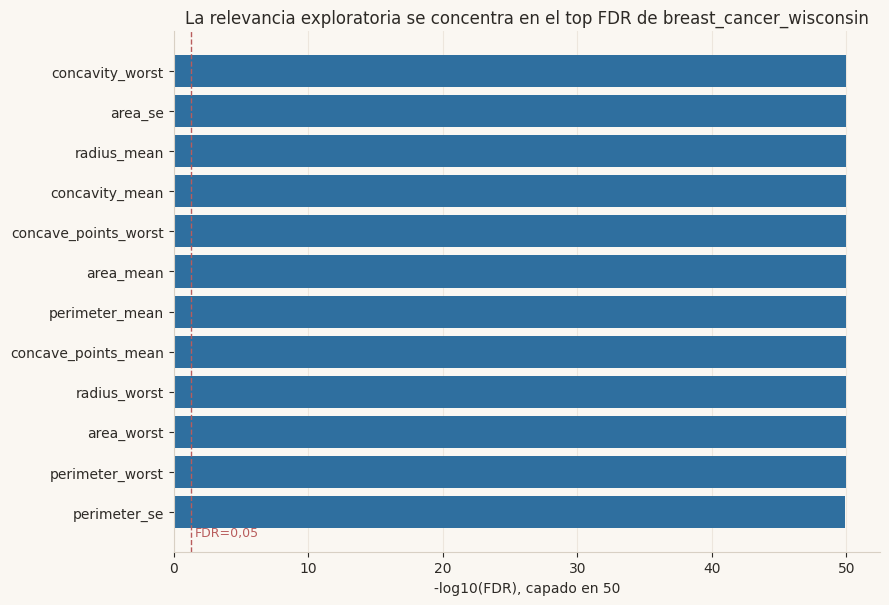

Figura guardada en formatos PNG y PDF.


In [66]:
asociacion_breast_cancer_wisconsin = calcular_asociaciones_dataset(
    "breast_cancer_wisconsin",
    breast_cancer_wisconsin,
    targets_esperados["breast_cancer_wisconsin"],
)

display(
    asociacion_breast_cancer_wisconsin
    .sort_values("p_valor_fdr", ascending=True)
    .head(12)
    .style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    })
)

figura = graficar_top_significancia("breast_cancer_wisconsin", asociacion_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_08_asociacion_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La asociación univariante es fuerte: 27 de 30 variables quedan con FDR < 0,05. La lectura sigue siendo exploratoria porque muchas variables pueden estar correlacionadas entre sí.


### Asociación Variable-Target: `customer_churn`


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|
no,Customer Churn,Age,Mann-Whitney U,29304915508.000000,0.000000,delta de Cliff,0.228510,0.000000,0.228510
sí,Customer Churn,Gender,chi-cuadrado,13560.734708,0.000000,V de Cramér,0.175395,0.000000,0.175395
5,Customer Churn,Payment Delay,Mann-Whitney U,31872281150.500000,0.000000,delta de Cliff,0.336138,0.000000,0.336138
4,Customer Churn,Support Calls,Mann-Whitney U,39259899207.000000,0.000000,delta de Cliff,0.645839,0.000000,0.645839
7,Customer Churn,Contract Length,chi-cuadrado,82862.391130,0.000000,V de Cramér,0.433553,0.000000,0.433553
8,Customer Churn,Total Spend,Mann-Whitney U,12774676064.500000,0.000000,delta de Cliff,-0.464465,0.000000,0.464465
9,Customer Churn,Last Interaction,Mann-Whitney U,27981396034.500000,0.000000,delta de Cliff,0.173026,0.000000,0.173026
2,Customer Churn,Tenure,Mann-Whitney U,22418651134.500000,0.000000,delta de Cliff,-0.060173,0.000000,0.060173
3,Customer Churn,Usage Frequency,Mann-Whitney U,22585031832.000000,0.000000,delta de Cliff,-0.053198,0.000000,0.053198
6,Customer Churn,Subscription Type,chi-cuadrado,186.225147,0.000000,V de Cramér,0.020553,0.000000,0.020553


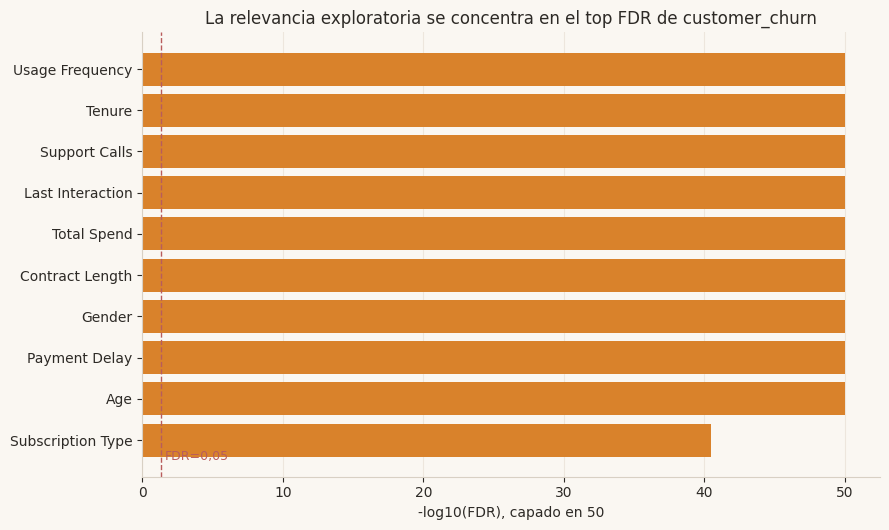

Figura guardada en formatos PNG y PDF.


In [67]:
asociacion_customer_churn = calcular_asociaciones_dataset(
    "customer_churn",
    customer_churn,
    targets_esperados["customer_churn"],
)

display(
    asociacion_customer_churn
    .sort_values("p_valor_fdr", ascending=True)
    .head(12)
    .style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    })
)

figura = graficar_top_significancia("customer_churn", asociacion_customer_churn)
ruta_figura = guardar_figura(figura, "01_08_asociacion_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 10 variables contrastadas son significativas tras FDR, pero el tamaño muestral de 440.832 filas exige mirar también la magnitud del efecto.


### Asociación Variable-Target: `madelon`


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|
241,Madelon,feat_241,Mann-Whitney U,368952.000000,0.000000,delta de Cliff,-0.262096,0.000000,0.262096
475,Madelon,feat_475,Mann-Whitney U,369731.500000,0.000000,delta de Cliff,-0.260537,0.000000,0.260537
336,Madelon,feat_336,Mann-Whitney U,597746.500000,0.000000,delta de Cliff,0.195493,0.000000,0.195493
64,Madelon,feat_64,Mann-Whitney U,595609.500000,0.000000,delta de Cliff,0.191219,0.000000,0.191219
338,Madelon,feat_338,Mann-Whitney U,581902.500000,0.000000,delta de Cliff,0.163805,0.000000,0.163805
128,Madelon,feat_128,Mann-Whitney U,422537.000000,0.000000,delta de Cliff,-0.154926,0.000000,0.154926
105,Madelon,feat_105,Mann-Whitney U,423942.500000,0.000000,delta de Cliff,-0.152115,0.000000,0.152115
48,Madelon,feat_48,Mann-Whitney U,431277.500000,0.000000,delta de Cliff,-0.137445,0.000006,0.137445
378,Madelon,feat_378,Mann-Whitney U,433348.500000,0.000000,delta de Cliff,-0.133303,0.000014,0.133303
442,Madelon,feat_442,Mann-Whitney U,562215.500000,0.000001,delta de Cliff,0.124431,0.000073,0.124431


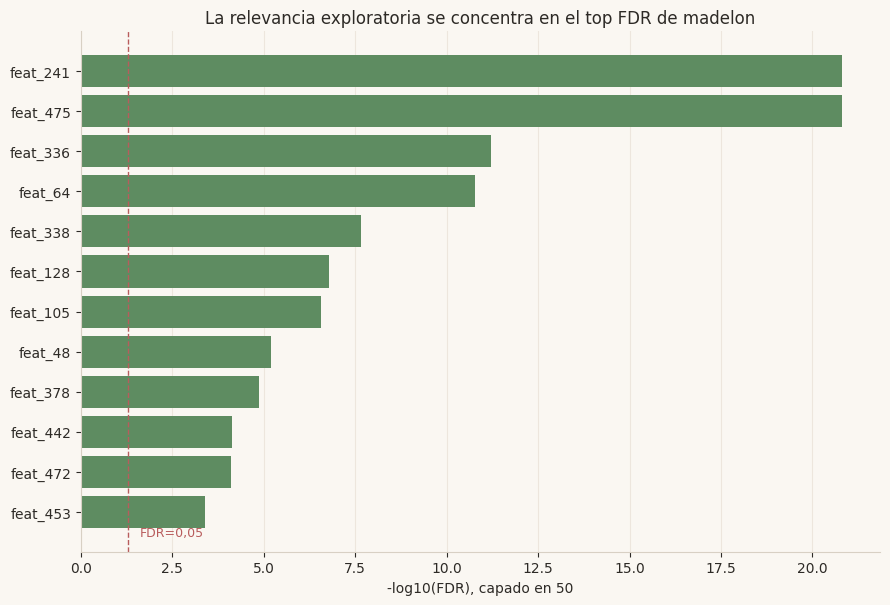

Figura guardada en formatos PNG y PDF.


In [68]:
asociacion_madelon = calcular_asociaciones_dataset(
    "madelon",
    madelon,
    targets_esperados["madelon"],
)

display(
    asociacion_madelon
    .sort_values("p_valor_fdr", ascending=True)
    .head(12)
    .style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    })
)

figura = graficar_top_significancia("madelon", asociacion_madelon)
ruta_figura = guardar_figura(figura, "01_08_asociacion_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Aparecen señales univariantes, pero son escasas frente a 500 variables. Esta sección ya anticipa que la selección de características será crítica.


### Asociación Variable-Target: `olive_oil`


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|
no,Olive Oil,Area,Kruskal-Wallis,571.000000,0.000000,epsilon cuadrado,1.000000,0.000000,1.000000
sí,Olive Oil,palmitic,Kruskal-Wallis,571.000000,0.000000,epsilon cuadrado,1.000000,0.000000,1.000000
5,Olive Oil,linoleic,Kruskal-Wallis,481.174501,0.000000,epsilon cuadrado,0.840452,0.000000,0.840452
6,Olive Oil,linolenic,Kruskal-Wallis,474.092879,0.000000,epsilon cuadrado,0.827874,0.000000,0.827874
9,Olive Oil,other,Kruskal-Wallis,457.816486,0.000000,epsilon cuadrado,0.798964,0.000000,0.798964
3,Olive Oil,stearic,Kruskal-Wallis,455.869063,0.000000,epsilon cuadrado,0.795505,0.000000,0.795505
2,Olive Oil,palmitoleic,Kruskal-Wallis,428.899715,0.000000,epsilon cuadrado,0.747602,0.000000,0.747602
7,Olive Oil,arachidic,Kruskal-Wallis,314.711014,0.000000,epsilon cuadrado,0.544780,0.000000,0.544780
8,Olive Oil,eicosenoic,Kruskal-Wallis,288.185929,0.000000,epsilon cuadrado,0.497666,0.000000,0.497666
4,Olive Oil,oleic,Kruskal-Wallis,262.347256,0.000000,epsilon cuadrado,0.451771,0.000000,0.451771


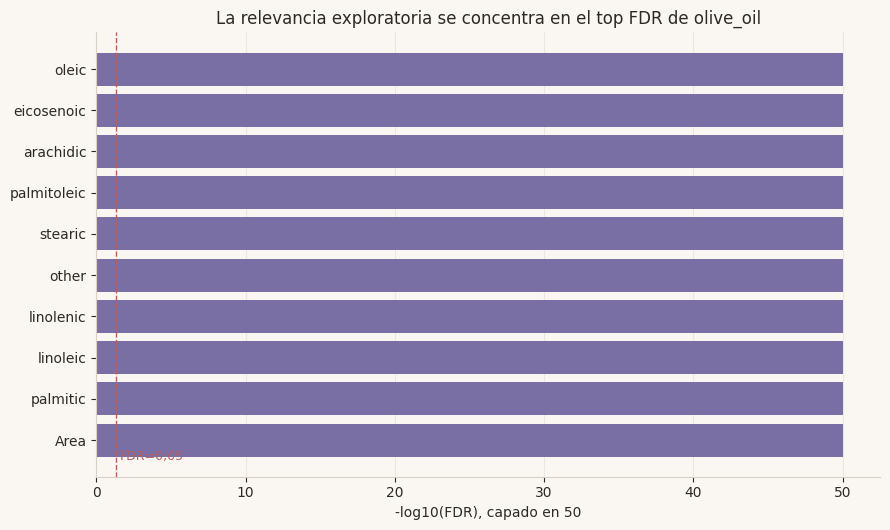

Figura guardada en formatos PNG y PDF.


In [69]:
asociacion_olive_oil = calcular_asociaciones_dataset(
    "olive_oil",
    olive_oil,
    targets_esperados["olive_oil"],
)

display(
    asociacion_olive_oil
    .sort_values("p_valor_fdr", ascending=True)
    .head(12)
    .style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    })
)

figura = graficar_top_significancia("olive_oil", asociacion_olive_oil)
ruta_figura = guardar_figura(figura, "01_08_asociacion_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Las 10 variables numéricas muestran asociación fuerte con el target de 9 clases. Algunas señales pueden actuar como proxies de región y se revisan en la sección de cautelas.


In [70]:
asociacion_target = pd.concat([
    asociacion_breast_cancer_wisconsin,
    asociacion_customer_churn,
    asociacion_madelon,
    asociacion_olive_oil,
], ignore_index=True)
resumen_asociacion_target = (
    asociacion_target
    .groupby("dataset")
    .agg(
        variables_contrastadas=("variable", "count"),
        variables_fdr_005=("p_valor_fdr", lambda serie: int((serie < ALFA_ASOCIACION).sum())),
        efecto_abs_mediano=("abs_tamano_efecto", "median"),
        efecto_abs_maximo=("abs_tamano_efecto", "max"),
    )
    .reset_index()
)
guardar_tabla(asociacion_target, "fase1_asociacion_target.csv")
guardar_tabla(resumen_asociacion_target, "fase1_asociacion_target_resumen.csv")
display(resumen_asociacion_target.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))


,dataset,variables contrastadas,variables fdr 005,|efecto| mediano,|efecto| máximo
no,Breast Cancer Wisconsin,30,27,0.654095,0.950901
sí,Customer Churn,10,10,0.201952,0.645839
2,Madelon,500,13,0.019452,0.262096
3,Olive Oil,10,10,0.797234,1.000000


La vista conjunta separa cantidad de señal y magnitud. `breast_cancer_wisconsin` conserva 27 de 30 variables con FDR < 0,05 y efecto máximo 0,9509; `customer_churn` marca 10 de 10, aunque su efecto mediano mezcla numéricas y categóricas; `madelon` solo mantiene 13 de 500 pese a contrastar muchas variables; y `olive_oil` conserva 10 de 10 con efecto máximo 1,0000. Esta tabla deja preparada la lectura de FDR y magnitud sin convertir todavía la asociación en selección final.


## 1.9 Significancia Corregida Por Múltiples Contrastes

Se revisa, dataset por dataset, cuántas variables son significativas antes y después de FDR. La técnica aplicada es Benjamini-Hochberg con alfa 0,05, y el objetivo es detectar señales que podrían ser falsos positivos exploratorios.


In [71]:
ALFA_FDR = 0.05


def resumir_fdr_dataset(asociaciones_dataset):
    return pd.DataFrame([{
        "dataset": asociaciones_dataset["dataset"].iloc[0],
        "variables_contrastadas": len(asociaciones_dataset),
        "significativas_sin_corregir": int((asociaciones_dataset["p_valor"] < ALFA_FDR).sum()),
        "significativas_fdr": int((asociaciones_dataset["p_valor_fdr"] < ALFA_FDR).sum()),
    }]).assign(
        reduccion_por_correccion=lambda tabla: tabla["significativas_sin_corregir"] - tabla["significativas_fdr"]
    )


def seleccionar_variables_perdidas_por_fdr(asociaciones_dataset):
    mascara = (asociaciones_dataset["p_valor"] < ALFA_FDR) & (asociaciones_dataset["p_valor_fdr"] >= ALFA_FDR)
    return asociaciones_dataset[mascara].sort_values("p_valor")


### FDR: `breast_cancer_wisconsin`


In [72]:
fdr_breast_cancer_wisconsin = resumir_fdr_dataset(asociacion_breast_cancer_wisconsin)
perdidas_fdr_breast_cancer_wisconsin = seleccionar_variables_perdidas_por_fdr(asociacion_breast_cancer_wisconsin)

display(fdr_breast_cancer_wisconsin)
if perdidas_fdr_breast_cancer_wisconsin.empty:
    display(Markdown("No hay variables que pierdan significancia tras FDR."))
else:
    display(perdidas_fdr_breast_cancer_wisconsin.style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
    }))


,dataset,variables contrastadas,significativas sin corregir,significativas fdr,reduccion por correccion
no,Breast Cancer Wisconsin,30,27,27,0


No hay variables que pierdan significancia tras FDR.

La corrección FDR no reduce el número de variables significativas: se mantienen 27 de 30. La cautela principal no es el falso positivo aislado, sino la redundancia entre variables.


### FDR: `customer_churn`


In [73]:
fdr_customer_churn = resumir_fdr_dataset(asociacion_customer_churn)
perdidas_fdr_customer_churn = seleccionar_variables_perdidas_por_fdr(asociacion_customer_churn)

display(fdr_customer_churn)
if perdidas_fdr_customer_churn.empty:
    display(Markdown("No hay variables que pierdan significancia tras FDR."))
else:
    display(perdidas_fdr_customer_churn.style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
    }))


,dataset,variables contrastadas,significativas sin corregir,significativas fdr,reduccion por correccion
no,Customer Churn,10,10,10,0


No hay variables que pierdan significancia tras FDR.

La corrección FDR tampoco reduce el número de variables significativas: permanecen 10 de 10. Por el tamaño muestral, la magnitud del efecto sigue siendo imprescindible.


### FDR: `madelon`


In [74]:
fdr_madelon = resumir_fdr_dataset(asociacion_madelon)
perdidas_fdr_madelon = seleccionar_variables_perdidas_por_fdr(asociacion_madelon)

display(fdr_madelon)
if perdidas_fdr_madelon.empty:
    display(Markdown("No hay variables que pierdan significancia tras FDR."))
else:
    display(perdidas_fdr_madelon.style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
    }))


,dataset,variables contrastadas,significativas sin corregir,significativas fdr,reduccion por correccion
no,Madelon,500,38,13,25


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|
323,Madelon,feat_323,Mann-Whitney U,537889.500000,0.003334,delta de Cliff,0.075779,0.119058,0.075779
411,Madelon,feat_411,Mann-Whitney U,533636.500000,0.009191,delta de Cliff,0.067273,0.306368,0.067273
282,Madelon,feat_282,Mann-Whitney U,467371.000000,0.011497,delta de Cliff,-0.065258,0.350409,0.065258
424,Madelon,feat_424,Mann-Whitney U,467538.500000,0.011914,delta de Cliff,-0.064923,0.350409,0.064923
10,Madelon,feat_10,Mann-Whitney U,531634.000000,0.014293,delta de Cliff,0.063268,0.353541,0.063268
298,Madelon,feat_298,Mann-Whitney U,531444.000000,0.014883,delta de Cliff,0.062888,0.353541,0.062888
296,Madelon,feat_296,Mann-Whitney U,531332.500000,0.015243,delta de Cliff,0.062665,0.353541,0.062665
430,Madelon,feat_430,Mann-Whitney U,531176.500000,0.015755,delta de Cliff,0.062353,0.353541,0.062353
136,Madelon,feat_136,Mann-Whitney U,468885.000000,0.015970,delta de Cliff,-0.062230,0.353541,0.062230
377,Madelon,feat_377,Mann-Whitney U,531026.500000,0.016263,delta de Cliff,0.062053,0.353541,0.062053


La corrección FDR reduce las variables significativas de 38 a 13. Esto confirma que parte de la señal sin corregir puede ser ruido exploratorio.


### FDR: `olive_oil`


In [75]:
fdr_olive_oil = resumir_fdr_dataset(asociacion_olive_oil)
perdidas_fdr_olive_oil = seleccionar_variables_perdidas_por_fdr(asociacion_olive_oil)

display(fdr_olive_oil)
if perdidas_fdr_olive_oil.empty:
    display(Markdown("No hay variables que pierdan significancia tras FDR."))
else:
    display(perdidas_fdr_olive_oil.style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
    }))


,dataset,variables contrastadas,significativas sin corregir,significativas fdr,reduccion por correccion
no,Olive Oil,10,10,10,0


No hay variables que pierdan significancia tras FDR.

Las variables contrastadas sobreviven a FDR. Dado que el target es multiclase y algunas señales son muy fuertes, se revisan posibles proxies en 1.13.


In [76]:
resumen_fdr = pd.concat([
    fdr_breast_cancer_wisconsin,
    fdr_customer_churn,
    fdr_madelon,
    fdr_olive_oil,
], ignore_index=True)

guardar_tabla(resumen_fdr, "fase1_fdr_resumen.csv")
display(resumen_fdr)


,dataset,variables contrastadas,significativas sin corregir,significativas fdr,reduccion por correccion
no,Breast Cancer Wisconsin,30,27,27,0
sí,Customer Churn,10,10,10,0
2,Madelon,500,38,13,25
3,Olive Oil,10,10,10,0


La corrección por múltiples contrastes apenas cambia los datasets con señal fuerte: `breast_cancer_wisconsin` mantiene 27 variables significativas, `customer_churn` mantiene 10 y `olive_oil` mantiene 10. El contraste decisivo aparece en `madelon`, donde las variables significativas bajan de 38 a 13 y la reducción por corrección es 25; por tanto, este dataset será el banco más exigente para separar relevancia de ruido.


## 1.10 Magnitud del Efecto

La magnitud del efecto se interpreta por métrica. `cliffs_delta`, `epsilon_squared` y `cramers_v` no significan exactamente lo mismo; por eso se revisan por dataset y junto a la prueba aplicada. Su papel metodológico enlaza con la relevancia `I(x_i; y)` de QFS: antes de construir el término de detuning local del objetivo `Q(x; alpha)`, conviene distinguir señales estadísticamente detectables de efectos con tamaño práctico suficiente.


In [77]:
def resumir_tamano_efecto_dataset(asociaciones_dataset):
    return (
        asociaciones_dataset
        .groupby("nombre_tamano_efecto")
        .agg(
            variables=("variable", "count"),
            efecto_abs_mediano=("abs_tamano_efecto", "median"),
            efecto_abs_maximo=("abs_tamano_efecto", "max"),
        )
        .reset_index()
    )


def graficar_tamano_efecto_dataset(nombre_dataset, asociaciones_dataset):
    datos_grafico = asociaciones_dataset.nlargest(12, "abs_tamano_efecto").sort_values("abs_tamano_efecto")
    figura, eje = plt.subplots(figsize=(9, max(4.2, 0.38 * len(datos_grafico) + 1.6)))
    eje.hlines(datos_grafico["variable"], 0, datos_grafico["abs_tamano_efecto"], color="#B8B0A3", linewidth=2)
    eje.scatter(datos_grafico["abs_tamano_efecto"], datos_grafico["variable"], color=PALETA_DATASETS[nombre_dataset], s=70)
    eje.set_title(f"La magnitud práctica ordena las señales de {nombre_dataset}")
    eje.set_xlabel("|tamaño de efecto|")
    eje.set_ylabel("")
    aplicar_estilo_eje(eje)
    figura.tight_layout()
    return figura


### Magnitud del Efecto: `breast_cancer_wisconsin`


,nombre tamano efecto,variables,|efecto| mediano,|efecto| máximo
no,delta de Cliff,30,0.654095,0.950901


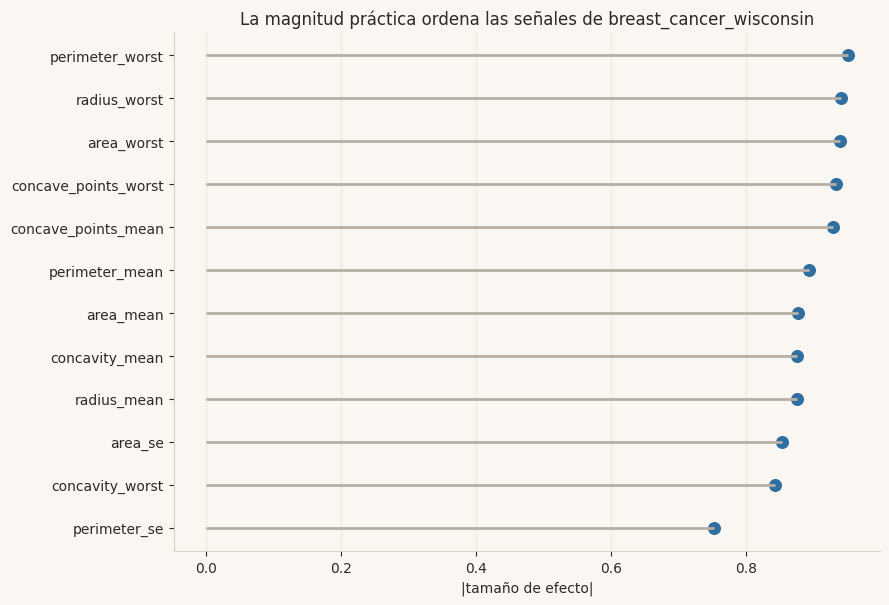

Figura guardada en formatos PNG y PDF.


In [78]:
efecto_resumen_breast_cancer_wisconsin = resumir_tamano_efecto_dataset(asociacion_breast_cancer_wisconsin)
display(efecto_resumen_breast_cancer_wisconsin.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))

figura = graficar_tamano_efecto_dataset("breast_cancer_wisconsin", asociacion_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_10_efecto_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Los mayores tamaños de efecto corresponden a variables diagnósticas numéricas, con Cliff máximo 0,9509. Esto no equivale a independencia entre variables, que se revisa en redundancia.


### Magnitud del Efecto: `customer_churn`


,nombre tamano efecto,variables,|efecto| mediano,|efecto| máximo
no,delta de Cliff,7,0.228510,0.645839
sí,V de Cramér,3,0.175395,0.433553


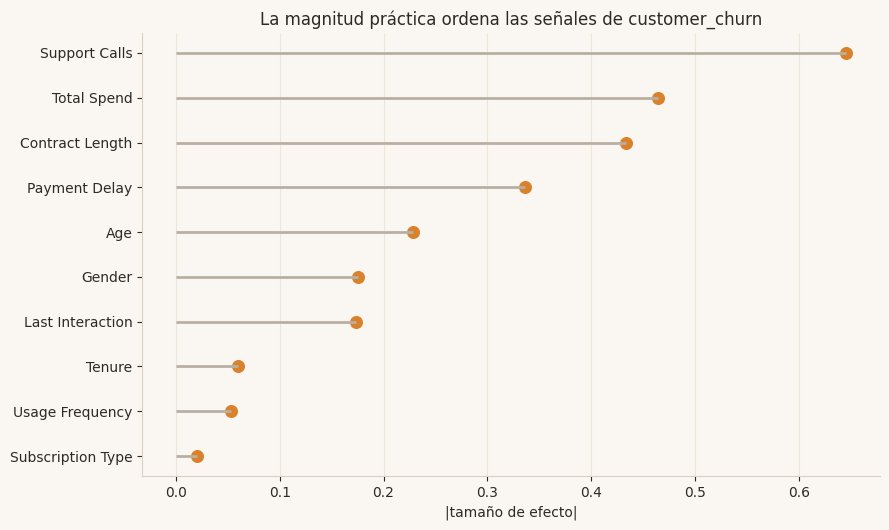

Figura guardada en formatos PNG y PDF.


In [79]:
efecto_resumen_customer_churn = resumir_tamano_efecto_dataset(asociacion_customer_churn)
display(efecto_resumen_customer_churn.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))

figura = graficar_tamano_efecto_dataset("customer_churn", asociacion_customer_churn)
ruta_figura = guardar_figura(figura, "01_10_efecto_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La significancia estadística convive con efectos de distinta magnitud: Cliff mediano 0,2285 y V de Cramér mediano 0,1754. La tabla separa relevancia práctica de tamaño muestral.


### Magnitud del Efecto: `madelon`


,nombre tamano efecto,variables,|efecto| mediano,|efecto| máximo
no,delta de Cliff,500,0.019452,0.262096


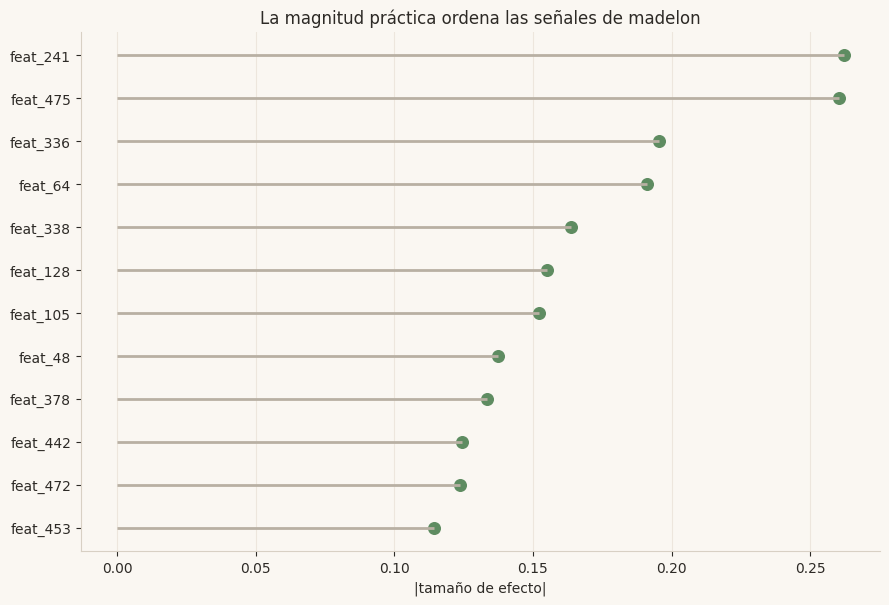

Figura guardada en formatos PNG y PDF.


In [80]:
efecto_resumen_madelon = resumir_tamano_efecto_dataset(asociacion_madelon)
display(efecto_resumen_madelon.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))

figura = graficar_tamano_efecto_dataset("madelon", asociacion_madelon)
ruta_figura = guardar_figura(figura, "01_10_efecto_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Los tamaños de efecto son más moderados que en otros datasets: Cliff mediano 0,0195 y máximo 0,2621. Esto es coherente con un problema diseñado para contener ruido y señal dispersa.


### Magnitud del Efecto: `olive_oil`


,nombre tamano efecto,variables,|efecto| mediano,|efecto| máximo
no,epsilon cuadrado,10,0.797234,1.000000


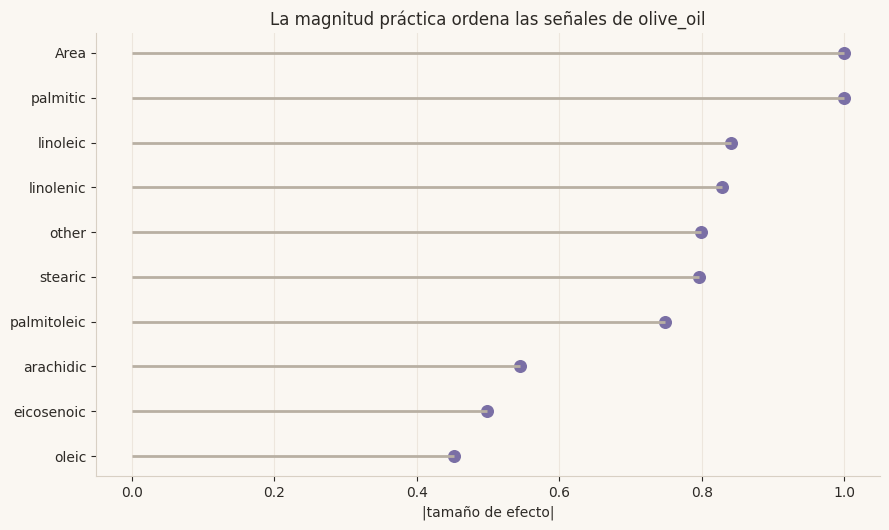

Figura guardada en formatos PNG y PDF.


In [81]:
efecto_resumen_olive_oil = resumir_tamano_efecto_dataset(asociacion_olive_oil)
display(efecto_resumen_olive_oil.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))

figura = graficar_tamano_efecto_dataset("olive_oil", asociacion_olive_oil)
ruta_figura = guardar_figura(figura, "01_10_efecto_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La magnitud del efecto es alta frente al target multiclase, con epsilon squared mediano 0,7972 y máximo 1,0000. Esta fuerza requiere revisión semántica para evitar proxies directos.


In [82]:
resumen_efecto = pd.concat([
    efecto_resumen_breast_cancer_wisconsin.assign(dataset="breast_cancer_wisconsin"),
    efecto_resumen_customer_churn.assign(dataset="customer_churn"),
    efecto_resumen_madelon.assign(dataset="madelon"),
    efecto_resumen_olive_oil.assign(dataset="olive_oil"),
], ignore_index=True)
guardar_tabla(resumen_efecto, "fase1_tamano_efecto_resumen.csv")
display(resumen_efecto.style.format({
    "efecto_abs_mediano": "{:.4f}",
    "efecto_abs_maximo": "{:.4f}",
}))


,nombre tamano efecto,variables,|efecto| mediano,|efecto| máximo,dataset
no,delta de Cliff,30,0.654095,0.950901,Breast Cancer Wisconsin
sí,delta de Cliff,7,0.228510,0.645839,Customer Churn
2,V de Cramér,3,0.175395,0.433553,Customer Churn
3,delta de Cliff,500,0.019452,0.262096,Madelon
4,epsilon cuadrado,10,0.797234,1.000000,Olive Oil


El resumen de efecto muestra perfiles muy distintos. `olive_oil` alcanza epsilon squared mediano 0,7972 y máximo 1,0000; `breast_cancer_wisconsin` tiene Cliff mediano 0,6541 y máximo 0,9509; `customer_churn` combina Cliff mediano 0,2285 con V de Cramér mediano 0,1754; y `madelon` queda mucho más bajo, con Cliff mediano 0,0195 y máximo 0,2621. La pregunta que queda abierta es si las variables de mayor efecto son independientes o redundantes.


## 1.11 Redundancia y Correlación Entre Variables

La redundancia se revisa con Spearman porque mide asociación monótona sin exigir normalidad. El umbral `|rho| >= 0.85` se usa como alerta exploratoria de correlación fuerte, no como regla automática de eliminación. En el paper QFS, las secciones II-IV formulan la redundancia por pares como `R_ij` y la embeben en distancias atómicas mediante MDS para que el bloqueo de Rydberg penalice excitaciones redundantes; esta sección prepara ese mismo razonamiento desde resultados clásicos.


In [83]:
UMBRAL_CORRELACION_ALTA = 0.85


In [84]:
def calcular_matriz_spearman(datos_dataset, target):
    columnas_numericas = obtener_columnas_numericas_predictoras(datos_dataset, target)
    return datos_dataset[columnas_numericas].corr(method="spearman")


def convertir_matriz_correlacion_a_pares(nombre_dataset, matriz_correlacion):
    filas_resultado = []
    columnas = matriz_correlacion.columns
    for posicion, variable_a in enumerate(columnas):
        for variable_b in columnas[posicion + 1:]:
            correlacion = matriz_correlacion.loc[variable_a, variable_b]
            filas_resultado.append({
                "dataset": nombre_dataset,
                "variable_a": variable_a,
                "variable_b": variable_b,
                "spearman": correlacion,
                "abs_spearman": abs(correlacion),
            })
    return pd.DataFrame(filas_resultado)


def resumir_redundancia_dataset(pares_correlacion):
    return pd.DataFrame([{
        "dataset": pares_correlacion["dataset"].iloc[0],
        "pares_evaluados": len(pares_correlacion),
        "pares_correlacion_alta": int((pares_correlacion["abs_spearman"] >= UMBRAL_CORRELACION_ALTA).sum()),
        "correlacion_abs_maxima": pares_correlacion["abs_spearman"].max(),
    }])


In [85]:
def seleccionar_variables_heatmap(pares_correlacion, max_pares=8):
    pares_top = pares_correlacion.nlargest(max_pares, "abs_spearman")
    variables = pd.unique(pares_top[["variable_a", "variable_b"]].to_numpy().ravel())
    return variables.tolist()


def dibujar_ranking_correlaciones(eje, pares_top):
    etiquetas = pares_top["variable_a"] + " / " + pares_top["variable_b"]
    colores = ["#B8B0A3" if valor < UMBRAL_CORRELACION_ALTA else "#B85C5C" for valor in pares_top["abs_spearman"]]
    eje.barh(etiquetas, pares_top["abs_spearman"], color=colores)
    eje.axvline(UMBRAL_CORRELACION_ALTA, color="#6F6A60", linestyle="--", linewidth=1)
    eje.set_xlabel("|Spearman|")
    eje.set_ylabel("")
    aplicar_estilo_eje(eje)


def graficar_redundancia_dataset(nombre_dataset, matriz_correlacion, pares_correlacion):
    variables_heatmap = seleccionar_variables_heatmap(pares_correlacion)
    pares_top = pares_correlacion.nlargest(8, "abs_spearman").sort_values("abs_spearman")
    figura, ejes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.05, 1.25]})
    sns.heatmap(
        matriz_correlacion.loc[variables_heatmap, variables_heatmap],
        vmin=-1,
        vmax=1,
        center=0,
        cmap="vlag",
        ax=ejes[0],
        cbar_kws={"label": "Spearman"},
    )
    ejes[0].set_title("Submatriz de variables implicadas")
    ejes[0].tick_params(axis="x", labelrotation=90, labelsize=8)
    ejes[0].tick_params(axis="y", labelsize=8)
    dibujar_ranking_correlaciones(ejes[1], pares_top)
    ejes[1].set_title("Pares más redundantes")
    ejes[1].text(UMBRAL_CORRELACION_ALTA + 0.01, ejes[1].get_ylim()[0] + 0.4, "|rho|=0,85", color="#6F6A60", fontsize=9)
    n_pares_altos = int((pares_correlacion["abs_spearman"] >= UMBRAL_CORRELACION_ALTA).sum())
    figura.suptitle(f"{nombre_dataset} presenta {n_pares_altos} pares por encima de |rho|=0,85", y=1.03)
    figura.tight_layout()
    return figura


### Redundancia: `breast_cancer_wisconsin`


,dataset,pares evaluados,pares correlacion alta,|correlación| máxima
no,Breast Cancer Wisconsin,435,29,0.999602


,dataset,variable A,variable B,Spearman,|Spearman|
2,Breast Cancer Wisconsin,radius_mean,area_mean,0.999602,0.999602
392,Breast Cancer Wisconsin,radius_worst,area_worst,0.998891,0.998891
sí,Breast Cancer Wisconsin,radius_mean,perimeter_mean,0.997802,0.997802
57,Breast Cancer Wisconsin,perimeter_mean,area_mean,0.997068,0.997068
391,Breast Cancer Wisconsin,radius_worst,perimeter_worst,0.993548,0.993548
407,Breast Cancer Wisconsin,perimeter_worst,area_worst,0.992433,0.992433
74,Breast Cancer Wisconsin,perimeter_mean,radius_worst,0.981244,0.981244
77,Breast Cancer Wisconsin,perimeter_mean,area_worst,0.980864,0.980864
103,Breast Cancer Wisconsin,area_mean,area_worst,0.980264,0.980264
100,Breast Cancer Wisconsin,area_mean,radius_worst,0.979258,0.979258


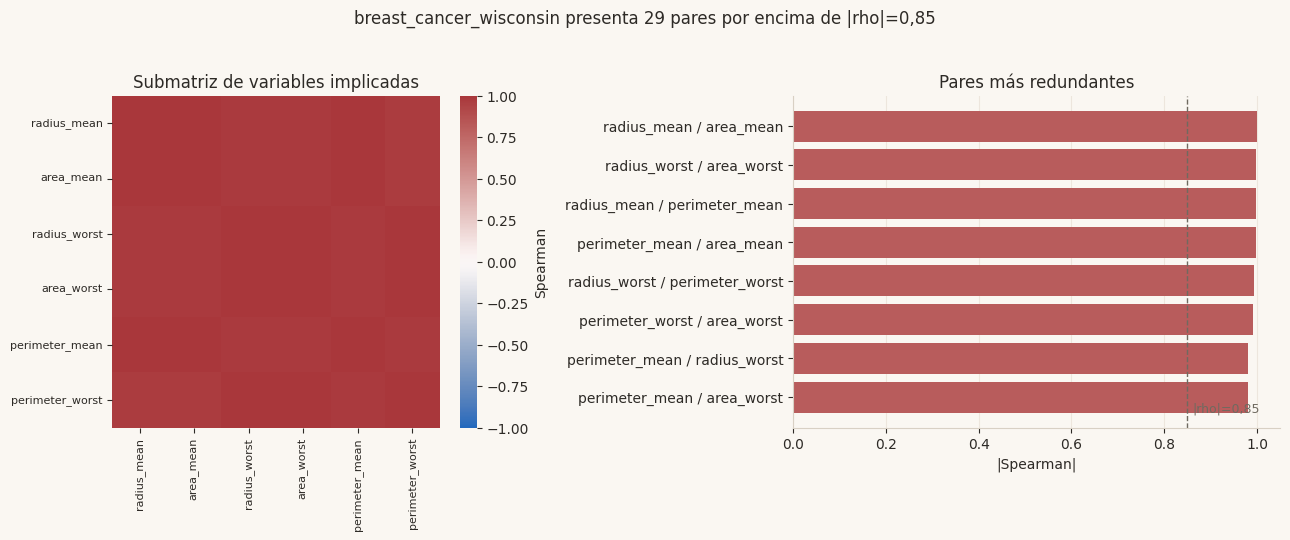

Figura guardada en formatos PNG y PDF.


In [86]:
matriz_spearman_breast_cancer_wisconsin = calcular_matriz_spearman(
    muestras_visuales["breast_cancer_wisconsin"],
    targets_esperados["breast_cancer_wisconsin"],
)
pares_spearman_breast_cancer_wisconsin = convertir_matriz_correlacion_a_pares(
    "breast_cancer_wisconsin",
    matriz_spearman_breast_cancer_wisconsin,
)
redundancia_breast_cancer_wisconsin = resumir_redundancia_dataset(pares_spearman_breast_cancer_wisconsin)

display(redundancia_breast_cancer_wisconsin.style.format({"correlacion_abs_maxima": "{:.3f}"}))
display(pares_spearman_breast_cancer_wisconsin.nlargest(10, "abs_spearman").style.format({
    "spearman": "{:.3f}",
    "abs_spearman": "{:.3f}",
}))

figura = graficar_redundancia_dataset("breast_cancer_wisconsin", matriz_spearman_breast_cancer_wisconsin, pares_spearman_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_11_redundancia_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Se observan 29 pares con `|Spearman| >= 0,85` y correlación máxima 1,000 entre variables de la misma familia diagnóstica. Este dataset necesitará control de redundancia.


### Redundancia: `customer_churn`


,dataset,pares evaluados,pares correlacion alta,|correlación| máxima
no,Customer Churn,21,0,0.190689


,dataset,variable A,variable B,Spearman,|Spearman|
16,Customer Churn,Support Calls,Total Spend,-0.190689,0.190689
2,Customer Churn,Age,Support Calls,0.153180,0.153180
15,Customer Churn,Support Calls,Payment Delay,0.147168,0.147168
18,Customer Churn,Payment Delay,Total Spend,-0.105478,0.105478
4,Customer Churn,Age,Total Spend,-0.078079,0.078079
19,Customer Churn,Payment Delay,Last Interaction,0.070892,0.070892
17,Customer Churn,Support Calls,Last Interaction,0.064018,0.064018
3,Customer Churn,Age,Payment Delay,0.057306,0.057306
20,Customer Churn,Total Spend,Last Interaction,-0.043476,0.043476
9,Customer Churn,Tenure,Total Spend,0.036132,0.036132


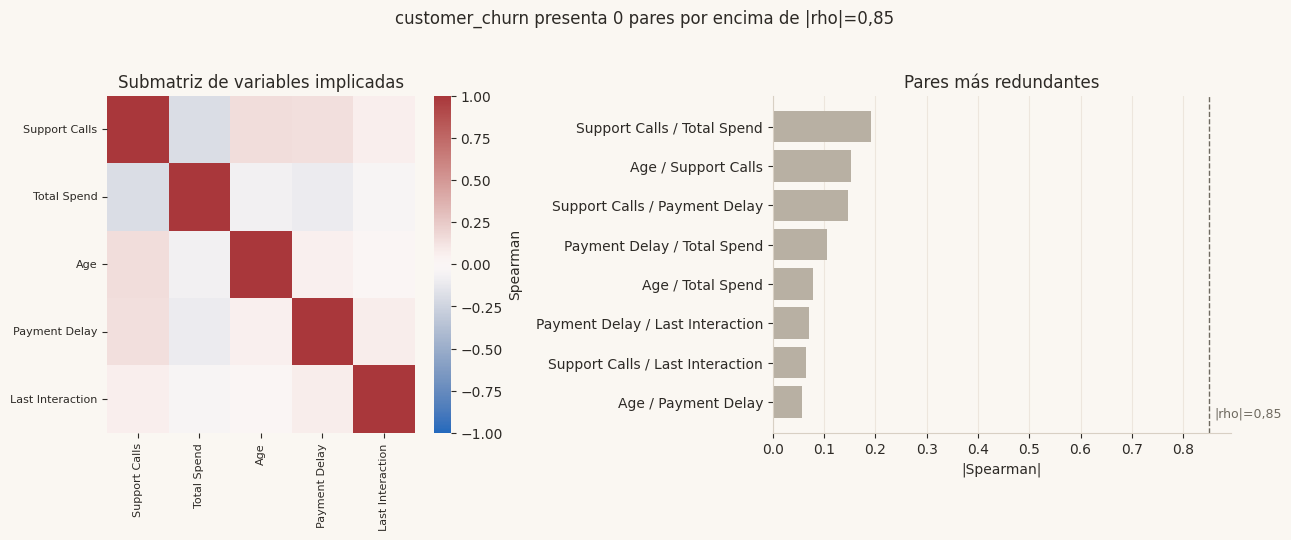

Figura guardada en formatos PNG y PDF.


In [87]:
matriz_spearman_customer_churn = calcular_matriz_spearman(
    muestras_visuales["customer_churn"],
    targets_esperados["customer_churn"],
)
pares_spearman_customer_churn = convertir_matriz_correlacion_a_pares(
    "customer_churn",
    matriz_spearman_customer_churn,
)
redundancia_customer_churn = resumir_redundancia_dataset(pares_spearman_customer_churn)

display(redundancia_customer_churn.style.format({"correlacion_abs_maxima": "{:.3f}"}))
display(pares_spearman_customer_churn.nlargest(10, "abs_spearman").style.format({
    "spearman": "{:.3f}",
    "abs_spearman": "{:.3f}",
}))

figura = graficar_redundancia_dataset("customer_churn", matriz_spearman_customer_churn, pares_spearman_customer_churn)
ruta_figura = guardar_figura(figura, "01_11_redundancia_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


No aparecen pares por encima de `|Spearman| >= 0.85`. La redundancia lineal/monótona no parece la principal cautela en este dataset.


### Redundancia: `madelon`


,dataset,pares evaluados,pares correlacion alta,|correlación| máxima
no,Madelon,124750,12,0.996145


,dataset,variable A,variable B,Spearman,|Spearman|
123126,Madelon,feat_442,feat_472,0.996145,0.996145
30191,Madelon,feat_64,feat_336,0.995649,0.995649
123708,Madelon,feat_453,feat_493,0.995000,0.995000
46957,Madelon,feat_105,feat_128,0.994693,0.994693
13883,Madelon,feat_28,feat_318,0.991467,0.991467
108411,Madelon,feat_318,feat_451,0.991039,0.991039
91572,Madelon,feat_241,feat_475,0.990637,0.990637
14016,Madelon,feat_28,feat_451,0.990560,0.990560
64846,Madelon,feat_153,feat_281,0.990236,0.990236
64998,Madelon,feat_153,feat_433,0.989990,0.989990


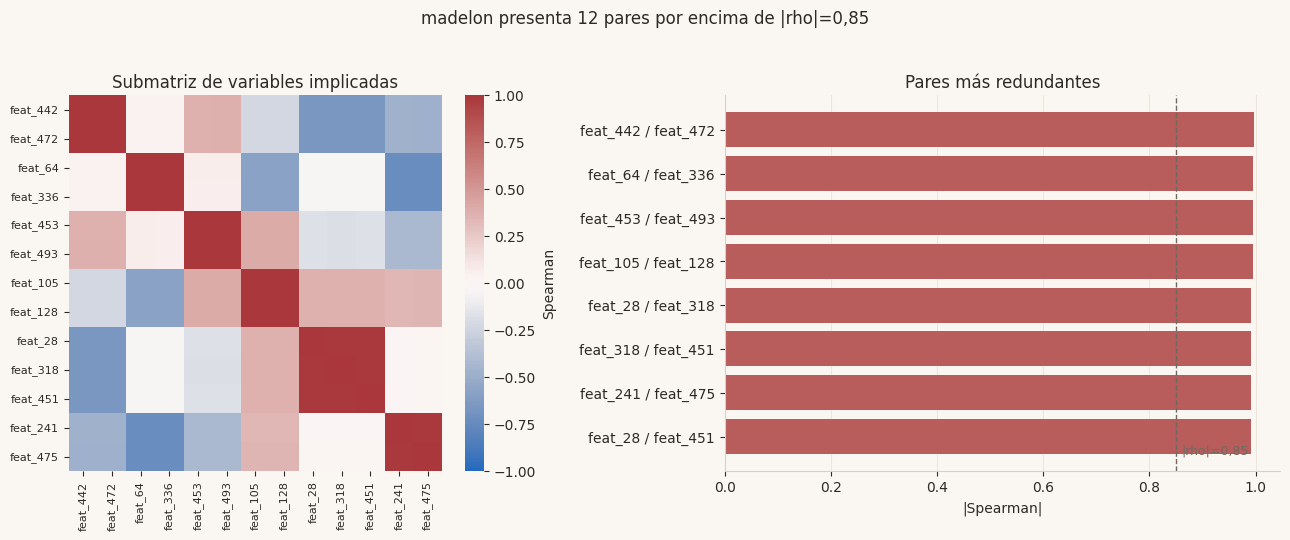

Figura guardada en formatos PNG y PDF.


In [88]:
matriz_spearman_madelon = calcular_matriz_spearman(
    muestras_visuales["madelon"],
    targets_esperados["madelon"],
)
pares_spearman_madelon = convertir_matriz_correlacion_a_pares(
    "madelon",
    matriz_spearman_madelon,
)
redundancia_madelon = resumir_redundancia_dataset(pares_spearman_madelon)

display(redundancia_madelon.style.format({"correlacion_abs_maxima": "{:.3f}"}))
display(pares_spearman_madelon.nlargest(10, "abs_spearman").style.format({
    "spearman": "{:.3f}",
    "abs_spearman": "{:.3f}",
}))

figura = graficar_redundancia_dataset("madelon", matriz_spearman_madelon, pares_spearman_madelon)
ruta_figura = guardar_figura(figura, "01_11_redundancia_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Aparecen 12 pares con `|Spearman| >= 0,85` dentro de una matriz de 124.750 pares. El problema sigue siendo tanto dimensional como de señal dispersa.


### Redundancia: `olive_oil`


,dataset,pares evaluados,pares correlacion alta,|correlación| máxima
no,Olive Oil,45,2,0.916474


,dataset,variable A,variable B,Spearman,|Spearman|
no,Olive Oil,Area,palmitic,0.916474,0.916474
25,Olive Oil,stearic,linoleic,-0.864409,0.864409
35,Olive Oil,linoleic,linolenic,-0.841592,0.841592
19,Olive Oil,palmitoleic,linoleic,-0.836165,0.836165
8,Olive Oil,Area,other,-0.829451,0.829451
17,Olive Oil,palmitoleic,stearic,0.803355,0.803355
16,Olive Oil,palmitic,other,-0.758656,0.758656
4,Olive Oil,Area,linoleic,0.689911,0.689911
sí,Olive Oil,Area,palmitoleic,-0.682045,0.682045
26,Olive Oil,stearic,linolenic,0.640340,0.640340


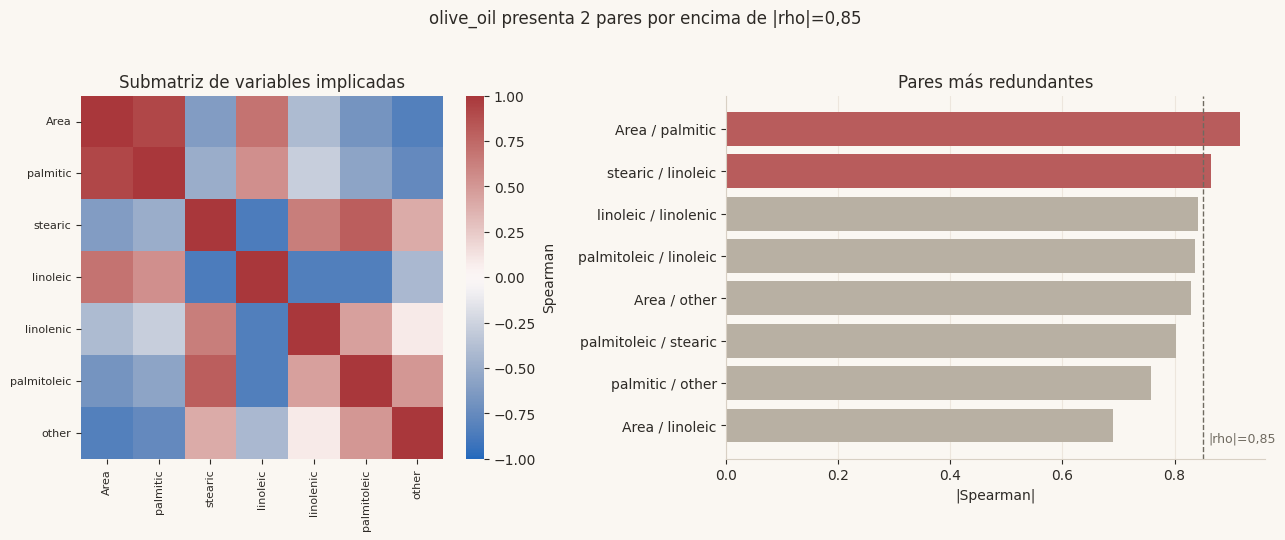

Figura guardada en formatos PNG y PDF.


In [89]:
matriz_spearman_olive_oil = calcular_matriz_spearman(
    muestras_visuales["olive_oil"],
    targets_esperados["olive_oil"],
)
pares_spearman_olive_oil = convertir_matriz_correlacion_a_pares(
    "olive_oil",
    matriz_spearman_olive_oil,
)
redundancia_olive_oil = resumir_redundancia_dataset(pares_spearman_olive_oil)

display(redundancia_olive_oil.style.format({"correlacion_abs_maxima": "{:.3f}"}))
display(pares_spearman_olive_oil.nlargest(10, "abs_spearman").style.format({
    "spearman": "{:.3f}",
    "abs_spearman": "{:.3f}",
}))

figura = graficar_redundancia_dataset("olive_oil", matriz_spearman_olive_oil, pares_spearman_olive_oil)
ruta_figura = guardar_figura(figura, "01_11_redundancia_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Aparecen 2 pares altamente correlacionados entre 45 pares de variables de composición. La redundancia debe considerarse antes de selección de características.


In [90]:
correlaciones_pares = pd.concat([
    pares_spearman_breast_cancer_wisconsin,
    pares_spearman_customer_churn,
    pares_spearman_madelon,
    pares_spearman_olive_oil,
], ignore_index=True)
resumen_redundancia = pd.concat([
    redundancia_breast_cancer_wisconsin,
    redundancia_customer_churn,
    redundancia_madelon,
    redundancia_olive_oil,
], ignore_index=True)

guardar_tabla(correlaciones_pares, "fase1_correlaciones_spearman_pares.csv")
guardar_tabla(resumen_redundancia, "fase1_redundancia_resumen.csv")
display(resumen_redundancia.style.format({"correlacion_abs_maxima": "{:.3f}"}))


,dataset,pares evaluados,pares correlacion alta,|correlación| máxima
no,Breast Cancer Wisconsin,435,29,0.999602
sí,Customer Churn,21,0,0.190689
2,Madelon,124750,12,0.996145
3,Olive Oil,45,2,0.916474


La comparación de redundancia evalúa 435 pares en `breast_cancer_wisconsin`, 21 en `customer_churn`, 124.750 en `madelon` y 45 en `olive_oil`. Superan `|rho| >= 0,85` un total de 29 pares en `breast_cancer_wisconsin`, 12 en `madelon`, 2 en `olive_oil` y 0 en `customer_churn`; las correlaciones máximas son 1,000, 0,996, 0,916 y 0,191 respectivamente. Esta lectura enlaza directamente con el término `R_ij` que QFS convertirá en proximidad atómica.


## 1.12 Dimensionalidad y PCA Exploratorio

PCA se usa aquí como diagnóstico previo a la selección de características. La pregunta no es si PCA predice bien, sino si la varianza numérica parece concentrarse en pocas componentes o si permanece muy distribuida.


In [91]:
UMBRALES_VARIANZA_PCA = [0.80, 0.90]


In [92]:
def preparar_matriz_pca(datos_dataset, target):
    columnas_numericas = obtener_columnas_numericas_predictoras(datos_dataset, target)
    matriz_numerica = datos_dataset[columnas_numericas].dropna()
    matriz_escalada = StandardScaler().fit_transform(matriz_numerica)
    return matriz_escalada, columnas_numericas


def calcular_pca_dataset(nombre_dataset, datos_dataset, target):
    matriz_escalada, columnas_numericas = preparar_matriz_pca(datos_dataset, target)
    pca = PCA(random_state=RANDOM_STATE)
    pca.fit(matriz_escalada)
    return pd.DataFrame({
        "dataset": nombre_dataset,
        "componente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "varianza_explicada": pca.explained_variance_ratio_,
        "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_),
        "n_variables_pca": len(columnas_numericas),
        "n_filas_pca": matriz_escalada.shape[0],
    })


In [93]:
def componentes_para_umbral(pca_dataset, umbral):
    supera_umbral = pca_dataset[pca_dataset["varianza_acumulada"] >= umbral]
    return int(supera_umbral["componente"].iloc[0]) if not supera_umbral.empty else np.nan


def resumir_pca_dataset(pca_dataset):
    return pd.DataFrame([{
        "dataset": pca_dataset["dataset"].iloc[0],
        "componentes_80": componentes_para_umbral(pca_dataset, 0.80),
        "componentes_90": componentes_para_umbral(pca_dataset, 0.90),
        "n_variables_pca": int(pca_dataset["n_variables_pca"].iloc[0]),
        "n_filas_pca": int(pca_dataset["n_filas_pca"].iloc[0]),
    }])


def graficar_pca_dataset(nombre_dataset, pca_dataset):
    figura, eje = plt.subplots(figsize=(8.5, 4.6))
    eje.plot(pca_dataset["componente"], pca_dataset["varianza_acumulada"], marker="o", markersize=3, color=PALETA_DATASETS[nombre_dataset])
    eje.axhline(0.80, color="#B85C5C", linestyle="--", linewidth=1, label="80%")
    eje.axhline(0.90, color="#6F6A60", linestyle=":", linewidth=1, label="90%")
    componentes_80 = componentes_para_umbral(pca_dataset, 0.80)
    eje.set_title(f"{nombre_dataset} alcanza el 80% de varianza en {componentes_80} componentes")
    eje.set_xlabel("componente principal")
    eje.set_ylabel("varianza acumulada")
    eje.set_ylim(0, 1.02)
    eje.legend(frameon=False)
    aplicar_estilo_eje(eje, "both")
    figura.tight_layout()
    return figura


### PCA Exploratorio: `breast_cancer_wisconsin`


,dataset,componentes para 80%,componentes para 90%,n variables pca,n filas pca
no,Breast Cancer Wisconsin,5,7,30,569


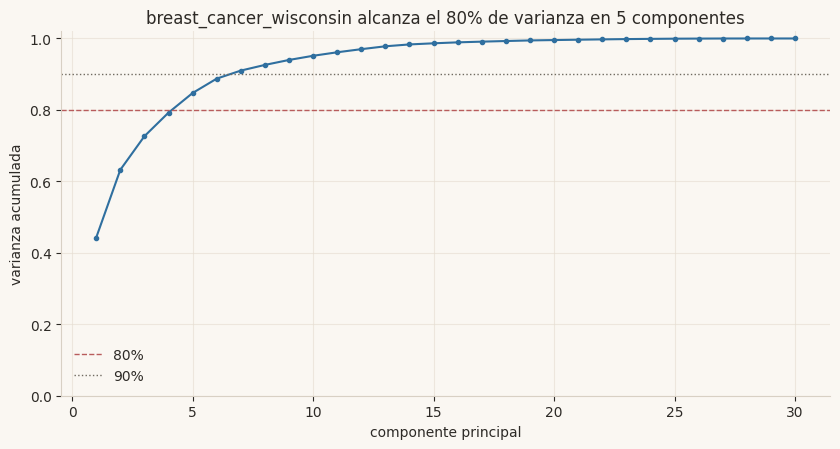

Figura guardada en formatos PNG y PDF.


In [94]:
pca_breast_cancer_wisconsin = calcular_pca_dataset(
    "breast_cancer_wisconsin",
    muestras_visuales["breast_cancer_wisconsin"],
    targets_esperados["breast_cancer_wisconsin"],
)
pca_resumen_breast_cancer_wisconsin = resumir_pca_dataset(pca_breast_cancer_wisconsin)

display(pca_resumen_breast_cancer_wisconsin)
figura = graficar_pca_dataset("breast_cancer_wisconsin", pca_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_12_pca_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Pocas componentes explican gran parte de la varianza: 5 alcanzan el 80% y 7 el 90%, coherente con la redundancia entre variables diagnósticas.


### PCA Exploratorio: `customer_churn`


,dataset,componentes para 80%,componentes para 90%,n variables pca,n filas pca
no,Customer Churn,6,7,7,5000


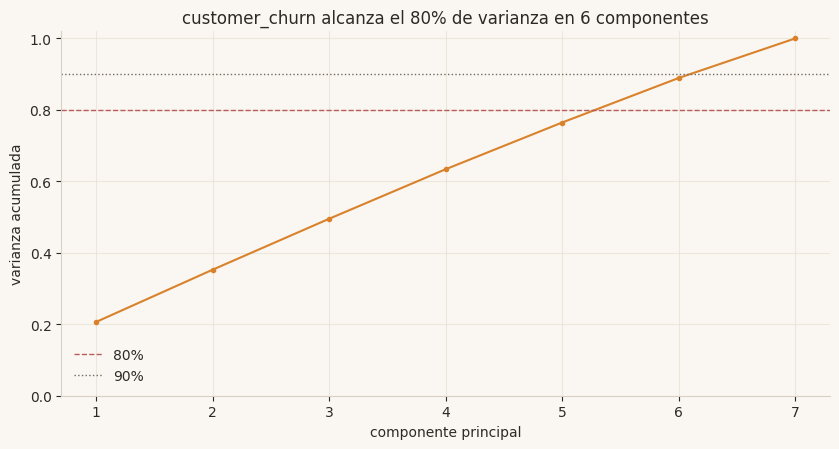

Figura guardada en formatos PNG y PDF.


In [95]:
pca_customer_churn = calcular_pca_dataset(
    "customer_churn",
    muestras_visuales["customer_churn"],
    targets_esperados["customer_churn"],
)
pca_resumen_customer_churn = resumir_pca_dataset(pca_customer_churn)

display(pca_resumen_customer_churn)
figura = graficar_pca_dataset("customer_churn", pca_customer_churn)
ruta_figura = guardar_figura(figura, "01_12_pca_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La varianza se concentra en pocas componentes: 6 alcanzan el 80% y 7 el 90% entre 7 variables numéricas. Este diagnóstico usa la muestra visual por coste de representación.


### PCA Exploratorio: `madelon`


,dataset,componentes para 80%,componentes para 90%,n variables pca,n filas pca
no,Madelon,295,369,500,2000


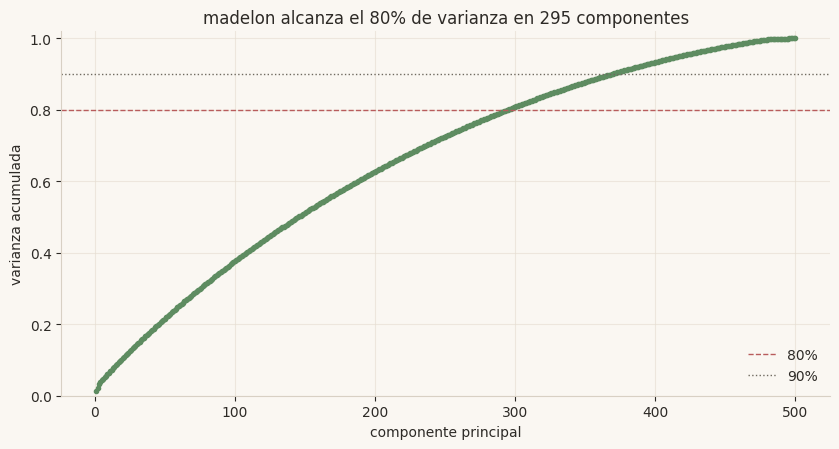

Figura guardada en formatos PNG y PDF.


In [96]:
pca_madelon = calcular_pca_dataset(
    "madelon",
    muestras_visuales["madelon"],
    targets_esperados["madelon"],
)
pca_resumen_madelon = resumir_pca_dataset(pca_madelon)

display(pca_resumen_madelon)
figura = graficar_pca_dataset("madelon", pca_madelon)
ruta_figura = guardar_figura(figura, "01_12_pca_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


Se necesitan muchas componentes para alcanzar 80% y 90% de varianza. Esto confirma que no hay una compresión simple de la estructura numérica.


### PCA Exploratorio: `olive_oil`


,dataset,componentes para 80%,componentes para 90%,n variables pca,n filas pca
no,Olive Oil,3,5,10,572


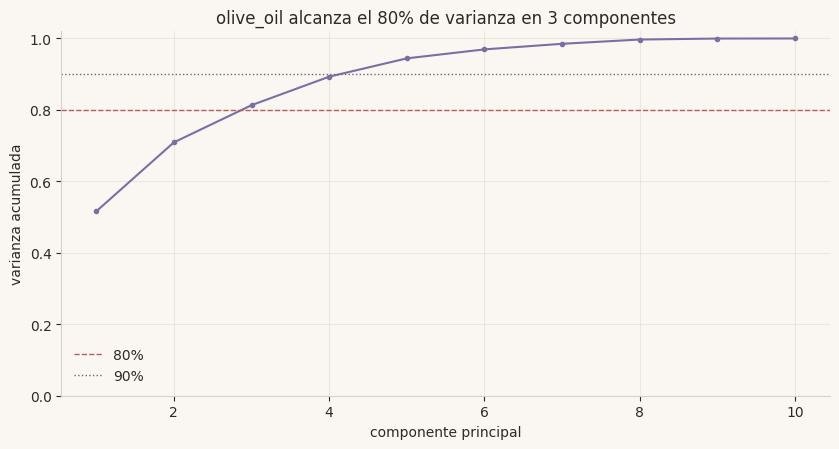

Figura guardada en formatos PNG y PDF.


In [97]:
pca_olive_oil = calcular_pca_dataset(
    "olive_oil",
    muestras_visuales["olive_oil"],
    targets_esperados["olive_oil"],
)
pca_resumen_olive_oil = resumir_pca_dataset(pca_olive_oil)

display(pca_resumen_olive_oil)
figura = graficar_pca_dataset("olive_oil", pca_olive_oil)
ruta_figura = guardar_figura(figura, "01_12_pca_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La varianza se concentra en 3 componentes para el 80% y 5 para el 90%, lo que encaja con correlaciones entre variables de composición.


In [98]:
pca_resultados = pd.concat([
    pca_breast_cancer_wisconsin,
    pca_customer_churn,
    pca_madelon,
    pca_olive_oil,
], ignore_index=True)
pca_resumen = pd.concat([
    pca_resumen_breast_cancer_wisconsin,
    pca_resumen_customer_churn,
    pca_resumen_madelon,
    pca_resumen_olive_oil,
], ignore_index=True)

guardar_tabla(pca_resultados, "fase1_pca_varianza.csv")
guardar_tabla(pca_resumen, "fase1_pca_resumen.csv")
display(pca_resumen)


,dataset,componentes para 80%,componentes para 90%,n variables pca,n filas pca
no,Breast Cancer Wisconsin,5,7,30,569
sí,Customer Churn,6,7,7,5000
2,Madelon,295,369,500,2000
3,Olive Oil,3,5,10,572


PCA resume la presión geométrica de cada dataset. `breast_cancer_wisconsin` alcanza el 80% de varianza con 5 componentes y el 90% con 7; `olive_oil` necesita 3 y 5; `customer_churn` necesita 6 y 7 entre sus 7 numéricas; y `madelon` requiere 295 y 369 de 500 componentes. La lectura es consistente con el resto del EDA: `madelon` no ofrece una compresión lineal sencilla y debe tratarse como testbed de alta dimensionalidad.


## 1.13 Señales Espurias, Proxies y Variables a Revisar

Una asociación espuria es una señal que puede desaparecer tras controlar múltiples contrastes. El criterio técnico marca tres reglas: significancia solo antes de FDR, efecto significativo pero mínimo y efecto casi perfecto; un proxy representa indirectamente información cercana al target, y una fuga potencial indica información no disponible en un escenario real de predicción. En esta fase solo se señalan variables que conviene revisar antes de modelar.


In [99]:
UMBRAL_EFECTO_MINIMO = 0.05
UMBRAL_EFECTO_CASI_PERFECTO = 0.95


In [100]:
def cumple_significativa_solo_sin_fdr(fila):
    return fila["p_valor"] < ALFA_FDR and fila["p_valor_fdr"] >= ALFA_FDR


def cumple_significativa_con_efecto_minimo(fila):
    return fila["p_valor_fdr"] < ALFA_FDR and fila["abs_tamano_efecto"] <= UMBRAL_EFECTO_MINIMO


def cumple_efecto_casi_perfecto(fila):
    return fila["abs_tamano_efecto"] >= UMBRAL_EFECTO_CASI_PERFECTO


def marcar_reglas_revision(tabla):
    tabla_marcada = tabla.copy()
    tabla_marcada["solo_significativa_sin_fdr"] = tabla_marcada.apply(cumple_significativa_solo_sin_fdr, axis=1)
    tabla_marcada["significativa_efecto_minimo"] = tabla_marcada.apply(cumple_significativa_con_efecto_minimo, axis=1)
    tabla_marcada["efecto_casi_perfecto"] = tabla_marcada.apply(cumple_efecto_casi_perfecto, axis=1)
    return tabla_marcada


In [101]:
def detectar_variables_revision_dataset(asociaciones_dataset):
    variables_marcadas = marcar_reglas_revision(asociaciones_dataset)
    columnas_reglas = ["solo_significativa_sin_fdr", "significativa_efecto_minimo", "efecto_casi_perfecto"]
    return variables_marcadas[variables_marcadas[columnas_reglas].any(axis=1)].copy()


def resumir_variables_revision_dataset(variables_revision_dataset, nombre_dataset):
    columnas_reglas = ["solo_significativa_sin_fdr", "significativa_efecto_minimo", "efecto_casi_perfecto"]
    if variables_revision_dataset.empty:
        return pd.DataFrame([{**{"dataset": nombre_dataset, "variables_a_revisar": 0}, **{columna: 0 for columna in columnas_reglas}}])
    return pd.DataFrame([{
        "dataset": nombre_dataset,
        "variables_a_revisar": len(variables_revision_dataset),
        **{columna: int(variables_revision_dataset[columna].sum()) for columna in columnas_reglas},
    }])


### Variables a Revisar: `breast_cancer_wisconsin`


In [102]:
revision_breast_cancer_wisconsin = detectar_variables_revision_dataset(asociacion_breast_cancer_wisconsin)
revision_resumen_breast_cancer_wisconsin = resumir_variables_revision_dataset(revision_breast_cancer_wisconsin, "breast_cancer_wisconsin")

display(revision_resumen_breast_cancer_wisconsin)
if revision_breast_cancer_wisconsin.empty:
    display(Markdown("No se marcan variables para revisión con estas reglas exploratorias."))
else:
    display(revision_breast_cancer_wisconsin.sort_values("abs_tamano_efecto", ascending=False).style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    }))


,dataset,variables a revisar,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Breast Cancer Wisconsin,1,0,0,1


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
22,Breast Cancer Wisconsin,perimeter_worst,Mann-Whitney U,73826.000000,0.000000,delta de Cliff,0.950901,0.000000,0.950901,no,no,sí


Aparece 1 variable con efecto casi perfecto. Esto no confirma fuga de información, pero sí obliga a revisar semántica y redundancia antes de modelar.


### Variables a Revisar: `customer_churn`


In [103]:
revision_customer_churn = detectar_variables_revision_dataset(asociacion_customer_churn)
revision_resumen_customer_churn = resumir_variables_revision_dataset(revision_customer_churn, "customer_churn")

display(revision_resumen_customer_churn)
if revision_customer_churn.empty:
    display(Markdown("No se marcan variables para revisión con estas reglas exploratorias."))
else:
    display(revision_customer_churn.sort_values("abs_tamano_efecto", ascending=False).style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    }))


,dataset,variables a revisar,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Customer Churn,1,0,1,0


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
6,Customer Churn,Subscription Type,chi-cuadrado,186.225147,0.000000,V de Cramér,0.020553,0.000000,0.020553,no,sí,no


Aparece 1 señal significativa con efecto mínimo. Este caso ilustra por qué no basta con mirar p-valores en datasets grandes.


### Variables a Revisar: `madelon`


In [104]:
revision_madelon = detectar_variables_revision_dataset(asociacion_madelon)
revision_resumen_madelon = resumir_variables_revision_dataset(revision_madelon, "madelon")

display(revision_resumen_madelon)
if revision_madelon.empty:
    display(Markdown("No se marcan variables para revisión con estas reglas exploratorias."))
else:
    display(revision_madelon.sort_values("abs_tamano_efecto", ascending=False).style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    }))


,dataset,variables a revisar,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Madelon,25,25,0,0


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
323,Madelon,feat_323,Mann-Whitney U,537889.500000,0.003334,delta de Cliff,0.075779,0.119058,0.075779,sí,no,no
411,Madelon,feat_411,Mann-Whitney U,533636.500000,0.009191,delta de Cliff,0.067273,0.306368,0.067273,sí,no,no
282,Madelon,feat_282,Mann-Whitney U,467371.000000,0.011497,delta de Cliff,-0.065258,0.350409,0.065258,sí,no,no
424,Madelon,feat_424,Mann-Whitney U,467538.500000,0.011914,delta de Cliff,-0.064923,0.350409,0.064923,sí,no,no
10,Madelon,feat_10,Mann-Whitney U,531634.000000,0.014293,delta de Cliff,0.063268,0.353541,0.063268,sí,no,no
298,Madelon,feat_298,Mann-Whitney U,531444.000000,0.014883,delta de Cliff,0.062888,0.353541,0.062888,sí,no,no
296,Madelon,feat_296,Mann-Whitney U,531332.500000,0.015243,delta de Cliff,0.062665,0.353541,0.062665,sí,no,no
430,Madelon,feat_430,Mann-Whitney U,531176.500000,0.015755,delta de Cliff,0.062353,0.353541,0.062353,sí,no,no
136,Madelon,feat_136,Mann-Whitney U,468885.000000,0.015970,delta de Cliff,-0.062230,0.353541,0.062230,sí,no,no
377,Madelon,feat_377,Mann-Whitney U,531026.500000,0.016263,delta de Cliff,0.062053,0.353541,0.062053,sí,no,no


Predominan 25 variables que eran significativas sin corrección y dejan de serlo tras FDR. Esto encaja con falsos positivos exploratorios.


### Variables a Revisar: `olive_oil`


In [105]:
revision_olive_oil = detectar_variables_revision_dataset(asociacion_olive_oil)
revision_resumen_olive_oil = resumir_variables_revision_dataset(revision_olive_oil, "olive_oil")

display(revision_resumen_olive_oil)
if revision_olive_oil.empty:
    display(Markdown("No se marcan variables para revisión con estas reglas exploratorias."))
else:
    display(revision_olive_oil.sort_values("abs_tamano_efecto", ascending=False).style.format({
        "p_valor": "{:.2e}",
        "p_valor_fdr": "{:.2e}",
        "tamano_efecto": "{:.4f}",
        "abs_tamano_efecto": "{:.4f}",
    }))


,dataset,variables a revisar,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Olive Oil,2,0,0,2


,dataset,variable,test,estadistico,p-valor,nombre tamano efecto,tamano efecto,p-valor FDR,|tamaño de efecto|,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Olive Oil,Area,Kruskal-Wallis,571.000000,0.000000,epsilon cuadrado,1.000000,0.000000,1.000000,no,no,sí
sí,Olive Oil,palmitic,Kruskal-Wallis,571.000000,0.000000,epsilon cuadrado,1.000000,0.000000,1.000000,no,no,sí


Aparecen 2 variables con efecto casi perfecto frente al target multiclase. La revisión semántica es obligatoria para evitar proxies directos de región.


In [106]:
variables_revision = pd.concat([
    revision_breast_cancer_wisconsin,
    revision_customer_churn,
    revision_madelon,
    revision_olive_oil,
], ignore_index=True)
resumen_revision = pd.concat([
    revision_resumen_breast_cancer_wisconsin,
    revision_resumen_customer_churn,
    revision_resumen_madelon,
    revision_resumen_olive_oil,
], ignore_index=True)

guardar_tabla(variables_revision, "fase1_variables_revision_riesgos.csv")
guardar_tabla(resumen_revision, "fase1_riesgos_resumen.csv")
display(resumen_revision)


,dataset,variables a revisar,solo significativa sin fdr,significativa efecto minimo,efecto casi perfecto
no,Breast Cancer Wisconsin,1,0,0,1
sí,Customer Churn,1,0,1,0
2,Madelon,25,25,0,0
3,Olive Oil,2,0,0,2


El resumen marca 1 variable en `breast_cancer_wisconsin`, 1 en `customer_churn`, 25 en `madelon` y 2 en `olive_oil`. Los motivos también cambian: `madelon` acumula 25 variables que solo eran significativas antes de FDR, `customer_churn` aporta 1 señal significativa con efecto mínimo y los otros dos datasets concentran efectos casi perfectos. Esta sección no elimina variables, pero fija qué señales deberán revisarse antes de modelar.


## 1.14 Preclasificación Exploratoria de Variables

La preclasificación resume la lectura disponible por dataset mediante reglas explícitas sobre FDR, tamaño de efecto, redundancia `|rho| >= 0,85` y variables a revisar. No es selección final: solo organiza señales fuertes, señales moderadas, redundancia alta, cautelas de revisión y ausencia de señal univariante.


In [107]:
def crear_conjunto_variables_redundantes(pares_correlacion):
    pares_altos = pares_correlacion[pares_correlacion["abs_spearman"] >= UMBRAL_CORRELACION_ALTA]
    variables = set()
    for _, fila in pares_altos.iterrows():
        variables.add((fila["dataset"], fila["variable_a"]))
        variables.add((fila["dataset"], fila["variable_b"]))
    return variables


def crear_conjunto_variables_revision(variables_revision_dataset):
    return set(zip(variables_revision_dataset["dataset"], variables_revision_dataset["variable"]))


def clasificar_variable_exploratoria(fila, variables_redundantes, variables_a_revisar):
    clave_variable = (fila["dataset"], fila["variable"])
    if clave_variable in variables_a_revisar:
        return "revisar_riesgo"
    if clave_variable in variables_redundantes:
        return "redundancia_alta"
    if fila["p_valor_fdr"] < ALFA_FDR and fila["abs_tamano_efecto"] >= 0.30:
        return "senal_fuerte"
    if fila["p_valor_fdr"] < ALFA_FDR:
        return "senal_moderada"
    return "sin_senal_univariante"


In [108]:
def preclasificar_dataset(asociaciones_dataset, pares_correlacion, variables_revision_dataset):
    variables_redundantes = crear_conjunto_variables_redundantes(pares_correlacion)
    variables_a_revisar = crear_conjunto_variables_revision(variables_revision_dataset)
    preclasificacion = asociaciones_dataset.copy()
    preclasificacion["categoria_exploratoria"] = preclasificacion.apply(
        clasificar_variable_exploratoria,
        axis=1,
        variables_redundantes=variables_redundantes,
        variables_a_revisar=variables_a_revisar,
    )
    return preclasificacion


def resumir_preclasificacion(preclasificacion_dataset):
    return (
        preclasificacion_dataset
        .groupby(["dataset", "categoria_exploratoria"])
        .size()
        .rename("n_variables")
        .reset_index()
    )


def graficar_preclasificacion_dataset(nombre_dataset, resumen_dataset):
    figura, eje = plt.subplots(figsize=(8, 3.4))
    datos_grafico = resumen_dataset.assign(
        categoria_presentada=lambda tabla: tabla["categoria_exploratoria"].map(VALORES_PRESENTACION)
    )
    sns.barplot(datos_grafico, y="categoria_presentada", x="n_variables", color=PALETA_DATASETS[nombre_dataset], ax=eje)
    eje.set_title(f"La lectura inicial reparte las variables de {nombre_dataset} por categoría")
    eje.set_xlabel("número de variables")
    eje.set_ylabel("")
    aplicar_estilo_eje(eje)
    figura.tight_layout()
    return figura


### Preclasificación: `breast_cancer_wisconsin`


,dataset,categoría exploratoria,n variables
no,Breast Cancer Wisconsin,redundancia alta,18
sí,Breast Cancer Wisconsin,revisar por cautela,1
2,Breast Cancer Wisconsin,señal fuerte,6
3,Breast Cancer Wisconsin,señal moderada,2
4,Breast Cancer Wisconsin,sin señal univariante,3


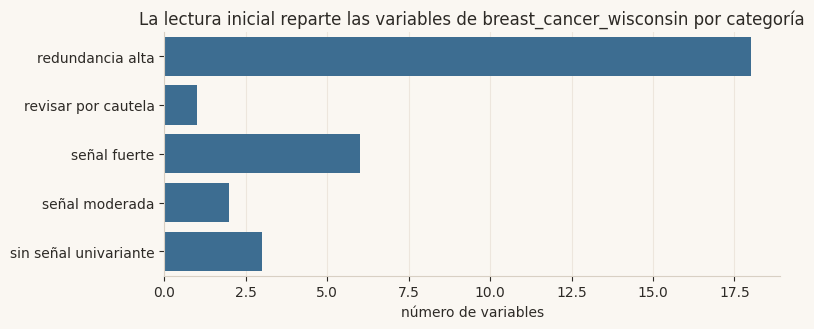

Figura guardada en formatos PNG y PDF.


In [109]:
preclasificacion_breast_cancer_wisconsin = preclasificar_dataset(
    asociacion_breast_cancer_wisconsin,
    pares_spearman_breast_cancer_wisconsin,
    revision_breast_cancer_wisconsin,
)
preclasificacion_resumen_breast_cancer_wisconsin = resumir_preclasificacion(preclasificacion_breast_cancer_wisconsin)

display(preclasificacion_resumen_breast_cancer_wisconsin)
figura = graficar_preclasificacion_dataset("breast_cancer_wisconsin", preclasificacion_resumen_breast_cancer_wisconsin)
ruta_figura = guardar_figura(figura, "01_14_preclasificacion_breast_cancer_wisconsin.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La preclasificación concentra variables en redundancia alta y señal fuerte. La Fase 2 deberá evitar seleccionar varias variables equivalentes.


### Preclasificación: `customer_churn`


,dataset,categoría exploratoria,n variables
no,Customer Churn,revisar por cautela,1
sí,Customer Churn,señal fuerte,4
2,Customer Churn,señal moderada,5


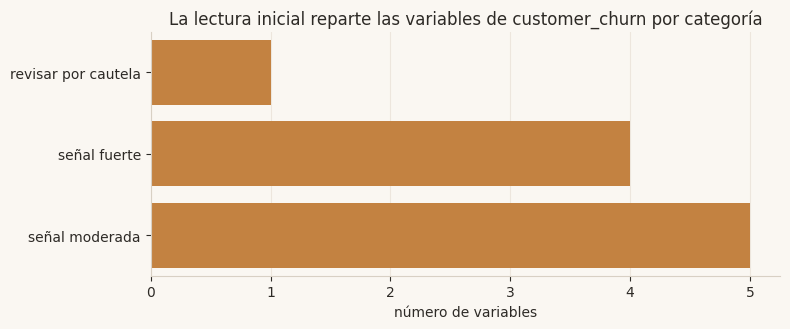

Figura guardada en formatos PNG y PDF.


In [110]:
preclasificacion_customer_churn = preclasificar_dataset(
    asociacion_customer_churn,
    pares_spearman_customer_churn,
    revision_customer_churn,
)
preclasificacion_resumen_customer_churn = resumir_preclasificacion(preclasificacion_customer_churn)

display(preclasificacion_resumen_customer_churn)
figura = graficar_preclasificacion_dataset("customer_churn", preclasificacion_resumen_customer_churn)
ruta_figura = guardar_figura(figura, "01_14_preclasificacion_customer_churn.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La preclasificación muestra señal en las 10 variables contrastadas, pero con 1 variable marcada para revisar por efecto mínimo.


### Preclasificación: `madelon`


,dataset,categoría exploratoria,n variables
no,Madelon,redundancia alta,18
sí,Madelon,revisar por cautela,25
2,Madelon,señal moderada,1
3,Madelon,sin señal univariante,456


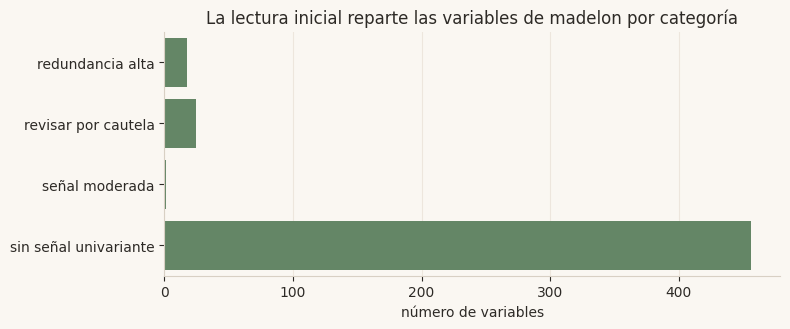

Figura guardada en formatos PNG y PDF.


In [111]:
preclasificacion_madelon = preclasificar_dataset(
    asociacion_madelon,
    pares_spearman_madelon,
    revision_madelon,
)
preclasificacion_resumen_madelon = resumir_preclasificacion(preclasificacion_madelon)

display(preclasificacion_resumen_madelon)
figura = graficar_preclasificacion_dataset("madelon", preclasificacion_resumen_madelon)
ruta_figura = guardar_figura(figura, "01_14_preclasificacion_madelon.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La mayoría de variables queda sin señal univariante: 456 de 500. Las pocas señales y redundancias detectadas deben validarse con métodos robustos.


### Preclasificación: `olive_oil`


,dataset,categoría exploratoria,n variables
no,Olive Oil,redundancia alta,2
sí,Olive Oil,revisar por cautela,2
2,Olive Oil,señal fuerte,6


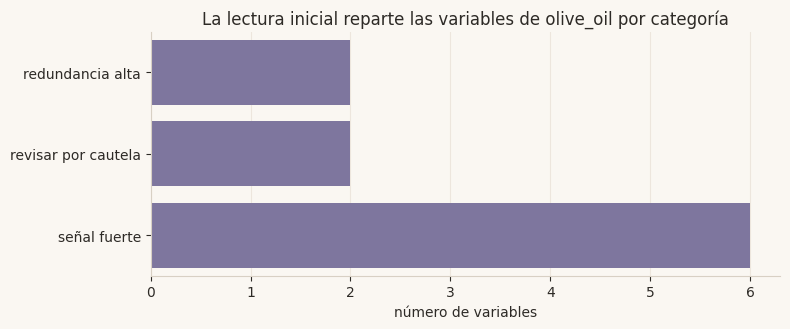

Figura guardada en formatos PNG y PDF.


In [112]:
preclasificacion_olive_oil = preclasificar_dataset(
    asociacion_olive_oil,
    pares_spearman_olive_oil,
    revision_olive_oil,
)
preclasificacion_resumen_olive_oil = resumir_preclasificacion(preclasificacion_olive_oil)

display(preclasificacion_resumen_olive_oil)
figura = graficar_preclasificacion_dataset("olive_oil", preclasificacion_resumen_olive_oil)
ruta_figura = guardar_figura(figura, "01_14_preclasificacion_olive_oil.png")
plt.show()
mostrar_ruta_relativa(ruta_figura)


La preclasificación mezcla 6 señales fuertes, 2 variables redundantes y 2 variables de revisión. La cautela semántica debe tratarse antes de modelar.


In [113]:
preclasificacion_variables = pd.concat([
    preclasificacion_breast_cancer_wisconsin,
    preclasificacion_customer_churn,
    preclasificacion_madelon,
    preclasificacion_olive_oil,
], ignore_index=True)
preclasificacion_resumen = pd.concat([
    preclasificacion_resumen_breast_cancer_wisconsin,
    preclasificacion_resumen_customer_churn,
    preclasificacion_resumen_madelon,
    preclasificacion_resumen_olive_oil,
], ignore_index=True)

guardar_tabla(preclasificacion_variables, "fase1_preclasificacion_variables.csv")
guardar_tabla(preclasificacion_resumen, "fase1_preclasificacion_resumen.csv")
display(preclasificacion_resumen.pivot_table(
    index="dataset",
    columns="categoria_exploratoria",
    values="n_variables",
    fill_value=0,
))


categoría exploratoria,redundancia alta,revisar por cautela,señal fuerte,señal moderada,sin señal univariante
dataset,,,,,
Breast Cancer Wisconsin,18.0,1.0,6.0,2.0,3.0
Customer Churn,0.0,1.0,4.0,5.0,0.0
Madelon,18.0,25.0,0.0,1.0,456.0
Olive Oil,2.0,2.0,6.0,0.0,0.0


La tabla dinámica de preclasificación deja visible todo el espacio resumido. `madelon` concentra 456 variables sin señal univariante, 25 de revisión y 18 con redundancia alta; `breast_cancer_wisconsin` reparte 18 variables en redundancia alta, 6 en señal fuerte y 3 sin señal; `customer_churn` tiene 4 señales fuertes, 5 moderadas y 1 revisión; y `olive_oil` combina 6 señales fuertes, 2 redundantes y 2 de revisión. Esta síntesis organiza la entrada a Fase 2 sin decidir aún qué variables se seleccionarán.


## 1.15 Síntesis Exploratoria

La síntesis reúne las métricas principales calculadas en las secciones anteriores: estructura, calidad, target, FDR, redundancia y PCA. El criterio de lectura es comparativo, porque el objetivo es cerrar la fase con un perfil de dificultad y utilidad para cada banco de datos.


In [114]:
sintesis_evidencias = (
    estructura_datasets[["dataset", "filas", "features", "ratio_features_muestras", "filas_por_feature", "posibles_identificadores"]]
    .merge(calidad_datasets[["dataset", "nulos_totales", "filas_duplicadas", "variables_constantes", "variables_baja_cardinalidad_relativa"]], on="dataset")
    .merge(target_resumen[["dataset", "n_clases", "ratio_mayoritaria_minoritaria"]], on="dataset")
    .merge(resumen_fdr[["dataset", "significativas_fdr", "reduccion_por_correccion"]], on="dataset")
    .merge(resumen_redundancia[["dataset", "pares_correlacion_alta", "correlacion_abs_maxima"]], on="dataset")
    .merge(pca_resumen[["dataset", "componentes_80", "componentes_90"]], on="dataset")
)

guardar_tabla(sintesis_evidencias, "fase1_sintesis_evidencias.csv")
display(sintesis_evidencias.style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
    "ratio_mayoritaria_minoritaria": "{:.3f}",
    "correlacion_abs_maxima": "{:.3f}",
}))


,dataset,filas,variables predictoras,variables / filas,filas por variable,posibles identificadores,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,n clases,ratio mayoritaria / minoritaria,significativas fdr,reduccion por correccion,pares correlacion alta,|correlación| máxima,componentes para 80%,componentes para 90%
no,Breast Cancer Wisconsin,569,31,0.054482,18.354839,1,0,0,0,0,2,1.683962,27,0,29,0.999602,5,7
sí,Customer Churn,440832,11,0.000025,40075.636364,1,0,0,0,9,2,1.310041,10,0,0,0.190689,6,7
2,Madelon,2000,500,0.250000,4.000000,0,0,0,0,24,2,1.000000,13,25,12,0.996145,295,369
3,Olive Oil,572,11,0.019231,52.000000,1,0,0,0,1,9,8.240000,10,0,2,0.916474,3,5


La síntesis conjunta condensa 4 perfiles de dificultad. `madelon` combina 500 features, 4,0 filas por feature, 13 variables FDR y 12 pares redundantes; `customer_churn` combina 440.832 filas, 10 features y 0 pares redundantes altos; `breast_cancer_wisconsin` acumula 29 pares `|rho| >= 0,85`; y `olive_oil` añade 9 clases con ratio 8,240. Las lecturas por dataset desglosan estas implicaciones antes del cierre.


### Síntesis: `breast_cancer_wisconsin`


In [115]:
display(sintesis_evidencias[sintesis_evidencias["dataset"] == "breast_cancer_wisconsin"].style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
    "ratio_mayoritaria_minoritaria": "{:.3f}",
    "correlacion_abs_maxima": "{:.3f}",
}))


,dataset,filas,variables predictoras,variables / filas,filas por variable,posibles identificadores,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,n clases,ratio mayoritaria / minoritaria,significativas fdr,reduccion por correccion,pares correlacion alta,|correlación| máxima,componentes para 80%,componentes para 90%
no,Breast Cancer Wisconsin,569,31,0.054482,18.354839,1,0,0,0,0,2,1.683962,27,0,29,0.999602,5,7


La síntesis de `breast_cancer_wisconsin` combina señal fuerte con redundancia alta. Para la Fase 2, la cautela principal es seleccionar variables repetidas o incluir identificadores.


### Síntesis: `customer_churn`


In [116]:
display(sintesis_evidencias[sintesis_evidencias["dataset"] == "customer_churn"].style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
    "ratio_mayoritaria_minoritaria": "{:.3f}",
    "correlacion_abs_maxima": "{:.3f}",
}))


,dataset,filas,variables predictoras,variables / filas,filas por variable,posibles identificadores,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,n clases,ratio mayoritaria / minoritaria,significativas fdr,reduccion por correccion,pares correlacion alta,|correlación| máxima,componentes para 80%,componentes para 90%
sí,Customer Churn,440832,11,0.000025,40075.636364,1,0,0,0,9,2,1.310041,10,0,0,0.190689,6,7


La síntesis de `customer_churn` muestra 440.832 filas, 10 features y 10 variables FDR. La lectura posterior debe priorizar magnitud de efecto y codificación correcta.


### Síntesis: `madelon`


In [117]:
display(sintesis_evidencias[sintesis_evidencias["dataset"] == "madelon"].style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
    "ratio_mayoritaria_minoritaria": "{:.3f}",
    "correlacion_abs_maxima": "{:.3f}",
}))


,dataset,filas,variables predictoras,variables / filas,filas por variable,posibles identificadores,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,n clases,ratio mayoritaria / minoritaria,significativas fdr,reduccion por correccion,pares correlacion alta,|correlación| máxima,componentes para 80%,componentes para 90%
2,Madelon,2000,500,0.250000,4.000000,0,0,0,0,24,2,1.000000,13,25,12,0.996145,295,369


La síntesis de `madelon` confirma 500 features, 4,0 filas por feature y reducción FDR de 38 a 13. Necesita selección robusta frente a ruido.


### Síntesis: `olive_oil`


In [118]:
display(sintesis_evidencias[sintesis_evidencias["dataset"] == "olive_oil"].style.format({
    "ratio_features_muestras": "{:.5f}",
    "filas_por_feature": "{:.1f}",
    "ratio_mayoritaria_minoritaria": "{:.3f}",
    "correlacion_abs_maxima": "{:.3f}",
}))


,dataset,filas,variables predictoras,variables / filas,filas por variable,posibles identificadores,nulos totales,filas duplicadas,variables constantes,variables baja cardinalidad relativa,n clases,ratio mayoritaria / minoritaria,significativas fdr,reduccion por correccion,pares correlacion alta,|correlación| máxima,componentes para 80%,componentes para 90%
3,Olive Oil,572,11,0.019231,52.000000,1,0,0,0,1,9,8.240000,10,0,2,0.916474,3,5


La síntesis de `olive_oil` muestra 9 clases, ratio 8,240, 10 variables FDR y 2 variables de revisión semántica por posible proxy.


### Resumen Para Memoria

Se guarda un resumen breve de Fase 1 con los resultados principales. El informe no sustituye a las tablas: resume las implicaciones metodológicas que sí pertenecen a esta fase exploratoria.


In [119]:
summary_lines = [
    "# Resultados de la Fase 1 - Análisis exploratorio crudo",
    "",
    "La Fase 1 carga los datasets crudos, caracteriza estructura, calidad, target, asociaciones exploratorias, FDR, redundancia y dimensionalidad.",
    "",
    "## Hallazgos principales",
]

for _, row in sintesis_evidencias.iterrows():
    revision_row = resumen_revision[resumen_revision["dataset"].eq(row["dataset"])]
    n_review = int(revision_row["variables_a_revisar"].iloc[0]) if not revision_row.empty else 0
    summary_lines.append(
        f"- `{row['dataset']}`: {int(row['filas'])} filas, {int(row['features'])} features, "
        f"ratio features/muestras={row['ratio_features_muestras']:.5f}, "
        f"FDR significativas={int(row['significativas_fdr'])}, "
        f"pares Spearman >=0.85={int(row['pares_correlacion_alta'])}, "
        f"variables para revisión={n_review}."
    )

summary_lines.extend([
    "",
    "## Implicaciones para fases posteriores",
    "- Fase 2 debe limitarse a preprocesado estructural: identificadores, nombres y target.",
    "- Fase 3 debe comprobar que el preprocesado conserva target, distribuciones y señal exploratoria.",
    "- Fase 4 debe estratificar y vigilar fugas de información y desplazamientos de distribución, especialmente en Olive Oil y variables con efecto casi perfecto.",
    "- Fase 5 debe separar señal, ruido y redundancia; `madelon` es el caso crítico para selección robusta.",
    "",
    "## Tablas generadas",
])

for table_path in sorted(TABLES_DIR.glob("fase1_*.csv")):
    summary_lines.append(f"- `{table_path.relative_to(PROJECT_ROOT)}`")

summary_lines.extend(["", "## Figuras generadas"])
for figure_path in sorted(FIGURES_DIR.rglob("*.png")):
    summary_lines.append(f"- `{figure_path.relative_to(PROJECT_ROOT)}`")

summary_path = REPORTS_DIR / "fase1_resumen_para_memoria.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print("Resumen para memoria guardado.")


Resumen para memoria guardado.


El resumen para memoria queda guardado y no añade resultados nuevos. Su función es condensar las conclusiones principales de esta fase exploratoria para la redacción final.


## 1.16 Conclusiones y Consideraciones Para la Fase 2

La Fase 1 permite afirmar lo siguiente desde resultados exploratorios y criterios reproducibles de calidad, target, FDR, redundancia y PCA: los cuatro datasets se cargan correctamente, no se observan nulos ni duplicados, los targets presentan comportamientos distintos y la relación entre variables y target varía mucho entre datasets.

`breast_cancer_wisconsin` exige controlar identificadores y redundancia. `customer_churn` exige no confundir significancia con relevancia práctica. `madelon` exige métodos de selección capaces de manejar dimensionalidad y ruido. `olive_oil` exige estratificación multiclase, métricas adecuadas y revisión semántica de variables con efecto casi perfecto.

Lo que todavía no se puede concluir con el criterio técnico de Fase 1 es rendimiento predictivo, causalidad, fuga de información confirmada o conjunto final de variables. Esas decisiones corresponden a fases posteriores con preprocesado, particiones, selección de características y validación.
